Starting training...


Epoch 50/300, ELBO: -1093.32
Epoch 100/300, ELBO: -1024.54
Epoch 150/300, ELBO: -1041.37
Epoch 200/300, ELBO: -1042.70
Epoch 250/300, ELBO: -1036.20
Epoch 300/300, ELBO: -1000.52
Training complete.


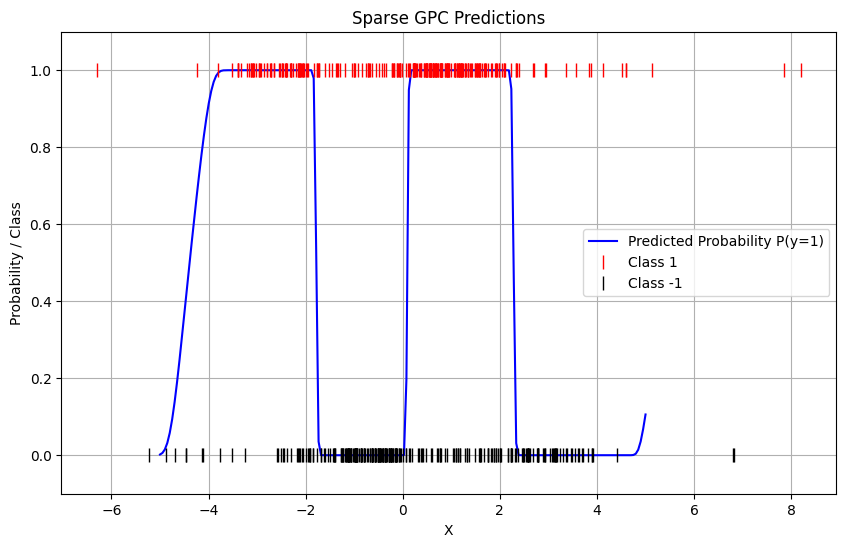

In [4]:
import torch
import torch.nn as nn
from torch.distributions import Normal
from sklearn.cluster import KMeans
import numpy as np
import math

# Use the same RBF kernel from the reference implementation
def rbf_kernel(X1, X2, lengthscale, variance=1.0):
    """
    Computes the RBF kernel matrix with ARD support.
    """
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    X1_scaled = X1 / lengthscale
    X2_scaled = X2 / lengthscale
    sqdist = torch.cdist(X1_scaled, X2_scaled, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist)


class SparseGPC(nn.Module):
    def __init__(self, X, y, M, kernel_lengthscale=None, kernel_variance=1.0, device=None):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        # Ensure labels are {-1, 1}
        y_proc = y.clone().view(-1, 1)
        if not torch.all((y_proc == 1) | (y_proc == -1)):
             raise ValueError("Labels y must be in {-1, 1}")

        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y_proc.to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        self.M = M
        dtype = self.X_full.dtype

        # Inducing points
        self.Z = nn.Parameter(self._initialize_inducing_points())

        # Kernel hyperparameters
        if kernel_lengthscale is None:
            kernel_lengthscale = torch.ones(self.D, dtype=dtype)
        else:
            kernel_lengthscale = torch.as_tensor(kernel_lengthscale, dtype=dtype)
        if kernel_lengthscale.ndim == 0:
            kernel_lengthscale = kernel_lengthscale.repeat(self.D)
        self.log_kernel_lengthscale = nn.Parameter(torch.log(kernel_lengthscale))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=dtype)))

        # Variational parameters for q(u) = N(m_u, S_u)
        # We store them as natural parameters contributed by the likelihood
        # nat1_lik = S_u_lik^{-1} m_u_lik
        # Lambda_lik = S_u_lik^{-1}
        self.register_buffer('nat1_lik', torch.zeros(self.M, 1, dtype=dtype))
        self.register_buffer('Lambda_lik', torch.zeros(self.M, self.M, dtype=dtype))

        # Standard normal distribution for probit likelihood calculations
        self.normal_dist = Normal(torch.tensor(0.0, device=self.device, dtype=dtype),
                                  torch.tensor(1.0, device=self.device, dtype=dtype))
        
        self.kernel = rbf_kernel
        self.to(self.device)

    def _initialize_inducing_points(self):
        if self.N > self.M:
            X_np = self.X_full.cpu().numpy()
            kmeans = KMeans(n_clusters=self.M, random_state=0, n_init='auto').fit(X_np)
            Z_init = torch.from_numpy(kmeans.cluster_centers_)
        else:
            indices = np.random.choice(self.N, self.M, replace=False)
            Z_init = self.X_full[indices].clone()
        return Z_init.to(dtype=self.X_full.dtype, device=self.device)

    def _get_kernel_params(self):
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }

    def _get_std_from_natural(self, K_mm_inv):
        """ Converts global natural parameters to standard parameters (m_u, S_u) """
        Lambda_prior = K_mm_inv
        Lambda_global = Lambda_prior + self.Lambda_lik
        jitter = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * 1e-6
        S_u = torch.inverse(Lambda_global + jitter)
        m_u = S_u @ self.nat1_lik
        return m_u, S_u

    def _truncated_normal_moments(self, mu, y):
        """
        Computes the first and second moments of a truncated standard normal distribution.
        The distribution is N(z | mu, 1) truncated to the interval consistent with y.
        """
        alpha = -mu * y
        # Add a small epsilon for numerical stability
        eps = 1e-8
        
        pdf_cdf_ratio = torch.exp(self.normal_dist.log_prob(alpha) - torch.log(self.normal_dist.cdf(alpha) + eps))
        
        Ez = mu + y * pdf_cdf_ratio
        Var_z = 1 - alpha * pdf_cdf_ratio - pdf_cdf_ratio.pow(2)
        Ez2 = Var_z + Ez.pow(2)
        
        return Ez, Ez2

    def update_variational_params(self, X_batch, y_batch, learning_rate):
        """
        Performs a single SVI update of the global variational parameters
        based on a minibatch of data.
        """
        B = X_batch.shape[0]
        params = self._get_kernel_params()
        jitter = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * 1e-4

        K_mm = self.kernel(self.Z, self.Z, params['lengthscale'], params['variance'])
        K_mb = self.kernel(self.Z, X_batch, params['lengthscale'], params['variance'])
        K_mm_inv = torch.inverse(K_mm + jitter)
        
        m_u, _ = self._get_std_from_natural(K_mm_inv)
        
        A = K_mm_inv @ K_mb
        mu_f_batch = A.T @ m_u
        
        Ez, _ = self._truncated_normal_moments(mu_f_batch, y_batch)
        
        delta_nat1 = (self.N / B) * (A @ Ez)
        delta_Lambda = (self.N / B) * (A @ A.T)
        
        self.nat1_lik.data = (1 - learning_rate) * self.nat1_lik.data + learning_rate * delta_nat1
        self.Lambda_lik.data = (1 - learning_rate) * self.Lambda_lik.data + learning_rate * delta_Lambda

    def forward(self, X_batch, y_batch):
        """ Calculates the evidence lower bound (ELBO) for a minibatch. """
        B = X_batch.shape[0]
        params = self._get_kernel_params()
        jitter = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * 1e-4

        K_mm = self.kernel(self.Z, self.Z, params['lengthscale'], params['variance'])
        K_mb = self.kernel(self.Z, X_batch, params['lengthscale'], params['variance'])
        K_bb_diag = params['variance'].expand(B)
        K_mm_inv = torch.inverse(K_mm + jitter)
        
        m_u, S_u = self._get_std_from_natural(K_mm_inv)

        A = K_mm_inv @ K_mb
        mu_f = A.T @ m_u
        
        # CORRECTED LINE: Efficiently compute diag(A.T @ S_u @ A)
        var_f = K_bb_diag - (A * K_mb).sum(dim=0) + (A * (S_u @ A)).sum(dim=0)
        
        Ef2 = var_f.view(-1, 1) + mu_f.pow(2)
        
        Ez, Ez2 = self._truncated_normal_moments(mu_f, y_batch)

        log_lik = -0.5 * math.log(2 * math.pi) - 0.5 * (Ez2 - 2 * Ez * mu_f + Ef2)
        scaled_log_lik = log_lik.sum() * (self.N / B)
        
        L_Kmm = torch.linalg.cholesky(K_mm + jitter)
        log_det_K = 2 * torch.log(L_Kmm.diag()).sum()
        
        Lambda_global = K_mm_inv + self.Lambda_lik
        L_Lambda = torch.linalg.cholesky(Lambda_global + jitter)
        log_det_S = -2 * torch.log(L_Lambda.diag()).sum()
        
        trace_term = (K_mm_inv @ S_u).trace()
        mahalanobis_term = (m_u.T @ K_mm_inv @ m_u).squeeze()

        kl_div = 0.5 * (trace_term + mahalanobis_term - self.M + log_det_K - log_det_S)
        
        elbo = scaled_log_lik - kl_div
        return elbo

    def predict(self, X_test):
        """ Predict class probabilities for new data X_test. """
        X_test_dev = X_test.to(self.device)
        if X_test_dev.ndim == 1: X_test_dev = X_test_dev.unsqueeze(1)
            
        with torch.no_grad():
            params = self._get_kernel_params()
            jitter = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * 1e-6
            
            K_mm = self.kernel(self.Z, self.Z, params['lengthscale'], params['variance'])
            K_sm = self.kernel(X_test_dev, self.Z, params['lengthscale'], params['variance'])
            K_ss_diag = params['variance'].expand(X_test_dev.shape[0])
            K_mm_inv = torch.inverse(K_mm + jitter)
            
            m_u, S_u = self._get_std_from_natural(K_mm_inv)
            
            A = K_sm @ K_mm_inv
            pred_mean_f = A @ m_u
            
            # CORRECTED LINE: Efficiently compute diag(A @ S_u @ A.T)
            pred_var_f = K_ss_diag - (A * K_sm).sum(dim=1) + ((A @ S_u) * A).sum(dim=1)
            
            pred_prob = self.normal_dist.cdf(pred_mean_f.squeeze() / torch.sqrt(1 + pred_var_f))
            
            return pred_prob.cpu()


if __name__ == '__main__':
    # Example Usage
    from torch.utils.data import TensorDataset, DataLoader

    # 1. Generate synthetic data
    N = 500
    D = 1
    torch.manual_seed(0)
    X = torch.randn(N, D) * 2
    f_true = torch.sin(X * 2 * math.pi / 4)
    # Probit link function
    prob = Normal(0, 1).cdf(f_true)
    y = (torch.rand(N, 1) < prob).float() * 2 - 1 # Convert to {-1, 1}

    # 2. Instantiate the model
    M = 20 # Number of inducing points
    model = SparseGPC(X, y, M=M)

    # 3. Set up optimizer and data loader
    # The optimizer will handle kernel hyperparameters and inducing point locations
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    dataset = TensorDataset(X, y)
    dataloader = DataLoader(dataset, batch_size=100, shuffle=True)
    
    # 4. Training loop
    epochs = 300
    learning_rate = 0.1 # Learning rate for the SVI updates
    
    print("Starting training...")
    for epoch in range(epochs):
        epoch_elbo = 0.0
        for X_batch, y_batch in dataloader:
            # SVI update for q(u)
            model.update_variational_params(X_batch, y_batch, learning_rate=learning_rate)
            
            # Gradient-based update for hyperparameters
            optimizer.zero_grad()
            elbo = model(X_batch, y_batch)
            loss = -elbo
            loss.backward()
            optimizer.step()
            epoch_elbo += elbo.item()
            
        if (epoch + 1) % 50 == 0:
            avg_elbo = epoch_elbo / len(dataloader)
            print(f"Epoch {epoch+1}/{epochs}, ELBO: {avg_elbo:.2f}")

    print("Training complete.")

    # 5. Prediction
    X_test = torch.linspace(-5, 5, 200).view(-1, 1)
    pred_probs = model.predict(X_test)
    
    # 6. Plotting results
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 6))
        plt.plot(X_test.numpy(), pred_probs.numpy(), 'b-', label='Predicted Probability P(y=1)')
        
        # Plot training data
        plt.plot(X[y.squeeze() == 1].numpy(), torch.ones_like(X[y.squeeze() == 1]).numpy(), 'r|', markersize=10, label='Class 1')
        plt.plot(X[y.squeeze() == -1].numpy(), torch.zeros_like(X[y.squeeze() == -1]).numpy(), 'k|', markersize=10, label='Class -1')

        plt.title('Sparse GPC Predictions')
        plt.xlabel('X')
        plt.ylabel('Probability / Class')
        plt.ylim(-0.1, 1.1)
        plt.legend()
        plt.grid(True)
        plt.show()
    except ImportError:
        print("Matplotlib not found. Cannot plot results.")
        print("Test Probabilities:", pred_probs)

In [7]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler


# --- Main execution block ---
if __name__ == '__main__':
    def plot_decision_boundary(model, X, y, ax, title):
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        
        # Use the predict_proba wrapper
        Z = model.predict_proba(grid_points)
        Z = Z.reshape(xx.shape)
        
        cs = ax.contourf(xx, yy, Z, cmap=plt.cm.RdBu_r, alpha=0.8, levels=np.linspace(0, 1, 11))
        plt.colorbar(cs, ax=ax, label="P(y=1)")
        ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
        
        # Use y (with {0,1}) for color mapping
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu_r, edgecolors='k', s=50)
        ax.set_title(title)
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")

    def plot_history(history):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle("Hyperparameter Optimization History (ARD)", fontsize=16)
        axes[0].plot(history['elbo']); axes[0].set_title('ELBO')
        ls_history = np.array(history['length_scale'])
        for d in range(ls_history.shape[1]):
            axes[1].plot(ls_history[:, d], label=f'length_scale_{d+1}')
        axes[1].set_title('Length Scales'); axes[1].legend()
        axes[1].set_yscale('log')
        axes[2].plot(history['variance']); axes[2].set_title('Variance')
        for ax in axes: ax.set_xlabel('Epoch'); ax.grid(True)
        fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

    # --- Data Generation ---
    np.random.seed(42)
    n_samples = 150
    X_np, y_np_01 = make_moons(n_samples=n_samples, noise=0.1, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_np)

    # Convert to PyTorch tensors
    X_torch = torch.from_numpy(X_scaled).float()
    
    # CRITICAL: Convert labels from {0, 1} to {-1, 1} for the model
    y_torch_pm1 = torch.from_numpy(y_np_01).float() * 2 - 1

    # --- Model Training ---
    model = SparseGPC(X_torch, y_torch_pm1, M=30, kernel_lengthscale=1.0)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    dataset = TensorDataset(X_torch, y_torch_pm1)
    dataloader = DataLoader(dataset, batch_size=50, shuffle=True)
    
    epochs = 200
    svi_lr = 0.1 # Learning rate for the SVI updates
    history = {'elbo': [], 'length_scale': [], 'variance': []}

    print("Starting training...")
    for epoch in range(epochs):
        epoch_elbo = 0.0
        for X_batch, y_batch in dataloader:
            model.update_variational_params(X_batch, y_batch, learning_rate=svi_lr)
            optimizer.zero_grad()
            elbo = model(X_batch, y_batch)
            loss = -elbo
            # Avoid backpropagating through natural parameters
            loss.backward()
            optimizer.step()
            epoch_elbo += elbo.item()
        
        # Log history at the end of each epoch
        avg_elbo = epoch_elbo / len(dataloader)
        history['elbo'].append(avg_elbo)
        current_params = model._get_kernel_params()
        history['length_scale'].append(current_params['lengthscale'].detach().cpu().numpy())
        history['variance'].append(current_params['variance'].detach().cpu().numpy())
        
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1}/{epochs}, ELBO: {avg_elbo:.2f}")

    print("Training complete.")

    # --- Plotting Results ---
    plot_history(history)
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    hp = model._get_kernel_params()
    ls_vals = hp["lengthscale"].detach().cpu().numpy()
    ls_str = ", ".join([f"{l:.2f}" for l in ls_vals])
    var_val = hp["variance"].detach().cpu().numpy()

    title = (f'Sparse GPC Decision Boundary (ARD)\n'
             f'l=[{ls_str}], var={var_val:.2f}')
    
    # Use original {0,1} labels for plotting
    plot_decision_boundary(model, X_scaled, y_np_01, ax, title)
    plt.show()

Starting training...


RuntimeError: grad can be implicitly created only for scalar outputs

Starting training...


Epoch 50/200, ELBO: -13207.29
Epoch 100/200, ELBO: -11334.45
Epoch 150/200, ELBO: -11028.10
Epoch 200/200, ELBO: -10945.50
Training complete.


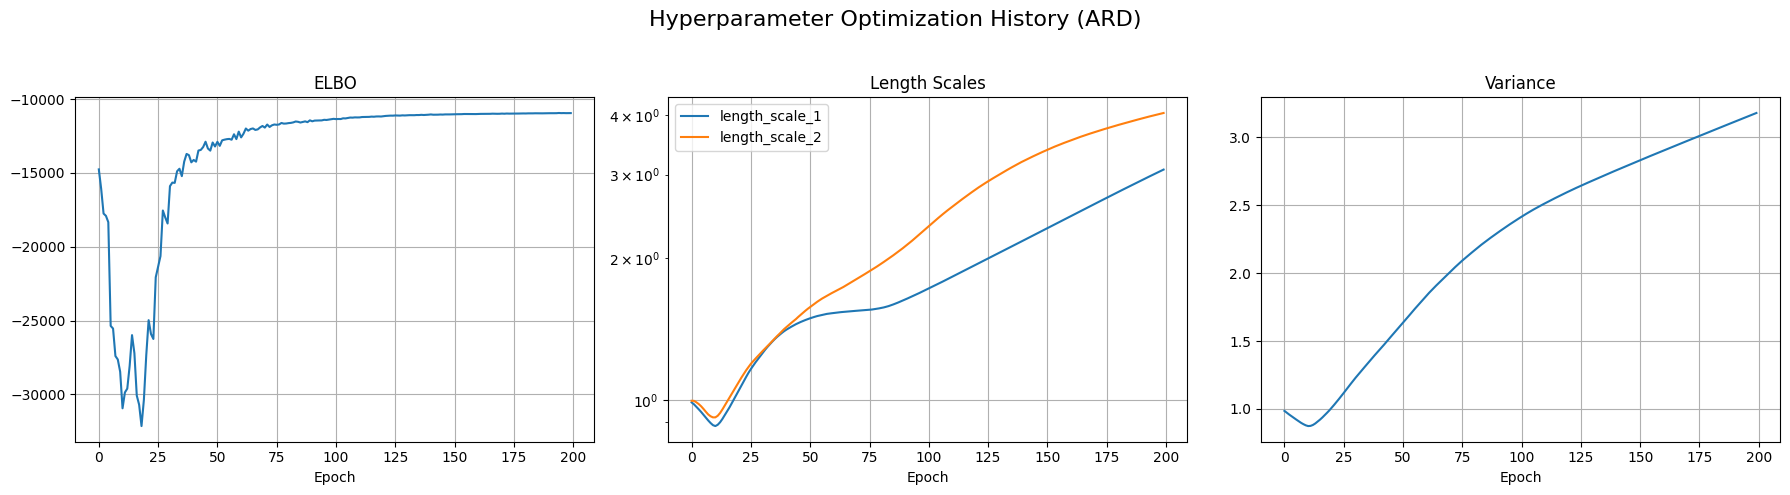

RuntimeError: The size of tensor a (50) must match the size of tensor b (3422) at non-singleton dimension 1

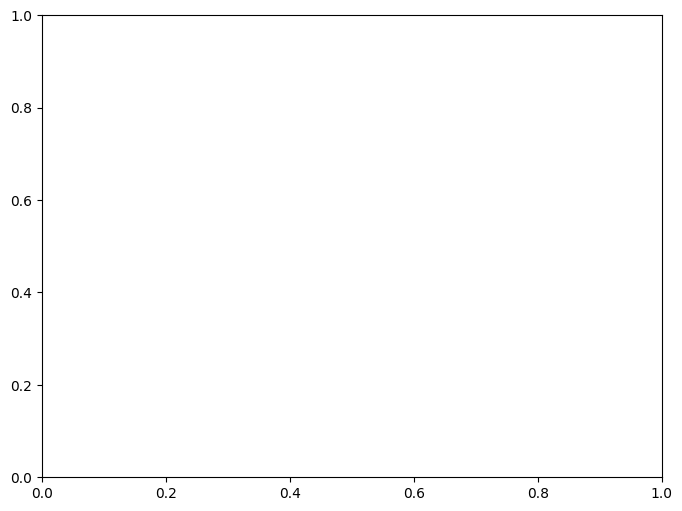

In [11]:
import torch
import torch.nn as nn
from torch.distributions import Normal
from torch.utils.data import TensorDataset, DataLoader
from sklearn.cluster import KMeans
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
import numpy as np
import math
import matplotlib.pyplot as plt

# --- MODIFICATION START: Import linear-operator library ---
from linear_operator.operators import to_linear_operator, AddedDiagLinearOperator, DiagLinearOperator
# --- MODIFICATION END ---


# --- KERNEL FUNCTION ---
def rbf_kernel(X1, X2, lengthscale, variance=1.0):
    """
    Computes the RBF kernel matrix with ARD support.
    """
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    X1_scaled = X1 / lengthscale
    X2_scaled = X2 / lengthscale
    sqdist = torch.cdist(X1_scaled, X2_scaled, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist)

# --- SparseGPC MODEL CLASS ---
class SparseGPC(nn.Module):
    def __init__(self, X, y, M, kernel_lengthscale=None, kernel_variance=1.0, device=None):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        y_proc = y.clone().view(-1, 1)
        if not torch.all((y_proc == 1) | (y_proc == -1)):
             raise ValueError("Labels y must be in {-1, 1}")

        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y_proc.to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        self.M = M
        dtype = self.X_full.dtype
        
        self.jitter = 1e-4

        self.Z = nn.Parameter(self._initialize_inducing_points())

        if kernel_lengthscale is None:
            kernel_lengthscale = torch.ones(self.D, dtype=dtype)
        else:
            kernel_lengthscale = torch.as_tensor(kernel_lengthscale, dtype=dtype)
        if kernel_lengthscale.ndim == 0:
            kernel_lengthscale = kernel_lengthscale.repeat(self.D)
        self.log_kernel_lengthscale = nn.Parameter(torch.log(kernel_lengthscale))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=dtype)))

        self.register_buffer('nat1_lik', torch.zeros(self.M, 1, dtype=dtype))
        self.register_buffer('Lambda_lik', torch.zeros(self.M, self.M, dtype=dtype))

        self.normal_dist = Normal(torch.tensor(0.0, device=self.device, dtype=dtype),
                                  torch.tensor(1.0, device=self.device, dtype=dtype))
        
        self.kernel = rbf_kernel
        self.to(self.device)

    def _initialize_inducing_points(self):
        if self.N > self.M:
            X_np = self.X_full.cpu().numpy()
            kmeans = KMeans(n_clusters=self.M, random_state=0, n_init='auto').fit(X_np)
            Z_init = torch.from_numpy(kmeans.cluster_centers_)
        else:
            indices = np.random.choice(self.N, self.M, replace=False)
            Z_init = self.X_full[indices].clone()
        return Z_init.to(dtype=self.X_full.dtype, device=self.device)

    def _get_kernel_params(self):
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }

    # --- MODIFICATION START: Helper for creating Kmm operator ---
    def _get_kmm_operator(self, params):
        K_mm_base = to_linear_operator(self.kernel(self.Z, self.Z, params['lengthscale'], params['variance']))
        jitter_diag = torch.full((self.M,), self.jitter, device=self.device, dtype=self.X_full.dtype)
        jitter_op = DiagLinearOperator(jitter_diag)
        return AddedDiagLinearOperator(K_mm_base, jitter_op)
    # --- MODIFICATION END ---

    def _get_std_from_natural(self, K_mm_inv):
        Lambda_prior = K_mm_inv
        Lambda_global = Lambda_prior + self.Lambda_lik
        jitter_mat = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * self.jitter
        S_u = torch.inverse(Lambda_global + jitter_mat)
        m_u = S_u @ self.nat1_lik
        return m_u, S_u

    def _truncated_normal_moments(self, mu, y):
        alpha = -mu * y
        eps = 1e-8
        pdf_cdf_ratio = torch.exp(self.normal_dist.log_prob(alpha) - torch.log(self.normal_dist.cdf(alpha) + eps))
        Ez = mu + y * pdf_cdf_ratio
        Var_z = 1 - alpha * pdf_cdf_ratio - pdf_cdf_ratio.pow(2)
        Ez2 = Var_z + Ez.pow(2)
        return Ez, Ez2

    def update_variational_params(self, X_batch, y_batch, learning_rate):
        B = X_batch.shape[0]
        params = self._get_kernel_params()
        
        # --- MODIFICATION START: Use linear operator ---
        K_mm_op = self._get_kmm_operator(params)
        K_mm_inv = K_mm_op.solve(torch.eye(self.M, device=self.device, dtype=self.X_full.dtype))
        # --- MODIFICATION END ---
        
        K_mb = self.kernel(self.Z, X_batch, params['lengthscale'], params['variance'])
        
        m_u, _ = self._get_std_from_natural(K_mm_inv)

        # --- MODIFICATION START: Use stable solve ---
        A = K_mm_op.solve(K_mb) # Equivalent to K_mm_inv @ K_mb
        # --- MODIFICATION END ---

        mu_f_batch = A.T @ m_u
        Ez, _ = self._truncated_normal_moments(mu_f_batch, y_batch)
        
        delta_nat1 = (self.N / B) * (A @ Ez)
        delta_Lambda = (self.N / B) * (A @ A.T)
        
        self.nat1_lik.data = (1 - learning_rate) * self.nat1_lik.data + learning_rate * delta_nat1
        self.Lambda_lik.data = (1 - learning_rate) * self.Lambda_lik.data + learning_rate * delta_Lambda

    def forward(self, X_batch, y_batch):
        B = X_batch.shape[0]
        params = self._get_kernel_params()

        # --- MODIFICATION START: Use linear operator ---
        K_mm_op = self._get_kmm_operator(params)
        K_mm_inv = K_mm_op.solve(torch.eye(self.M, device=self.device, dtype=self.X_full.dtype))
        # --- MODIFICATION END ---

        K_mb = self.kernel(self.Z, X_batch, params['lengthscale'], params['variance'])
        K_bb_diag = params['variance'].expand(B)
        
        m_u, S_u = self._get_std_from_natural(K_mm_inv)
        
        # --- MODIFICATION START: Use stable solve ---
        A = K_mm_op.solve(K_mb)
        # --- MODIFICATION END ---
        
        mu_f = A.T @ m_u
        var_f = K_bb_diag - (A * K_mb).sum(dim=0) + (A * (S_u @ A)).sum(dim=0)
        Ef2 = var_f.view(-1, 1) + mu_f.pow(2)
        Ez, Ez2 = self._truncated_normal_moments(mu_f, y_batch)
        log_lik = -0.5 * math.log(2 * math.pi) - 0.5 * (Ez2 - 2 * Ez * mu_f + Ef2)
        scaled_log_lik = log_lik.sum() * (self.N / B)
        
        # --- MODIFICATION START: Use stable logdet ---
        log_det_K = K_mm_op.logdet()
        # --- MODIFICATION END ---
        
        Lambda_global = K_mm_inv + self.Lambda_lik
        jitter_mat = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * self.jitter
        L_Lambda = torch.linalg.cholesky(Lambda_global + jitter_mat)
        log_det_S = -2 * torch.log(L_Lambda.diag()).sum()
        
        trace_term = (K_mm_inv @ S_u).trace()
        mahalanobis_term = (m_u.T @ K_mm_inv @ m_u).sum()
        kl_div = 0.5 * (trace_term + mahalanobis_term - self.M + log_det_K - log_det_S)
        elbo = scaled_log_lik - kl_div
        return elbo

    def predict(self, X_test):
        X_test_dev = X_test.to(self.device)
        if X_test_dev.ndim == 1: X_test_dev = X_test_dev.unsqueeze(1)
        with torch.no_grad():
            params = self._get_kernel_params()

            # --- MODIFICATION START: Use linear operator ---
            K_mm_op = self._get_kmm_operator(params)
            K_mm_inv = K_mm_op.solve(torch.eye(self.M, device=self.device, dtype=self.X_full.dtype))
            # --- MODIFICATION END ---
            
            K_sm = self.kernel(X_test_dev, self.Z, params['lengthscale'], params['variance'])
            K_ss_diag = params['variance'].expand(X_test_dev.shape[0])
            
            m_u, S_u = self._get_std_from_natural(K_mm_inv)
            
            # --- MODIFICATION START: Use stable solve for A = K_sm @ K_mm_inv ---
            A_T = K_mm_op.solve(K_sm.T)
            A = A_T.T
            # --- MODIFICATION END ---
            
            pred_mean_f = A @ m_u
            pred_var_f = K_ss_diag - (A * K_sm).sum(dim=1) + ((A @ S_u) * A).sum(dim=1)
            pred_prob = self.normal_dist.cdf(pred_mean_f.squeeze() / torch.sqrt(1 + pred_var_f))
            return pred_prob.cpu()

    def predict_proba(self, X_test_np):
        X_test_torch = torch.from_numpy(X_test_np).to(dtype=self.X_full.dtype)
        return self.predict(X_test_torch).numpy()


# --- Main execution block (Unchanged from your working version) ---
if __name__ == '__main__':
    def plot_decision_boundary(model, X, y, ax, title):
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        Z = model.predict_proba(grid_points)
        Z = Z.reshape(xx.shape)
        cs = ax.contourf(xx, yy, Z, cmap=plt.cm.RdBu_r, alpha=0.8, levels=np.linspace(0, 1, 11))
        plt.colorbar(cs, ax=ax, label="P(y=1)")
        ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu_r, edgecolors='k', s=50)
        ax.set_title(title)
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")

    def plot_history(history):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle("Hyperparameter Optimization History (ARD)", fontsize=16)
        axes[0].plot(history['elbo']); axes[0].set_title('ELBO')
        ls_history = np.array(history['length_scale'])
        for d in range(ls_history.shape[1]):
            axes[1].plot(ls_history[:, d], label=f'length_scale_{d+1}')
        axes[1].set_title('Length Scales'); axes[1].legend()
        axes[1].set_yscale('log')
        axes[2].plot(history['variance']); axes[2].set_title('Variance')
        for ax in axes: ax.set_xlabel('Epoch'); ax.grid(True)
        fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

    # --- Data Generation ---
    np.random.seed(42)
    n_samples = 150
    X_np, y_np_01 = make_moons(n_samples=n_samples, noise=0.1, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_np)
    X_torch = torch.from_numpy(X_scaled).float()
    y_torch_pm1 = torch.from_numpy(y_np_01).float() * 2 - 1

    # --- Model Training ---
    model = SparseGPC(X_torch, y_torch_pm1, M=30, kernel_lengthscale=1.0)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005) 
    dataset = TensorDataset(X_torch, y_torch_pm1)
    dataloader = DataLoader(dataset, batch_size=50, shuffle=True)
    
    epochs = 200
    svi_lr = 0.05
    history = {'elbo': [], 'length_scale': [], 'variance': []}

    print("Starting training...")
    for epoch in range(epochs):
        epoch_elbo = 0.0
        for X_batch, y_batch in dataloader:
            model.update_variational_params(X_batch, y_batch, learning_rate=svi_lr)
            optimizer.zero_grad()
            elbo = model(X_batch, y_batch)
            loss = -elbo
            loss.backward()
            optimizer.step()
            epoch_elbo += elbo.item()
        
        avg_elbo = epoch_elbo / len(dataloader)
        history['elbo'].append(avg_elbo)
        current_params = model._get_kernel_params()
        history['length_scale'].append(current_params['lengthscale'].detach().cpu().numpy())
        history['variance'].append(current_params['variance'].detach().cpu().numpy())
        
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1}/{epochs}, ELBO: {avg_elbo:.2f}")

    print("Training complete.")

    # --- Plotting Results ---
    plot_history(history)
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    hp = model._get_kernel_params()
    ls_vals = hp["lengthscale"].detach().cpu().numpy()
    ls_str = ", ".join([f"{l:.2f}" for l in ls_vals])
    var_val = hp["variance"].detach().cpu().numpy()

    title = (f'Sparse GPC Decision Boundary (ARD)\n'
             f'l=[{ls_str}], var={var_val:.2f}')
    
    plot_decision_boundary(model, X_scaled, y_np_01, ax, title)
    plt.show()

Starting training...


Epoch 50/200, ELBO: -13175.68
Epoch 100/200, ELBO: -11248.68
Epoch 150/200, ELBO: -10986.38
Epoch 200/200, ELBO: -10912.26
Training complete.


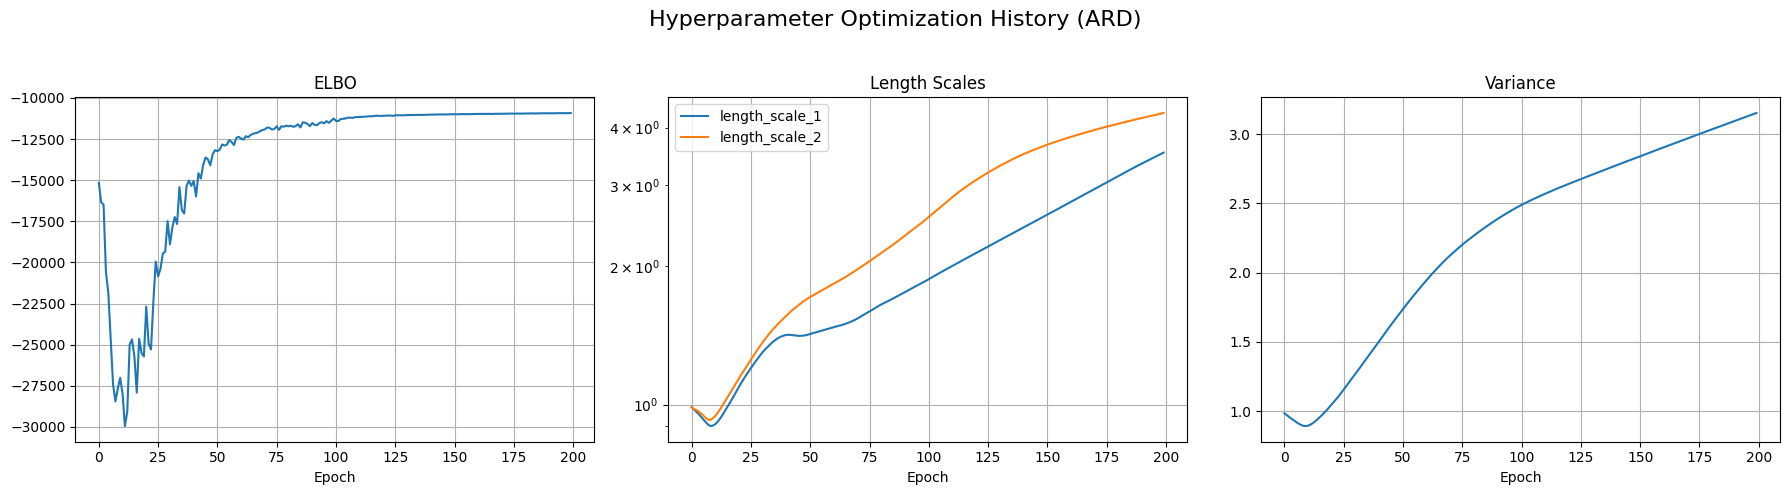

RuntimeError: The size of tensor a (50) must match the size of tensor b (3422) at non-singleton dimension 1

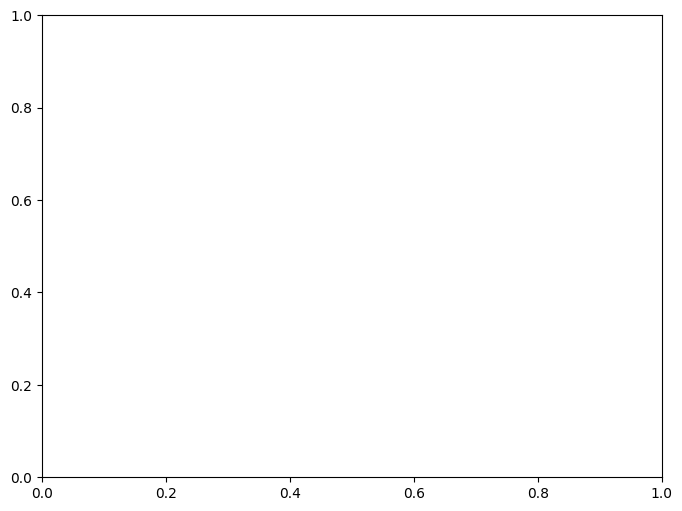

In [24]:
import torch
import torch.nn as nn
from torch.distributions import Normal
from torch.utils.data import TensorDataset, DataLoader
from sklearn.cluster import KMeans
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
import numpy as np
import math
import matplotlib.pyplot as plt
from linear_operator.operators import to_linear_operator, AddedDiagLinearOperator, DiagLinearOperator

# --- KERNEL FUNCTION ---
def rbf_kernel(X1, X2, lengthscale, variance=1.0):
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    X1_scaled = X1 / lengthscale
    X2_scaled = X2 / lengthscale
    sqdist = torch.cdist(X1_scaled, X2_scaled, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist)

# --- SparseGPC MODEL CLASS ---
class SparseGPC(nn.Module):
    def __init__(self, X, y, M, kernel_lengthscale=None, kernel_variance=1.0, device=None):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        y_proc = y.clone().view(-1, 1)
        if not torch.all((y_proc == 1) | (y_proc == -1)):
             raise ValueError("Labels y must be in {-1, 1}")

        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y_proc.to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        self.M = M
        dtype = self.X_full.dtype
        
        self.jitter = 1e-4

        self.Z = nn.Parameter(self._initialize_inducing_points())

        if kernel_lengthscale is None:
            kernel_lengthscale = torch.ones(self.D, dtype=dtype)
        else:
            kernel_lengthscale = torch.as_tensor(kernel_lengthscale, dtype=dtype)
        # Corrected typo: .0 -> 0
        if kernel_lengthscale.ndim == 0:
            kernel_lengthscale = kernel_lengthscale.repeat(self.D)
        self.log_kernel_lengthscale = nn.Parameter(torch.log(kernel_lengthscale))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=dtype)))

        self.register_buffer('nat1_lik', torch.zeros(self.M, 1, dtype=dtype))
        self.register_buffer('Lambda_lik', torch.zeros(self.M, self.M, dtype=dtype))
        
        self.kernel = rbf_kernel
        self.to(self.device)

    def _initialize_inducing_points(self):
        if self.N > self.M:
            X_np = self.X_full.cpu().numpy()
            kmeans = KMeans(n_clusters=self.M, random_state=0, n_init='auto').fit(X_np)
            Z_init = torch.from_numpy(kmeans.cluster_centers_)
        else:
            indices = np.random.choice(self.N, self.M, replace=False)
            Z_init = self.X_full[indices].clone()
        return Z_init.to(dtype=self.X_full.dtype, device=self.device)

    def _get_kernel_params(self):
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }

    def _get_kmm_operator(self, params):
        K_mm_base = to_linear_operator(self.kernel(self.Z, self.Z, params['lengthscale'], params['variance']))
        jitter_diag = torch.full((self.M,), self.jitter, device=self.device, dtype=self.X_full.dtype)
        jitter_op = DiagLinearOperator(jitter_diag)
        return AddedDiagLinearOperator(K_mm_base, jitter_op)

    def _get_std_from_natural(self, K_mm_inv):
        Lambda_prior = K_mm_inv
        Lambda_global = Lambda_prior + self.Lambda_lik
        jitter_mat = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * self.jitter
        S_u = torch.inverse(Lambda_global + jitter_mat)
        m_u = S_u @ self.nat1_lik
        return m_u, S_u

    def _truncated_normal_moments(self, mu, y):
        normal_dist = Normal(torch.tensor(0.0, device=mu.device, dtype=mu.dtype),
                             torch.tensor(1.0, device=mu.device, dtype=mu.dtype))
        alpha = -mu * y
        eps = 1e-8
        pdf_cdf_ratio = torch.exp(normal_dist.log_prob(alpha) - torch.log(normal_dist.cdf(alpha) + eps))
        Ez = mu + y * pdf_cdf_ratio
        Var_z = 1 - alpha * pdf_cdf_ratio - pdf_cdf_ratio.pow(2)
        Ez2 = Var_z + Ez.pow(2)
        return Ez, Ez2

    def update_variational_params(self, X_batch, y_batch, learning_rate):
        B = X_batch.shape[0]
        params = self._get_kernel_params()
        K_mm_op = self._get_kmm_operator(params)
        K_mm_inv = K_mm_op.solve(torch.eye(self.M, device=self.device, dtype=self.X_full.dtype))
        K_mb = self.kernel(self.Z, X_batch, params['lengthscale'], params['variance'])
        m_u, _ = self._get_std_from_natural(K_mm_inv)
        A = K_mm_op.solve(K_mb)
        mu_f_batch = A.T @ m_u
        Ez, _ = self._truncated_normal_moments(mu_f_batch, y_batch)
        delta_nat1 = (self.N / B) * (A @ Ez)
        delta_Lambda = (self.N / B) * (A @ A.T)
        self.nat1_lik.data = (1 - learning_rate) * self.nat1_lik.data + learning_rate * delta_nat1
        self.Lambda_lik.data = (1 - learning_rate) * self.Lambda_lik.data + learning_rate * delta_Lambda

    def forward(self, X_batch, y_batch):
        B = X_batch.shape[0]
        params = self._get_kernel_params()
        K_mm_op = self._get_kmm_operator(params)
        K_mm_inv = K_mm_op.solve(torch.eye(self.M, device=self.device, dtype=self.X_full.dtype))
        K_mb = self.kernel(self.Z, X_batch, params['lengthscale'], params['variance'])
        K_bb_diag = params['variance'].expand(B)
        m_u, S_u = self._get_std_from_natural(K_mm_inv)
        A = K_mm_op.solve(K_mb)
        mu_f = A.T @ m_u
        var_f = K_bb_diag - (A * K_mb).sum(dim=0) + (A * (S_u @ A)).sum(dim=0)
        Ef2 = var_f.view(-1, 1) + mu_f.pow(2)
        Ez, Ez2 = self._truncated_normal_moments(mu_f, y_batch)
        log_lik = -0.5 * math.log(2 * math.pi) - 0.5 * (Ez2 - 2 * Ez * mu_f + Ef2)
        scaled_log_lik = log_lik.sum() * (self.N / B)
        log_det_K = K_mm_op.logdet()
        Lambda_global = K_mm_inv + self.Lambda_lik
        jitter_mat = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * self.jitter
        L_Lambda = torch.linalg.cholesky(Lambda_global + jitter_mat)
        log_det_S = -2 * torch.log(L_Lambda.diag()).sum()
        trace_term = (K_mm_inv @ S_u).trace()
        mahalanobis_term = (m_u.T @ K_mm_inv @ m_u).sum()
        kl_div = 0.5 * (trace_term + mahalanobis_term - self.M + log_det_K - log_det_S)
        elbo = scaled_log_lik - kl_div
        return elbo

    # --- FINAL CORRECTED PREDICT METHOD ---
    def predict(self, X_test):
        X_test_dev = X_test.to(self.device)
        if X_test_dev.ndim == 1: X_test_dev = X_test_dev.unsqueeze(1)
        n_test = X_test_dev.shape[0]
            
        with torch.no_grad():
            params = self._get_kernel_params()

            # Step 1: Compute K_mm_inv, same as in training.
            K_mm = self.kernel(self.Z, self.Z, params['lengthscale'], params['variance'])
            jitter_mat = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * self.jitter
            K_mm_inv = torch.inverse(K_mm + jitter_mat)

            # Step 2: Compute required kernels for the test points.
            # K_sm_T is K_{m*} in notation, shape [M, n_test]
            K_sm_T = self.kernel(self.Z, X_test_dev, params['lengthscale'], params['variance'])
            K_ss_diag = params['variance'].expand(n_test)
            
            # Step 3: Get the current variational posterior over u.
            m_u, S_u = self._get_std_from_natural(K_mm_inv)
            
            # Step 4: Make the definition of A consistent with the forward pass.
            # A = K_mm_inv @ K_m*
            A = K_mm_inv @ K_sm_T  # Shape: [M, n_test]
            
            # Step 5: Compute predictive mean: f* = K_*m @ K_mm_inv @ m_u = A.T @ m_u
            pred_mean_f = A.T @ m_u  # Shape: [n_test, 1]
            
            # Step 6: Compute predictive variance, using the consistent A.
            # Var(f*) = diag(K_** - K_*m @ A + A.T @ S_u @ A)
            K_sm = K_sm_T.T # Shape: [n_test, M]
            
            # Term 2: diag(K_sm @ A) calculated as (K_sm * A.T).sum(dim=1)
            var_term_2 = (K_sm * A.T).sum(dim=1)

            # Term 3: diag(A.T @ S_u @ A) calculated as (A * (S_u @ A)).sum(dim=0)
            var_term_3 = (A * (S_u @ A)).sum(dim=0)

            pred_var_f = K_ss_diag - var_term_2 + var_term_3
            
            # Step 7: Apply the probit function (standard normal CDF).
            probit_arg = pred_mean_f.squeeze() / torch.sqrt(1 + pred_var_f)
            sqrt2 = math.sqrt(2.0)
            pred_prob = 0.5 * (1.0 + torch.erf(probit_arg / sqrt2))
            
            return pred_prob.cpu()

    def predict_proba(self, X_test_np):
        X_test_torch = torch.from_numpy(X_test_np).to(dtype=self.X_full.dtype)
        return self.predict(X_test_torch).numpy()

# --- Main execution block (Unchanged) ---
if __name__ == '__main__':
    def plot_decision_boundary(model, X, y, ax, title):
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        Z = model.predict_proba(grid_points)
        Z = Z.reshape(xx.shape)
        cs = ax.contourf(xx, yy, Z, cmap=plt.cm.RdBu_r, alpha=0.8, levels=np.linspace(0, 1, 11))
        plt.colorbar(cs, ax=ax, label="P(y=1)")
        ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu_r, edgecolors='k', s=50)
        ax.set_title(title)
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")

    def plot_history(history):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle("Hyperparameter Optimization History (ARD)", fontsize=16)
        axes[0].plot(history['elbo']); axes[0].set_title('ELBO')
        ls_history = np.array(history['length_scale'])
        for d in range(ls_history.shape[1]):
            axes[1].plot(ls_history[:, d], label=f'length_scale_{d+1}')
        axes[1].set_title('Length Scales'); axes[1].legend()
        axes[1].set_yscale('log')
        axes[2].plot(history['variance']); axes[2].set_title('Variance')
        for ax in axes: ax.set_xlabel('Epoch'); ax.grid(True)
        fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

    # --- Data Generation ---
    np.random.seed(42)
    n_samples = 150
    X_np, y_np_01 = make_moons(n_samples=n_samples, noise=0.1, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_np)
    X_torch = torch.from_numpy(X_scaled).float()
    y_torch_pm1 = torch.from_numpy(y_np_01).float() * 2 - 1

    # --- Model Training ---
    model = SparseGPC(X_torch, y_torch_pm1, M=30, kernel_lengthscale=1.0)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005) 
    dataset = TensorDataset(X_torch, y_torch_pm1)
    dataloader = DataLoader(dataset, batch_size=50, shuffle=True)
    
    epochs = 200
    svi_lr = 0.05
    history = {'elbo': [], 'length_scale': [], 'variance': []}

    print("Starting training...")
    for epoch in range(epochs):
        epoch_elbo = 0.0
        for X_batch, y_batch in dataloader:
            model.update_variational_params(X_batch, y_batch, learning_rate=svi_lr)
            optimizer.zero_grad()
            elbo = model(X_batch, y_batch)
            loss = -elbo
            loss.backward()
            optimizer.step()
            epoch_elbo += elbo.item()
        
        avg_elbo = epoch_elbo / len(dataloader)
        history['elbo'].append(avg_elbo)
        current_params = model._get_kernel_params()
        history['length_scale'].append(current_params['lengthscale'].detach().cpu().numpy())
        history['variance'].append(current_params['variance'].detach().cpu().numpy())
        
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1}/{epochs}, ELBO: {avg_elbo:.2f}")

    print("Training complete.")

    # --- Plotting Results ---
    plot_history(history)
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    hp = model._get_kernel_params()
    ls_vals = hp["lengthscale"].detach().cpu().numpy()
    ls_str = ", ".join([f"{l:.2f}" for l in ls_vals])
    var_val = hp["variance"].detach().cpu().numpy()

    title = (f'Sparse GPC Decision Boundary (ARD)\n'
             f'l=[{ls_str}], var={var_val:.2f}')
    
    plot_decision_boundary(model, X_scaled, y_np_01, ax, title)
    plt.show()

Starting training...


Epoch 50/500, ELBO: -492.34
Epoch 100/500, ELBO: -446.94
Epoch 150/500, ELBO: -415.24
Epoch 200/500, ELBO: -378.16
Epoch 250/500, ELBO: -337.02
Epoch 300/500, ELBO: -323.89
Epoch 350/500, ELBO: -314.44
Epoch 400/500, ELBO: -317.63
Epoch 450/500, ELBO: -310.32
Epoch 500/500, ELBO: -313.32
Training complete.


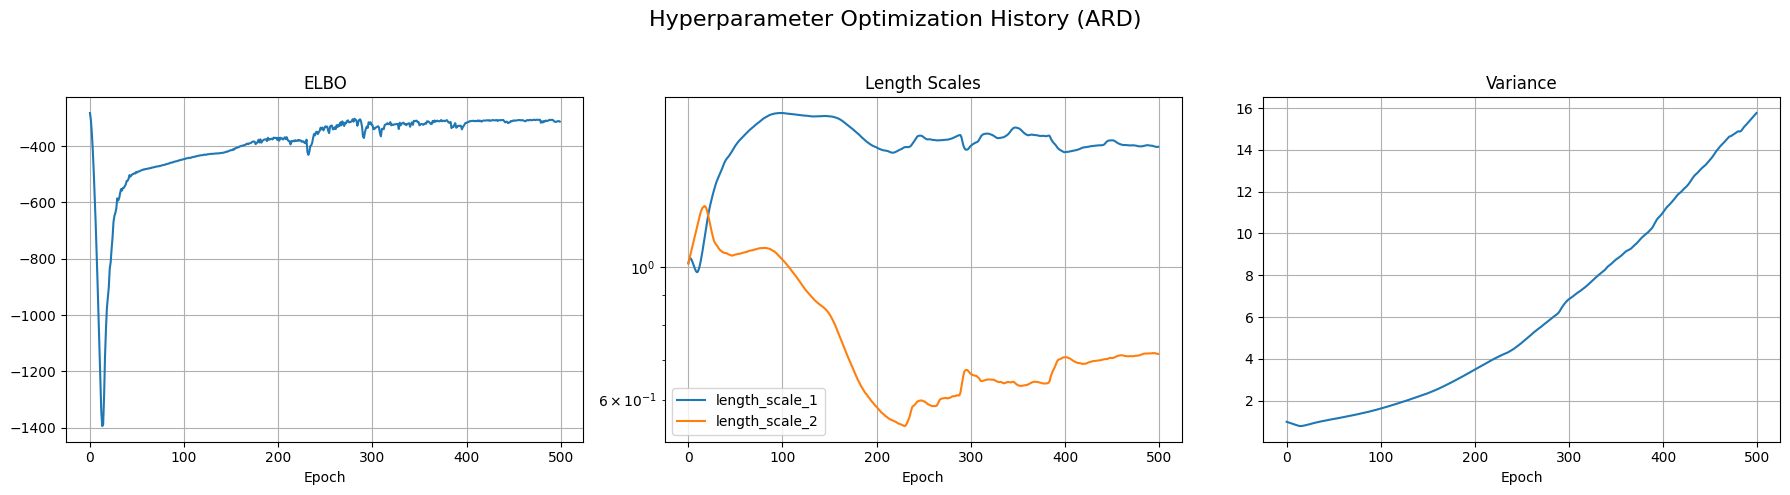

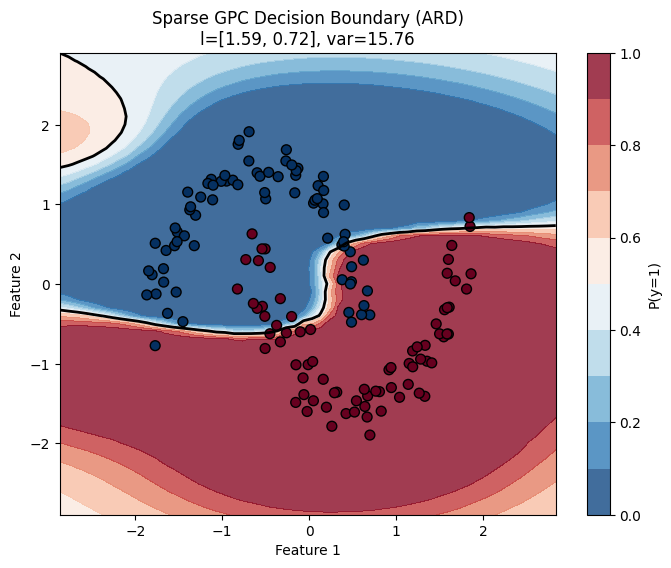

In [28]:
import torch
import torch.nn as nn
from torch.distributions import Normal
from torch.utils.data import TensorDataset, DataLoader
from sklearn.cluster import KMeans
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
import numpy as np
import math
import matplotlib.pyplot as plt
from linear_operator.operators import to_linear_operator, AddedDiagLinearOperator, DiagLinearOperator

# --- KERNEL FUNCTION ---
def rbf_kernel(X1, X2, lengthscale, variance=1.0):
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    X1_scaled = X1 / lengthscale
    X2_scaled = X2 / lengthscale
    sqdist = torch.cdist(X1_scaled, X2_scaled, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist)

# --- FINAL CORRECTED SparseGPC MODEL CLASS ---
class SparseGPC(nn.Module):
    def __init__(self, X, y, M, kernel_lengthscale=None, kernel_variance=1.0, device=None):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        y_proc = y.clone().view(-1, 1)
        if not torch.all((y_proc == 1) | (y_proc == -1)):
             raise ValueError("Labels y must be in {-1, 1}")

        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y_proc.to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        self.M = M
        dtype = self.X_full.dtype
        
        self.jitter = 1e-4

        self.Z = nn.Parameter(self._initialize_inducing_points())

        if kernel_lengthscale is None:
            kernel_lengthscale = torch.ones(self.D, dtype=dtype)
        else:
            kernel_lengthscale = torch.as_tensor(kernel_lengthscale, dtype=dtype)
        if kernel_lengthscale.ndim == 0:
            kernel_lengthscale = kernel_lengthscale.repeat(self.D)
        self.log_kernel_lengthscale = nn.Parameter(torch.log(kernel_lengthscale))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=dtype)))

        self.register_buffer('nat1_lik', torch.zeros(self.M, 1, dtype=dtype))
        self.register_buffer('Lambda_lik', torch.zeros(self.M, self.M, dtype=dtype))
        
        self.kernel = rbf_kernel
        self.to(self.device)

    def _initialize_inducing_points(self):
        if self.N > self.M:
            X_np = self.X_full.cpu().numpy()
            kmeans = KMeans(n_clusters=self.M, random_state=0, n_init='auto').fit(X_np)
            Z_init = torch.from_numpy(kmeans.cluster_centers_)
        else:
            indices = np.random.choice(self.N, self.M, replace=False)
            Z_init = self.X_full[indices].clone()
        return Z_init.to(dtype=self.X_full.dtype, device=self.device)

    def _get_kernel_params(self):
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }

    def _get_kmm_operator(self, params):
        K_mm_base = to_linear_operator(self.kernel(self.Z, self.Z, params['lengthscale'], params['variance']))
        jitter_diag = torch.full((self.M,), self.jitter, device=self.device, dtype=self.X_full.dtype)
        jitter_op = DiagLinearOperator(jitter_diag)
        return AddedDiagLinearOperator(K_mm_base, jitter_op)

    def _get_std_from_natural(self, K_mm_inv):
        Lambda_prior = K_mm_inv
        Lambda_global = Lambda_prior + self.Lambda_lik
        jitter_mat = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * self.jitter
        S_u = torch.inverse(Lambda_global + jitter_mat)
        m_u = S_u @ self.nat1_lik
        return m_u, S_u

    def _truncated_normal_moments(self, mu, y):
        normal_dist = Normal(torch.tensor(0.0, device=mu.device, dtype=mu.dtype),
                             torch.tensor(1.0, device=mu.device, dtype=mu.dtype))
        alpha = -mu * y
        eps = 1e-8
        pdf_cdf_ratio = torch.exp(normal_dist.log_prob(alpha) - torch.log(normal_dist.cdf(alpha) + eps))
        Ez = mu + y * pdf_cdf_ratio
        Var_z = 1 - alpha * pdf_cdf_ratio - pdf_cdf_ratio.pow(2)
        Ez2 = Var_z + Ez.pow(2)
        return Ez, Ez2

    def update_variational_params(self, X_batch, y_batch, learning_rate):
        # --- FIX: Reshape y_batch to prevent broadcasting error ---
        y_batch = y_batch.view(-1, 1)
        
        B = X_batch.shape[0]
        params = self._get_kernel_params()
        K_mm_op = self._get_kmm_operator(params)
        K_mm_inv = K_mm_op.solve(torch.eye(self.M, device=self.device, dtype=self.X_full.dtype))
        K_mb = self.kernel(self.Z, X_batch, params['lengthscale'], params['variance'])
        m_u, _ = self._get_std_from_natural(K_mm_inv)
        A = K_mm_op.solve(K_mb)
        mu_f_batch = A.T @ m_u
        Ez, _ = self._truncated_normal_moments(mu_f_batch, y_batch)
        delta_nat1 = (self.N / B) * (A @ Ez)
        delta_Lambda = (self.N / B) * (A @ A.T)
        self.nat1_lik.data = (1 - learning_rate) * self.nat1_lik.data + learning_rate * delta_nat1
        self.Lambda_lik.data = (1 - learning_rate) * self.Lambda_lik.data + learning_rate * delta_Lambda

    def forward(self, X_batch, y_batch):
        # --- FIX: Reshape y_batch to prevent broadcasting error ---
        y_batch = y_batch.view(-1, 1)
        
        B = X_batch.shape[0]
        params = self._get_kernel_params()
        K_mm_op = self._get_kmm_operator(params)
        K_mm_inv = K_mm_op.solve(torch.eye(self.M, device=self.device, dtype=self.X_full.dtype))
        K_mb = self.kernel(self.Z, X_batch, params['lengthscale'], params['variance'])
        K_bb_diag = params['variance'].expand(B)
        m_u, S_u = self._get_std_from_natural(K_mm_inv)
        A = K_mm_op.solve(K_mb)
        mu_f = A.T @ m_u
        var_f = K_bb_diag - (A * K_mb).sum(dim=0) + (A * (S_u @ A)).sum(dim=0)
        Ef2 = var_f.view(-1, 1) + mu_f.pow(2)
        Ez, Ez2 = self._truncated_normal_moments(mu_f, y_batch)
        log_lik = -0.5 * math.log(2 * math.pi) - 0.5 * (Ez2 - 2 * Ez * mu_f + Ef2)
        scaled_log_lik = log_lik.sum() * (self.N / B)
        log_det_K = K_mm_op.logdet()
        Lambda_global = K_mm_inv + self.Lambda_lik
        jitter_mat = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * self.jitter
        L_Lambda = torch.linalg.cholesky(Lambda_global + jitter_mat)
        log_det_S = -2 * torch.log(L_Lambda.diag()).sum()
        trace_term = (K_mm_inv @ S_u).trace()
        mahalanobis_term = (m_u.T @ K_mm_inv @ m_u).sum()
        kl_div = 0.5 * (trace_term + mahalanobis_term - self.M + log_det_K - log_det_S)
        elbo = scaled_log_lik - kl_div
        return elbo

    def predict(self, X_test):
        X_test_dev = X_test.to(self.device)
        if X_test_dev.ndim == 1: X_test_dev = X_test_dev.unsqueeze(1)
        n_test = X_test_dev.shape[0]
            
        with torch.no_grad():
            params = self._get_kernel_params()

            K_mm = self.kernel(self.Z, self.Z, params['lengthscale'], params['variance'])
            jitter_mat = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * self.jitter
            K_mm_inv = torch.inverse(K_mm + jitter_mat)

            K_sm_T = self.kernel(self.Z, X_test_dev, params['lengthscale'], params['variance'])
            K_ss_diag = params['variance'].expand(n_test)
            
            m_u, S_u = self._get_std_from_natural(K_mm_inv)
            
            A = K_mm_inv @ K_sm_T
            
            pred_mean_f = A.T @ m_u
            
            K_sm = K_sm_T.T
            var_term_2 = (K_sm * A.T).sum(dim=1)
            var_term_3 = (A * (S_u @ A)).sum(dim=0)
            pred_var_f = K_ss_diag - var_term_2 + var_term_3

            probit_arg = pred_mean_f.squeeze() / torch.sqrt(1 + pred_var_f)
            sqrt2 = math.sqrt(2.0)
            pred_prob = 0.5 * (1.0 + torch.erf(probit_arg / sqrt2))
            
            return pred_prob.cpu()

    def predict_proba(self, X_test_np):
        X_test_torch = torch.from_numpy(X_test_np).to(dtype=self.X_full.dtype)
        return self.predict(X_test_torch).numpy()
# --- Main execution block ---
if __name__ == '__main__':
    def plot_decision_boundary(model, X, y, ax, title):
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        Z = model.predict_proba(grid_points)
        Z = Z.reshape(xx.shape)
        cs = ax.contourf(xx, yy, Z, cmap=plt.cm.RdBu_r, alpha=0.8, levels=np.linspace(0, 1, 11))
        plt.colorbar(cs, ax=ax, label="P(y=1)")
        ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu_r, edgecolors='k', s=50)
        ax.set_title(title)
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")

    def plot_history(history):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle("Hyperparameter Optimization History (ARD)", fontsize=16)
        axes[0].plot(history['elbo']); axes[0].set_title('ELBO')
        ls_history = np.array(history['length_scale'])
        for d in range(ls_history.shape[1]):
            axes[1].plot(ls_history[:, d], label=f'length_scale_{d+1}')
        axes[1].set_title('Length Scales'); axes[1].legend()
        axes[1].set_yscale('log')
        axes[2].plot(history['variance']); axes[2].set_title('Variance')
        for ax in axes: ax.set_xlabel('Epoch'); ax.grid(True)
        fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

    # --- Data Generation ---
    np.random.seed(42)
    n_samples = 150
    X_np, y_np_01 = make_moons(n_samples=n_samples, noise=0.1, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_np)
    X_torch = torch.from_numpy(X_scaled).float()
    y_torch_pm1 = torch.from_numpy(y_np_01).float() * 2 - 1

    # --- Model Training ---
    model = SparseGPC(X_torch, y_torch_pm1, M=30, kernel_lengthscale=1.0)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005) 
    dataset = TensorDataset(X_torch, y_torch_pm1)
    dataloader = DataLoader(dataset, batch_size=50, shuffle=True)
    
    epochs = 500
    svi_lr = 0.01
    history = {'elbo': [], 'length_scale': [], 'variance': []}

    print("Starting training...")
    for epoch in range(epochs):
        epoch_elbo = 0.0
        for X_batch, y_batch in dataloader:
            model.update_variational_params(X_batch, y_batch, learning_rate=svi_lr)
            optimizer.zero_grad()
            elbo = model(X_batch, y_batch)
            loss = -elbo
            loss.backward()
            optimizer.step()
            epoch_elbo += elbo.item()
        
        avg_elbo = epoch_elbo / len(dataloader)
        history['elbo'].append(avg_elbo)
        current_params = model._get_kernel_params()
        history['length_scale'].append(current_params['lengthscale'].detach().cpu().numpy())
        history['variance'].append(current_params['variance'].detach().cpu().numpy())
        
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1}/{epochs}, ELBO: {avg_elbo:.2f}")

    print("Training complete.")

    # --- Plotting Results ---
    plot_history(history)
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    hp = model._get_kernel_params()
    ls_vals = hp["lengthscale"].detach().cpu().numpy()
    ls_str = ", ".join([f"{l:.2f}" for l in ls_vals])
    var_val = hp["variance"].detach().cpu().numpy()

    title = (f'Sparse GPC Decision Boundary (ARD)\n'
             f'l=[{ls_str}], var={var_val:.2f}')
    
    plot_decision_boundary(model, X_scaled, y_np_01, ax, title)
    plt.show()

Starting training...
Epoch 50/500, ELBO: -493.29
Epoch 100/500, ELBO: -422.13
Epoch 150/500, ELBO: -392.77
Epoch 200/500, ELBO: -386.32
Epoch 250/500, ELBO: -327.70
Epoch 300/500, ELBO: -306.12
Epoch 350/500, ELBO: -306.69
Epoch 400/500, ELBO: -289.60
Epoch 450/500, ELBO: -285.89
Epoch 500/500, ELBO: -288.06
Training complete.


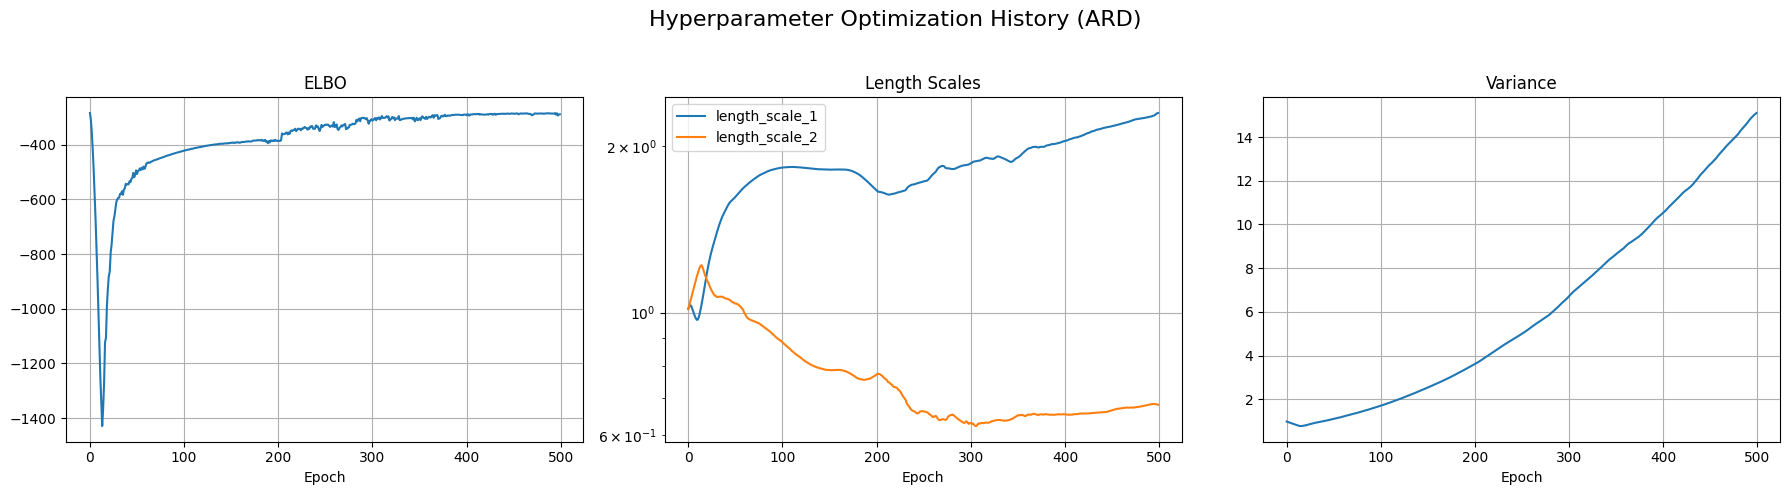

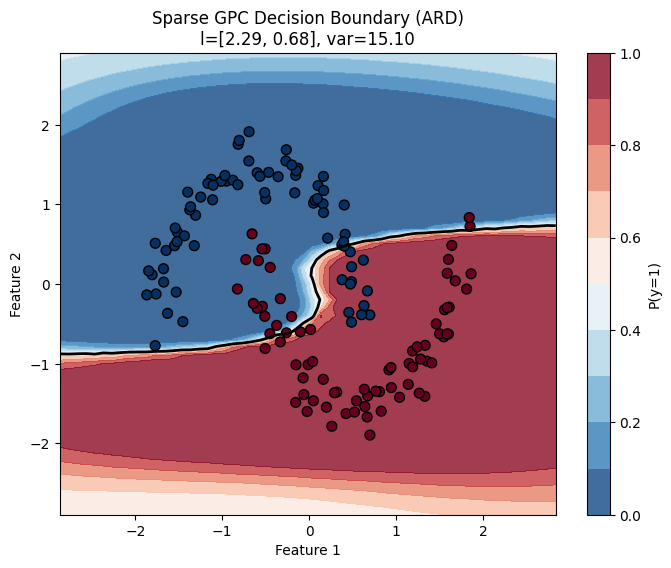

In [29]:
import torch
import torch.nn as nn
from torch.distributions import Normal
from torch.utils.data import TensorDataset, DataLoader
from sklearn.cluster import KMeans
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
import numpy as np
import math
import matplotlib.pyplot as plt
from linear_operator.operators import to_linear_operator, AddedDiagLinearOperator, DiagLinearOperator

# --- KERNEL FUNCTION ---
def rbf_kernel(X1, X2, lengthscale, variance=1.0):
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    X1_scaled = X1 / lengthscale
    X2_scaled = X2 / lengthscale
    sqdist = torch.cdist(X1_scaled, X2_scaled, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist)

# --- FINAL CORRECTED SparseGPC MODEL CLASS ---
class SparseGPC(nn.Module):
    def __init__(self, X, y, M, kernel_lengthscale=None, kernel_variance=1.0, device=None):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        y_proc = y.clone().view(-1, 1)
        if not torch.all((y_proc == 1) | (y_proc == -1)):
             raise ValueError("Labels y must be in {-1, 1}")

        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y_proc.to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        self.M = M
        dtype = self.X_full.dtype
        
        self.jitter = 1e-4

        self.Z = nn.Parameter(self._initialize_inducing_points())

        if kernel_lengthscale is None:
            kernel_lengthscale = torch.ones(self.D, dtype=dtype)
        else:
            kernel_lengthscale = torch.as_tensor(kernel_lengthscale, dtype=dtype)
        if kernel_lengthscale.ndim == 0:
            kernel_lengthscale = kernel_lengthscale.repeat(self.D)
        self.log_kernel_lengthscale = nn.Parameter(torch.log(kernel_lengthscale))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=dtype)))

        self.register_buffer('nat1_lik', torch.zeros(self.M, 1, dtype=dtype))
        self.register_buffer('Lambda_lik', torch.zeros(self.M, self.M, dtype=dtype))
        
        self.kernel = rbf_kernel
        self.to(self.device)

    def _initialize_inducing_points(self):
        if self.N > self.M:
            X_np = self.X_full.cpu().numpy()
            kmeans = KMeans(n_clusters=self.M, random_state=0, n_init='auto').fit(X_np)
            Z_init = torch.from_numpy(kmeans.cluster_centers_)
        else:
            indices = np.random.choice(self.N, self.M, replace=False)
            Z_init = self.X_full[indices].clone()
        return Z_init.to(dtype=self.X_full.dtype, device=self.device)

    def _get_kernel_params(self):
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }

    def _get_kmm_operator(self, params):
        K_mm_base = to_linear_operator(self.kernel(self.Z, self.Z, params['lengthscale'], params['variance']))
        jitter_diag = torch.full((self.M,), self.jitter, device=self.device, dtype=self.X_full.dtype)
        jitter_op = DiagLinearOperator(jitter_diag)
        return AddedDiagLinearOperator(K_mm_base, jitter_op)

    def _get_std_from_natural(self, K_mm_inv):
        Lambda_prior = K_mm_inv
        Lambda_global = Lambda_prior + self.Lambda_lik
        jitter_mat = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * self.jitter
        S_u = torch.inverse(Lambda_global + jitter_mat)
        m_u = S_u @ self.nat1_lik
        return m_u, S_u

    def _truncated_normal_moments(self, mu, y):
        normal_dist = Normal(torch.tensor(0.0, device=mu.device, dtype=mu.dtype),
                             torch.tensor(1.0, device=mu.device, dtype=mu.dtype))
        alpha = -mu * y
        eps = 1e-8
        pdf_cdf_ratio = torch.exp(normal_dist.log_prob(alpha) - torch.log(normal_dist.cdf(alpha) + eps))
        Ez = mu + y * pdf_cdf_ratio
        Var_z = 1 - alpha * pdf_cdf_ratio - pdf_cdf_ratio.pow(2)
        Ez2 = Var_z + Ez.pow(2)
        return Ez, Ez2

    def update_variational_params(self, X_batch, y_batch, learning_rate):
        # Your correct fix: Ensure y_batch is a column vector for correct broadcasting
        y_batch = y_batch.view(-1, 1)
        
        B = X_batch.shape[0]
        params = self._get_kernel_params()
        K_mm_op = self._get_kmm_operator(params)
        K_mm_inv = K_mm_op.solve(torch.eye(self.M, device=self.device, dtype=self.X_full.dtype))
        K_mb = self.kernel(self.Z, X_batch, params['lengthscale'], params['variance'])
        m_u, _ = self._get_std_from_natural(K_mm_inv)
        A = K_mm_op.solve(K_mb)
        mu_f_batch = A.T @ m_u
        Ez, _ = self._truncated_normal_moments(mu_f_batch, y_batch)
        delta_nat1 = (self.N / B) * (A @ Ez)
        delta_Lambda = (self.N / B) * (A @ A.T)
        self.nat1_lik.data = (1 - learning_rate) * self.nat1_lik.data + learning_rate * delta_nat1
        self.Lambda_lik.data = (1 - learning_rate) * self.Lambda_lik.data + learning_rate * delta_Lambda

    def forward(self, X_batch, y_batch):
        # Your correct fix: Ensure y_batch is a column vector
        y_batch = y_batch.view(-1, 1)
        
        B = X_batch.shape[0]
        params = self._get_kernel_params()
        K_mm_op = self._get_kmm_operator(params)
        K_mm_inv = K_mm_op.solve(torch.eye(self.M, device=self.device, dtype=self.X_full.dtype))
        K_mb = self.kernel(self.Z, X_batch, params['lengthscale'], params['variance'])
        K_bb_diag = params['variance'].expand(B)
        m_u, S_u = self._get_std_from_natural(K_mm_inv)
        A = K_mm_op.solve(K_mb)
        mu_f = A.T @ m_u
        var_f = K_bb_diag - (A * K_mb).sum(dim=0) + (A * (S_u @ A)).sum(dim=0)
        Ef2 = var_f.view(-1, 1) + mu_f.pow(2)
        Ez, Ez2 = self._truncated_normal_moments(mu_f, y_batch)
        log_lik = -0.5 * math.log(2 * math.pi) - 0.5 * (Ez2 - 2 * Ez * mu_f + Ef2)
        scaled_log_lik = log_lik.sum() * (self.N / B)
        log_det_K = K_mm_op.logdet()
        Lambda_global = K_mm_inv + self.Lambda_lik
        jitter_mat = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * self.jitter
        L_Lambda = torch.linalg.cholesky(Lambda_global + jitter_mat)
        log_det_S = -2 * torch.log(L_Lambda.diag()).sum()
        trace_term = (K_mm_inv @ S_u).trace()
        mahalanobis_term = (m_u.T @ K_mm_inv @ m_u).sum()
        kl_div = 0.5 * (trace_term + mahalanobis_term - self.M + log_det_K - log_det_S)
        elbo = scaled_log_lik - kl_div
        return elbo

    def predict(self, X_test):
        X_test_dev = X_test.to(self.device)
        if X_test_dev.ndim == 1: X_test_dev = X_test_dev.unsqueeze(1)
        n_test = X_test_dev.shape[0]
            
        with torch.no_grad():
            params = self._get_kernel_params()

            K_mm = self.kernel(self.Z, self.Z, params['lengthscale'], params['variance'])
            jitter_mat = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * self.jitter
            K_mm_inv = torch.inverse(K_mm + jitter_mat)

            # Note: K_sm_T is K(Z, X_test), which is K_ms in standard notation
            K_sm_T = self.kernel(self.Z, X_test_dev, params['lengthscale'], params['variance'])
            K_ss_diag = params['variance'].expand(n_test)
            
            m_u, S_u = self._get_std_from_natural(K_mm_inv)
            
            # A here is K_mm_inv @ K_ms
            A = K_mm_inv @ K_sm_T
            
            # pred_mean is K_sm @ K_mm_inv @ m_u which is (K_mm_inv @ K_ms).T @ m_u
            pred_mean_f = A.T @ m_u
            
            K_sm = K_sm_T.T
            # This is diag(K_sm @ K_mm_inv @ K_ms)
            var_term_2 = (K_sm @ A).diag()
            # This is diag(K_sm @ K_mm_inv @ S_u @ K_mm_inv @ K_ms)
            var_term_3 = (A.T @ S_u @ A).diag()
            pred_var_f = K_ss_diag - var_term_2 + var_term_3

            probit_arg = pred_mean_f.squeeze() / torch.sqrt(1 + pred_var_f)
            sqrt2 = math.sqrt(2.0)
            pred_prob = 0.5 * (1.0 + torch.erf(probit_arg / sqrt2))
            
            return pred_prob.cpu()

    def predict_proba(self, X_test_np):
        X_test_torch = torch.from_numpy(X_test_np).to(dtype=self.X_full.dtype)
        return self.predict(X_test_torch).numpy()
        
# --- Main execution block ---
if __name__ == '__main__':
    def plot_decision_boundary(model, X, y, ax, title):
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        Z = model.predict_proba(grid_points)
        Z = Z.reshape(xx.shape)
        cs = ax.contourf(xx, yy, Z, cmap=plt.cm.RdBu_r, alpha=0.8, levels=np.linspace(0, 1, 11))
        plt.colorbar(cs, ax=ax, label="P(y=1)")
        ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu_r, edgecolors='k', s=50)
        ax.set_title(title)
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")

    def plot_history(history):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle("Hyperparameter Optimization History (ARD)", fontsize=16)
        axes[0].plot(history['elbo']); axes[0].set_title('ELBO')
        ls_history = np.array(history['length_scale'])
        for d in range(ls_history.shape[1]):
            axes[1].plot(ls_history[:, d], label=f'length_scale_{d+1}')
        axes[1].set_title('Length Scales'); axes[1].legend()
        axes[1].set_yscale('log')
        axes[2].plot(history['variance']); axes[2].set_title('Variance')
        for ax in axes: ax.set_xlabel('Epoch'); ax.grid(True)
        fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

    # --- Data Generation ---
    np.random.seed(42)
    n_samples = 150
    X_np, y_np_01 = make_moons(n_samples=n_samples, noise=0.1, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_np)
    X_torch = torch.from_numpy(X_scaled).float()
    y_torch_pm1 = torch.from_numpy(y_np_01).float() * 2 - 1

    # --- Model Training ---
    model = SparseGPC(X_torch, y_torch_pm1, M=30, kernel_lengthscale=1.0)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005) 
    dataset = TensorDataset(X_torch, y_torch_pm1)
    dataloader = DataLoader(dataset, batch_size=50, shuffle=True)
    
    epochs = 500
    svi_lr = 0.01
    history = {'elbo': [], 'length_scale': [], 'variance': []}

    print("Starting training...")
    for epoch in range(epochs):
        epoch_elbo = 0.0
        for X_batch, y_batch in dataloader:
            model.update_variational_params(X_batch, y_batch, learning_rate=svi_lr)
            optimizer.zero_grad()
            elbo = model(X_batch, y_batch)
            loss = -elbo
            loss.backward()
            optimizer.step()
            epoch_elbo += elbo.item()
        
        avg_elbo = epoch_elbo / len(dataloader)
        history['elbo'].append(avg_elbo)
        current_params = model._get_kernel_params()
        history['length_scale'].append(current_params['lengthscale'].detach().cpu().numpy())
        history['variance'].append(current_params['variance'].detach().cpu().numpy())
        
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1}/{epochs}, ELBO: {avg_elbo:.2f}")

    print("Training complete.")

    # --- Plotting Results ---
    plot_history(history)
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    hp = model._get_kernel_params()
    ls_vals = hp["lengthscale"].detach().cpu().numpy()
    ls_str = ", ".join([f"{l:.2f}" for l in ls_vals])
    var_val = hp["variance"].detach().cpu().numpy()

    title = (f'Sparse GPC Decision Boundary (ARD)\n'
             f'l=[{ls_str}], var={var_val:.2f}')
    
    plot_decision_boundary(model, X_scaled, y_np_01, ax, title)
    plt.show()

Starting Variational EM training...


Iter 10/100, ELBO: -702.29
Iter 20/100, ELBO: -739.13
Iter 30/100, ELBO: -722.59
Iter 40/100, ELBO: -671.54
Iter 50/100, ELBO: -609.52
Iter 60/100, ELBO: -603.13
Iter 70/100, ELBO: -576.63
Iter 80/100, ELBO: -545.00
Iter 90/100, ELBO: -536.98
Iter 100/100, ELBO: -578.32
Training complete.
Training complete.


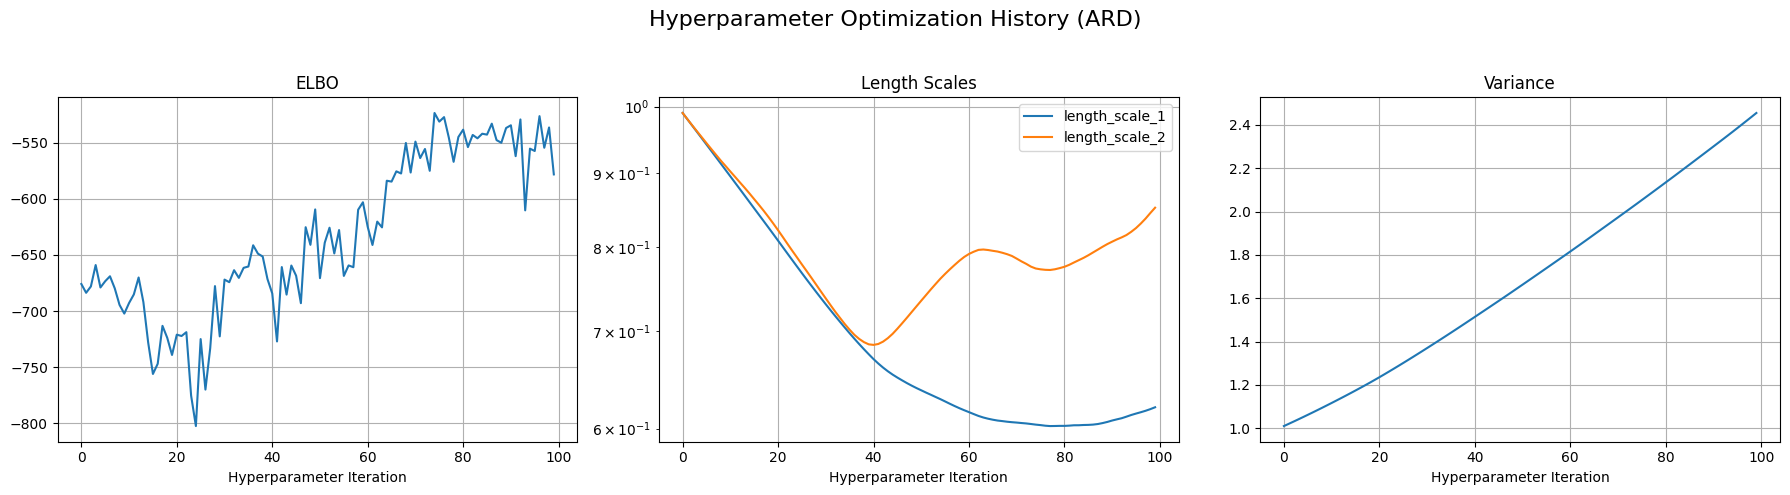

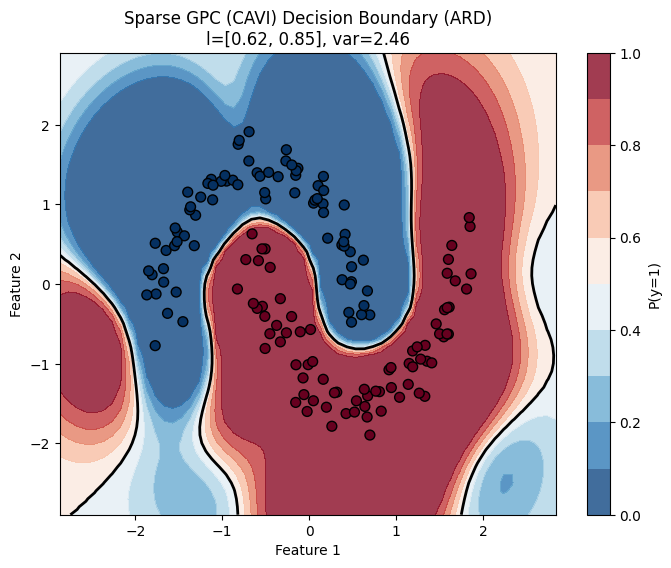

In [31]:
import torch
import torch.nn as nn
from torch.distributions import Normal
from sklearn.cluster import KMeans
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
import numpy as np
import math
import matplotlib.pyplot as plt
from linear_operator.operators import to_linear_operator, AddedDiagLinearOperator, DiagLinearOperator

# --- KERNEL FUNCTION ---
def rbf_kernel(X1, X2, lengthscale, variance=1.0):
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    X1_scaled = X1 / lengthscale
    X2_scaled = X2 / lengthscale
    sqdist = torch.cdist(X1_scaled, X2_scaled, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist)

# --- Full-Batch CAVI SparseGPC MODEL CLASS ---
class SparseGPC_CAVI(nn.Module):
    def __init__(self, X, y, M, kernel_lengthscale=None, kernel_variance=1.0, device=None):
        super().__init__()

        if device is None:
            self.device = X.device if isinstance(X, torch.Tensor) else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)

        y_proc = y.clone().view(-1, 1)
        if not torch.all((y_proc == 1) | (y_proc == -1)):
             raise ValueError("Labels y must be in {-1, 1}")

        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y_proc.to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        self.M = M
        dtype = self.X_full.dtype
        
        self.jitter = 1e-6 # Jitter for stability

        self.Z = nn.Parameter(self._initialize_inducing_points())

        if kernel_lengthscale is None:
            kernel_lengthscale = torch.ones(self.D, dtype=dtype)
        else:
            kernel_lengthscale = torch.as_tensor(kernel_lengthscale, dtype=dtype)
        if kernel_lengthscale.ndim == 0:
            kernel_lengthscale = kernel_lengthscale.repeat(self.D)
        self.log_kernel_lengthscale = nn.Parameter(torch.log(kernel_lengthscale))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=dtype)))

        # Variational parameters for q(u) = N(m_u, S_u)
        self.register_buffer('m_u', torch.zeros(self.M, 1, dtype=dtype))
        self.register_buffer('S_u', torch.eye(self.M, dtype=dtype))
        
        self.kernel = rbf_kernel
        self.to(self.device)

    def _initialize_inducing_points(self):
        if self.N > self.M:
            X_np = self.X_full.cpu().numpy()
            kmeans = KMeans(n_clusters=self.M, random_state=0, n_init='auto').fit(X_np)
            Z_init = torch.from_numpy(kmeans.cluster_centers_)
        else:
            indices = np.random.choice(self.N, self.M, replace=False)
            Z_init = self.X_full[indices].clone()
        return Z_init.to(dtype=self.X_full.dtype, device=self.device)

    def _get_kernel_params(self):
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }

    def _get_kmm_operator(self, params):
        K_mm_base = to_linear_operator(self.kernel(self.Z, self.Z, params['lengthscale'], params['variance']))
        jitter_diag = torch.full((self.M,), self.jitter, device=self.device, dtype=self.X_full.dtype)
        jitter_op = DiagLinearOperator(jitter_diag)
        return AddedDiagLinearOperator(K_mm_base, jitter_op)

    def _truncated_normal_moments(self, mu, y):
        normal_dist = Normal(torch.tensor(0.0, device=mu.device, dtype=mu.dtype),
                             torch.tensor(1.0, device=mu.device, dtype=mu.dtype))
        alpha = -mu * y
        eps = 1e-8
        pdf_cdf_ratio = torch.exp(normal_dist.log_prob(alpha) - torch.log(normal_dist.cdf(alpha) + eps))
        Ez = mu + y * pdf_cdf_ratio
        Var_z = 1 - alpha * pdf_cdf_ratio - pdf_cdf_ratio.pow(2)
        Ez2 = Var_z + Ez.pow(2)
        return Ez, Ez2

    def _cavi_update(self):
        """Performs one full E-step-z and E-step-u update."""
        with torch.no_grad():
            params = self._get_kernel_params()
            K_mm_op = self._get_kmm_operator(params)
            K_nm = self.kernel(self.X_full, self.Z, params['lengthscale'], params['variance'])
            
            # This is K_nm @ K_mm_inv
            # Shape: [N, M]
            A = K_mm_op.solve(K_nm.T).T

            # --- E-Step for q(z) ---
            # Update local variational parameters for q(z_i) for all i=1...N
            # mu_f has shape [N, 1]
            mu_f = A @ self.m_u
            Ez, _ = self._truncated_normal_moments(mu_f, self.y_full)

            # --- E-Step for q(u) ---
            # Update global variational parameters q(u)
            K_mm_inv = K_mm_op.solve(torch.eye(self.M, device=self.device, dtype=self.X_full.dtype))
            
            # Precision matrix from likelihood term: A.T @ I @ A = A.T @ A
            # Shape: [M, M]
            precision_lik = A.T @ A
            
            # Posterior precision: K_mm_inv + precision_lik
            # Shape: [M, M]
            S_u_inv = K_mm_inv + precision_lik
            
            # Posterior covariance
            jitter_mat = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * 1e-6
            S_u_new = torch.inverse(S_u_inv + jitter_mat)
            
            # Posterior mean
            # Shape: [M, 1]
            m_u_new = S_u_new @ (A.T @ Ez)
            
            # Update the state
            self.m_u.data = m_u_new
            self.S_u.data = S_u_new

    def elbo(self):
        """Computes the Evidence Lower Bound for the full dataset."""
        params = self._get_kernel_params()
        K_mm_op = self._get_kmm_operator(params)
        K_nm = self.kernel(self.X_full, self.Z, params['lengthscale'], params['variance'])
        
        A = K_mm_op.solve(K_nm.T).T
        
        # Moments of q(f)
        mu_f = A @ self.m_u
        k_ii = params['variance'].expand(self.N) # Diagonal of K_nn for RBF
        var_f = k_ii - (A * K_nm).sum(dim=1) + (A @ self.S_u * A).sum(dim=1)
        Ef2 = var_f.view(-1, 1) + mu_f.pow(2)
        
        # Moments of q(z)
        Ez, Ez2 = self._truncated_normal_moments(mu_f, self.y_full)
        
        # 1. Expected Log-Likelihood term
        log_lik = -0.5 * math.log(2 * math.pi) - 0.5 * (Ez2 - 2 * Ez * mu_f + Ef2)
        sum_log_lik = log_lik.sum()

        # 2. KL-Divergence term: KL(q(u) || p(u))
        K_mm_inv = K_mm_op.solve(torch.eye(self.M, device=self.device, dtype=self.X_full.dtype))
        log_det_K = K_mm_op.logdet()
        log_det_S = torch.logdet(self.S_u)
        trace_term = (K_mm_inv @ self.S_u).trace()
        mahalanobis_term = (self.m_u.T @ K_mm_inv @ self.m_u).sum()
        
        kl_div = 0.5 * (trace_term + mahalanobis_term - self.M + log_det_K - log_det_S)
        
        return sum_log_lik - kl_div

    def fit(self, n_hyper_iters=100, n_cavi_iters=10, lr=0.01):
        """Full Variational EM training loop."""
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        history = {'elbo': [], 'length_scale': [], 'variance': []}
        
        print("Starting Variational EM training...")
        for i in range(n_hyper_iters):
            # --- E-Step ---
            # Run CAVI updates until convergence for fixed hyperparameters
            for _ in range(n_cavi_iters):
                self._cavi_update()

            # --- M-Step ---
            # Take one gradient step on hyperparameters using the ELBO
            optimizer.zero_grad()
            current_elbo = self.elbo()
            loss = -current_elbo
            loss.backward()
            optimizer.step()
            
            # Logging
            history['elbo'].append(current_elbo.item())
            params = self._get_kernel_params()
            history['length_scale'].append(params['lengthscale'].detach().cpu().numpy())
            history['variance'].append(params['variance'].detach().cpu().numpy())
            
            if (i + 1) % 10 == 0:
                print(f"Iter {i+1}/{n_hyper_iters}, ELBO: {current_elbo.item():.2f}")
                
        print("Training complete.")
        return history

    def predict(self, X_test):
        X_test_dev = X_test.to(self.device)
        if X_test_dev.ndim == 1: X_test_dev = X_test_dev.unsqueeze(1)
            
        with torch.no_grad():
            params = self._get_kernel_params()
            K_mm = self.kernel(self.Z, self.Z, params['lengthscale'], params['variance'])
            jitter_mat = torch.eye(self.M, device=self.device, dtype=self.X_full.dtype) * self.jitter
            K_mm_inv = torch.inverse(K_mm + jitter_mat)
            K_sm = self.kernel(X_test_dev, self.Z, params['lengthscale'], params['variance'])
            K_ss_diag = params['variance'].expand(X_test_dev.shape[0])
            A = K_sm @ K_mm_inv
            pred_mean_f = A @ self.m_u
            pred_var_f = K_ss_diag - (A * K_sm).sum(dim=1) + ((A @ self.S_u) * A).sum(dim=1)
            probit_arg = pred_mean_f.squeeze() / torch.sqrt(1 + pred_var_f)
            sqrt2 = math.sqrt(2.0)
            pred_prob = 0.5 * (1.0 + torch.erf(probit_arg / sqrt2))
            return pred_prob.cpu()

    def predict_proba(self, X_test_np):
        X_test_torch = torch.from_numpy(X_test_np).to(dtype=self.X_full.dtype)
        return self.predict(X_test_torch).numpy()

# --- Main execution block ---
if __name__ == '__main__':
    # ... (Plotting functions remain the same as before) ...
    def plot_decision_boundary(model, X, y, ax, title):
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        Z = model.predict_proba(grid_points)
        Z = Z.reshape(xx.shape)
        cs = ax.contourf(xx, yy, Z, cmap=plt.cm.RdBu_r, alpha=0.8, levels=np.linspace(0, 1, 11))
        plt.colorbar(cs, ax=ax, label="P(y=1)")
        ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu_r, edgecolors='k', s=50)
        ax.set_title(title)
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")

    def plot_history(history):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle("Hyperparameter Optimization History (ARD)", fontsize=16)
        axes[0].plot(history['elbo']); axes[0].set_title('ELBO')
        ls_history = np.array(history['length_scale'])
        for d in range(ls_history.shape[1]):
            axes[1].plot(ls_history[:, d], label=f'length_scale_{d+1}')
        axes[1].set_title('Length Scales'); axes[1].legend()
        axes[1].set_yscale('log')
        axes[2].plot(history['variance']); axes[2].set_title('Variance')
        for ax in axes: ax.set_xlabel('Hyperparameter Iteration'); ax.grid(True)
        fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

    # --- Data Generation ---
    np.random.seed(42)
    n_samples = 150
    X_np, y_np_01 = make_moons(n_samples=n_samples, noise=0.1, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_np)
    X_torch = torch.from_numpy(X_scaled).float()
    y_torch_pm1 = torch.from_numpy(y_np_01).float() * 2 - 1

    # --- Model Training ---
    model = SparseGPC_CAVI(X_torch, y_torch_pm1, M=30, kernel_lengthscale=1.0)
    
    # Train using the Variational EM algorithm
    history = model.fit(n_hyper_iters=100, n_cavi_iters=20, lr=0.01)

    print("Training complete.")

    # --- Plotting Results ---
    plot_history(history)
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    hp = model._get_kernel_params()
    ls_vals = hp["lengthscale"].detach().cpu().numpy()
    ls_str = ", ".join([f"{l:.2f}" for l in ls_vals])
    var_val = hp["variance"].detach().cpu().numpy()

    title = (f'Sparse GPC (CAVI) Decision Boundary (ARD)\n'
             f'l=[{ls_str}], var={var_val:.2f}')
    
    plot_decision_boundary(model, X_scaled, y_np_01, ax, title)
    plt.show()

Using device: cuda
Starting Sparse GPC model hyperparameter optimization...


Iter  10/5000 | ELBO:   -64.59 | l: [0.999, 1.001] | var: 1.001
Iter  20/5000 | ELBO:   -64.53 | l: [0.998, 1.002] | var: 1.002
Iter  30/5000 | ELBO:   -64.47 | l: [0.997, 1.003] | var: 1.003
Iter  40/5000 | ELBO:   -64.40 | l: [0.996, 1.004] | var: 1.004
Iter  50/5000 | ELBO:   -64.34 | l: [0.995, 1.005] | var: 1.005
Iter  60/5000 | ELBO:   -64.27 | l: [0.994, 1.006] | var: 1.006
Iter  70/5000 | ELBO:   -64.21 | l: [0.993, 1.007] | var: 1.007
Iter  80/5000 | ELBO:   -64.15 | l: [0.992, 1.008] | var: 1.008
Iter  90/5000 | ELBO:   -64.09 | l: [0.991, 1.009] | var: 1.009
Iter 100/5000 | ELBO:   -64.02 | l: [0.990, 1.010] | var: 1.010
Iter 110/5000 | ELBO:   -63.96 | l: [0.989, 1.011] | var: 1.011
Iter 120/5000 | ELBO:   -63.90 | l: [0.988, 1.012] | var: 1.012
Iter 130/5000 | ELBO:   -63.84 | l: [0.987, 1.013] | var: 1.013
Iter 140/5000 | ELBO:   -63.78 | l: [0.986, 1.014] | var: 1.014
Iter 150/5000 | ELBO:   -63.72 | l: [0.985, 1.015] | var: 1.015
Iter 160/5000 | ELBO:   -63.66 | l: [0.9

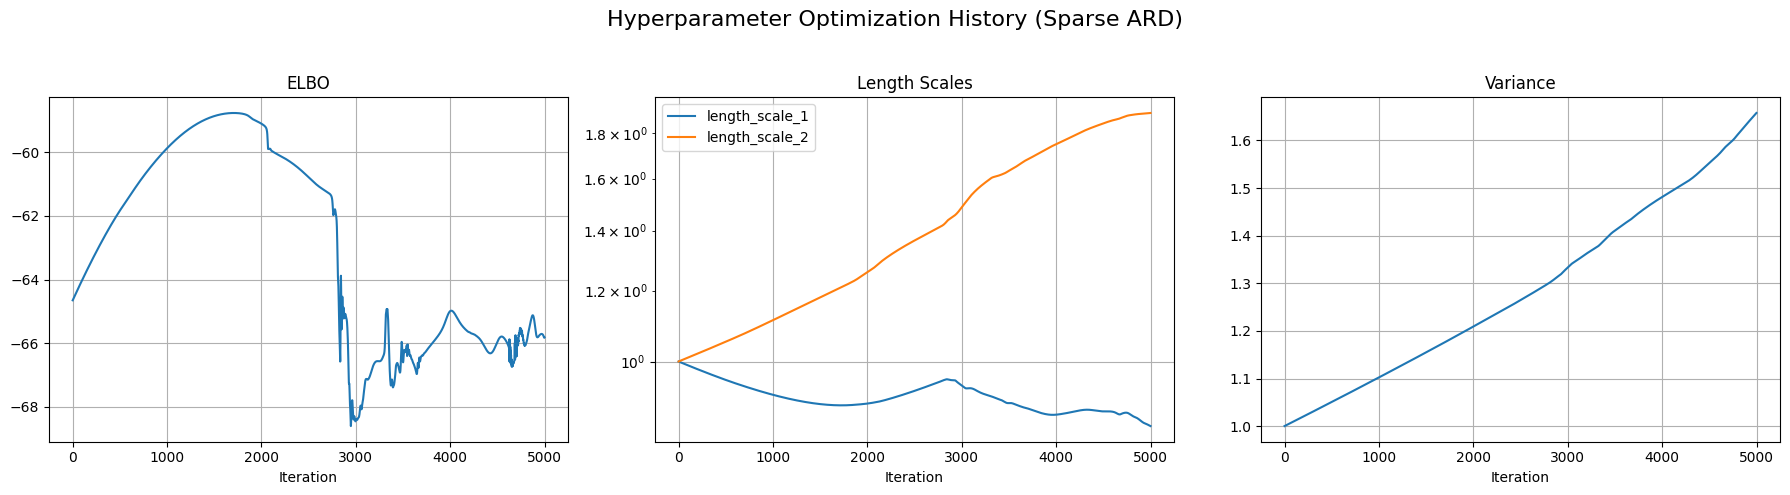

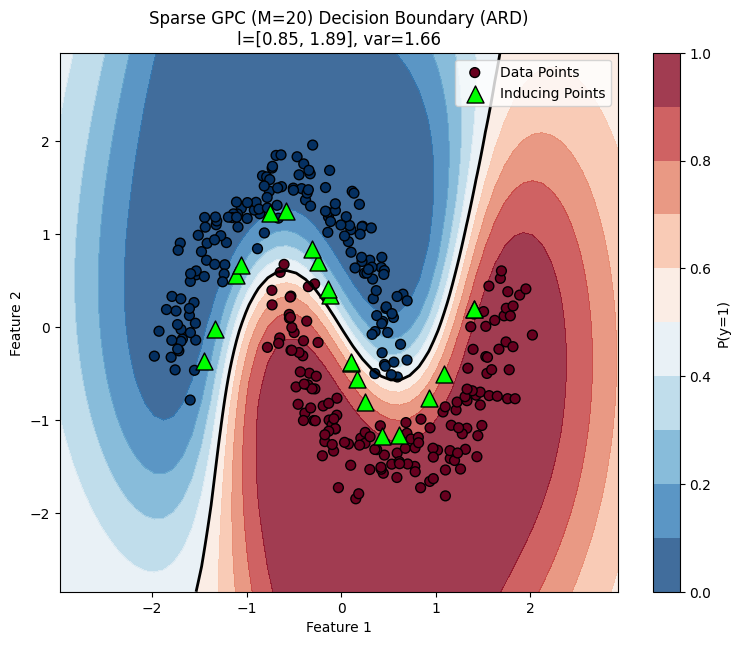

In [38]:
import torch
import torch.optim as optim
from torch.distributions import Normal
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import math

# --- PyTorchのセットアップ ---
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- ヘルパー関数 (変更なし) ---
def get_truncnorm_moments(y, mu, sigma_sq):
    sigma = torch.sqrt(sigma_sq)
    alpha = y * mu / sigma
    std_normal = Normal(torch.tensor([0.0], device=device), torch.tensor([1.0], device=device))
    pdf_alpha = torch.exp(std_normal.log_prob(alpha))
    cdf_alpha = std_normal.cdf(alpha).clamp(min=1e-12)
    ratio = pdf_alpha / cdf_alpha
    exp_z = mu + y * sigma * ratio
    var_z = sigma_sq * (1 - ratio * (alpha + ratio))
    exp_z_sq = var_z + exp_z**2
    return exp_z, exp_z_sq

def get_truncnorm_entropy(y, mu, sigma_sq):
    sigma = torch.sqrt(sigma_sq)
    alpha = y * mu / sigma
    std_normal = Normal(torch.tensor([0.0], device=device), torch.tensor([1.0], device=device))
    pdf_alpha = torch.exp(std_normal.log_prob(alpha))
    cdf_alpha = std_normal.cdf(alpha).clamp(min=1e-12)
    H = torch.log(torch.sqrt(2 * torch.pi * torch.e * sigma_sq) * cdf_alpha) - \
        alpha * pdf_alpha / (2 * cdf_alpha)
    return H

# --- PyTorch Sparse GPC_VI Model ---
class SparseGPC_VI_PyTorch(torch.nn.Module):
    def __init__(self, n_inducing_points, n_cavi_iters=15, cavi_tol=1e-5, initial_length_scale=1.0, initial_variance=1.0):
        super().__init__()
        self.M = n_inducing_points
        self.n_cavi_iters = n_cavi_iters
        self.cavi_tol = cavi_tol
        self.X_train_, self.y_train_ = None, None
        self.variational_params_ = None

        # --- Learnable Hyperparameters ---
        self.log_length_scale = None # ARD, initialized in fit()
        self.initial_length_scale = initial_length_scale
        self.log_variance = torch.nn.Parameter(torch.log(torch.tensor(initial_variance, device=device)))
        # Inducing points Z are also learnable parameters
        self.inducing_points_Z = None

    def _compute_rbf_kernel(self, X1, X2, length_scale, variance):
        X1_scaled = X1 / length_scale
        X2_scaled = X2 / length_scale
        sqdist = torch.sum(X1_scaled**2, 1).reshape(-1, 1) + torch.sum(X2_scaled**2, 1) - 2 * (X1_scaled @ X2_scaled.T)
        sqdist = torch.clamp(sqdist, min=0.0)
        return variance * torch.exp(-0.5 * sqdist)

    def _get_hyperparams(self):
        return {
            'length_scale': torch.exp(self.log_length_scale),
            'variance': torch.exp(self.log_variance),
            'inducing_points_Z': self.inducing_points_Z
        }

    def _gpc_cavi_fit_torch(self, K_ZZ, K_XZ):
        with torch.no_grad():
            N = self.X_train_.shape[0]
            M = self.M
            K_ZZ_inv = torch.linalg.inv(K_ZZ)
            A = K_XZ @ K_ZZ_inv # Precompute for efficiency

            # Initialize variational params for q(u)
            m_u = torch.zeros(M, device=device)
            S_u = K_ZZ.clone() # Initialize S_u to the prior covariance

            for i in range(self.n_cavi_iters):
                m_u_old = m_u.clone()

                # 1. Update q(z_i) based on current q(u)
                mu_f = A @ m_u
                E_z, _ = get_truncnorm_moments(self.y_train_, mu_f, torch.ones_like(mu_f))

                # 2. Update q(u) based on current q(z)
                # This corresponds to Eqs. 21 and 22 in the derivation
                S_u_inv = K_ZZ_inv + A.T @ A
                S_u = torch.linalg.inv(S_u_inv)
                m_u = S_u @ (A.T @ E_z)

                if torch.linalg.norm(m_u - m_u_old) < self.cavi_tol:
                    break
            
            # Final calculation of moments needed for ELBO
            mu_f_final = A @ m_u
            E_z_final, E_z_sq_final = get_truncnorm_moments(self.y_train_, mu_f_final, torch.ones_like(mu_f_final))

            return {
                "m_u": m_u, "S_u": S_u,
                "E_z": E_z_final, "E_z_sq": E_z_sq_final
            }

    def _gpc_elbo_torch(self, variational_params, hp, K_ZZ, K_XZ):
        # This function implements the *correct* ELBO
        N, M = self.X_train_.shape[0], self.M
        m_u, S_u = variational_params["m_u"], variational_params["S_u"]
        E_z, E_z_sq = variational_params["E_z"], variational_params["E_z_sq"]
        variance = hp['variance']
        
        K_ZZ_inv = torch.linalg.inv(K_ZZ)
        A = K_XZ @ K_ZZ_inv

        # --- Expected Log Likelihood Term: E[log p(z|f)] ---
        mu_f = A @ m_u
        
        # --- THIS LINE IS REMOVED ---
        # K_tilde = torch.sum(A * (self.X_train_ @ K_ZZ_inv), dim=1) # This was incorrect and caused the error.

        # This is the correct calculation for the diagonal of the conditional prior variance
        K_tilde_diag = variance - torch.sum(A * K_XZ, dim=1)
        
        var_f = K_tilde_diag + torch.sum(A.T * (S_u @ A.T), dim=0)
        E_f_sq = var_f + mu_f**2
        E_f_minus_z_sq = E_z_sq - 2 * E_z * mu_f + E_f_sq
        exp_log_lik = torch.sum(-0.5 * math.log(2 * math.pi) - 0.5 * E_f_minus_z_sq)

        # --- KL Divergence Term: KL(q(u) || p(u)) ---
        log_det_K_ZZ = torch.linalg.slogdet(K_ZZ).logabsdet
        log_det_S_u = torch.linalg.slogdet(S_u).logabsdet
        kl_u = 0.5 * (torch.trace(K_ZZ_inv @ S_u) + m_u.T @ K_ZZ_inv @ m_u - log_det_S_u + log_det_K_ZZ - M)
        
        # --- Entropy Term: H(q(z)) ---
        H_q_z = torch.sum(get_truncnorm_entropy(self.y_train_, mu_f, torch.ones_like(mu_f)))

        elbo = exp_log_lik - kl_u + H_q_z
        return -elbo # We minimize the negative ELBO

    def fit(self, X, y, n_hyper_iters=50, learning_rate=0.01):
        self.X_train_ = torch.tensor(X, device=device, dtype=torch.get_default_dtype())
        self.y_train_ = torch.tensor(2 * y - 1, device=device, dtype=torch.get_default_dtype())

        # Initialize ARD and Inducing Point parameters
        if self.log_length_scale is None:
            n_features = self.X_train_.shape[1]
            initial_ls = torch.full((n_features,), self.initial_length_scale, device=device)
            self.log_length_scale = torch.nn.Parameter(torch.log(initial_ls))
            
            # Initialize inducing points with K-Means
            kmeans = KMeans(n_clusters=self.M, random_state=0, n_init=10).fit(X)
            initial_Z = torch.tensor(kmeans.cluster_centers_, device=device)
            self.inducing_points_Z = torch.nn.Parameter(initial_Z)

        optimizer = optim.Adam(self.parameters(), lr=learning_rate)
        history = {'elbo': [], 'length_scale': [], 'variance': []}
        print("Starting Sparse GPC model hyperparameter optimization...")

        for i in range(n_hyper_iters):
            optimizer.zero_grad()

            hp = self._get_hyperparams()
            K_ZZ = self._compute_rbf_kernel(hp['inducing_points_Z'], hp['inducing_points_Z'], hp['length_scale'], hp['variance'])
            K_ZZ += torch.eye(self.M, device=device) * 1e-6
            K_XZ = self._compute_rbf_kernel(self.X_train_, hp['inducing_points_Z'], hp['length_scale'], hp['variance'])

            variational_params = self._gpc_cavi_fit_torch(K_ZZ, K_XZ)
            loss = self._gpc_elbo_torch(variational_params, hp, K_ZZ, K_XZ)
            
            loss.backward()
            optimizer.step()

            current_hp = self._get_hyperparams()
            history['elbo'].append(-loss.item())
            history['length_scale'].append(current_hp['length_scale'].detach().cpu().numpy())
            history['variance'].append(current_hp['variance'].item())

            if (i+1) % 10 == 0:
                 ls_str = ", ".join([f"{l:.3f}" for l in current_hp['length_scale']])
                 print(f"Iter {i+1:3d}/{n_hyper_iters} | ELBO: {-loss.item():8.2f} | "
                       f"l: [{ls_str}] | var: {current_hp['variance']:.3f}")

        # Store final variational parameters
        hp_final = self._get_hyperparams()
        K_ZZ_final = self._compute_rbf_kernel(hp_final['inducing_points_Z'], hp_final['inducing_points_Z'], hp_final['length_scale'], hp_final['variance'])
        K_ZZ_final += torch.eye(self.M, device=device) * 1e-6
        K_XZ_final = self._compute_rbf_kernel(self.X_train_, hp_final['inducing_points_Z'], hp_final['length_scale'], hp_final['variance'])
        self.variational_params_ = self._gpc_cavi_fit_torch(K_ZZ_final, K_XZ_final)
        print("Training complete.")
        return history

    def predict_proba(self, X_test):
        with torch.no_grad():
            if self.variational_params_ is None:
                raise RuntimeError("Model has not been trained yet. Call fit() first.")

            X_test_t = torch.tensor(X_test, device=device, dtype=torch.get_default_dtype())
            hp = self._get_hyperparams()
            m_u, S_u = self.variational_params_["m_u"], self.variational_params_["S_u"]
            Z = hp['inducing_points_Z']
            
            # Precompute kernel matrices
            K_ZZ = self._compute_rbf_kernel(Z, Z, hp['length_scale'], hp['variance'])
            K_ZZ += torch.eye(self.M, device=device) * 1e-6
            K_ZZ_inv = torch.linalg.inv(K_ZZ)
            k_star_Z = self._compute_rbf_kernel(X_test_t, Z, hp['length_scale'], hp['variance'])
            
            # Predictive mean and variance (Eqs. 24 & 25)
            mu_star = k_star_Z @ K_ZZ_inv @ m_u
            
            k_star_star_diag = hp['variance'] * torch.ones(X_test_t.shape[0], device=device)
            var_term1 = k_star_star_diag
            var_term2 = torch.sum((k_star_Z @ K_ZZ_inv) * k_star_Z, dim=1)
            var_term3 = torch.sum((k_star_Z @ K_ZZ_inv).T * (S_u @ (k_star_Z @ K_ZZ_inv).T), dim=0)
            
            sigma_sq_star = var_term1 - var_term2 + var_term3
            sigma_sq_star = torch.clamp(sigma_sq_star, min=1e-9)

            # Final probability (Eq. 26)
            prob = Normal(0, 1).cdf(mu_star / torch.sqrt(1 + sigma_sq_star))
            return prob.cpu().numpy()

# --- Main execution block ---
if __name__ == '__main__':
    def plot_decision_boundary_sparse(model, X, y, ax, title):
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        Z_prob = model.predict_proba(grid_points).reshape(xx.shape)
        
        cs = ax.contourf(xx, yy, Z_prob, cmap=plt.cm.RdBu_r, alpha=0.8, levels=np.linspace(0, 1, 11))
        plt.colorbar(cs, ax=ax, label="P(y=1)")
        ax.contour(xx, yy, Z_prob, levels=[0.5], colors='black', linewidths=2)
        
        # Plot data points
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu_r, edgecolors='k', s=50, label='Data Points')
        
        # Plot inducing points
        inducing_points = model.inducing_points_Z.detach().cpu().numpy()
        ax.scatter(inducing_points[:, 0], inducing_points[:, 1], c='lime', marker='^', edgecolors='k', s=150, label='Inducing Points', zorder=3)
        
        ax.set_title(title)
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")
        ax.legend()

    def plot_history(history):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle("Hyperparameter Optimization History (Sparse ARD)", fontsize=16)
        axes[0].plot(history['elbo']); axes[0].set_title('ELBO')
        ls_history = np.array(history['length_scale'])
        for d in range(ls_history.shape[1]):
            axes[1].plot(ls_history[:, d], label=f'length_scale_{d+1}')
        axes[1].set_title('Length Scales'); axes[1].legend(); axes[1].set_yscale('log')
        axes[2].plot(history['variance']); axes[2].set_title('Variance')
        for ax in axes: ax.set_xlabel('Iteration'); ax.grid(True)
        fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

    # --- Data Generation ---
    np.random.seed(42)
    n_samples = 300 # More samples to motivate the sparse model
    X, y_true = make_moons(n_samples=n_samples, noise=0.1, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --- Model Training ---
    M = 20 # Number of inducing points
    gpc_sparse = SparseGPC_VI_PyTorch(n_inducing_points=M, n_cavi_iters=20)
    history = gpc_sparse.fit(X_scaled, y_true, n_hyper_iters=5000, learning_rate=0.0001)

    # --- Plotting Results ---
    plot_history(history)
    fig, ax = plt.subplots(1, 1, figsize=(9, 7))

    hp = gpc_sparse._get_hyperparams()
    ls_vals = hp["length_scale"].detach().cpu().numpy()
    ls_str = ", ".join([f"{l:.2f}" for l in ls_vals])
    title = (f'Sparse GPC (M={M}) Decision Boundary (ARD)\n'
             f'l=[{ls_str}], var={hp["variance"]:.2f}')
    plot_decision_boundary_sparse(gpc_sparse, X_scaled, y_true, ax, title)
    plt.show()

Using device: cuda
--- Running Initial Diagnostic ---
Plotting the ELBO change within a single CAVI run for diagnosis...


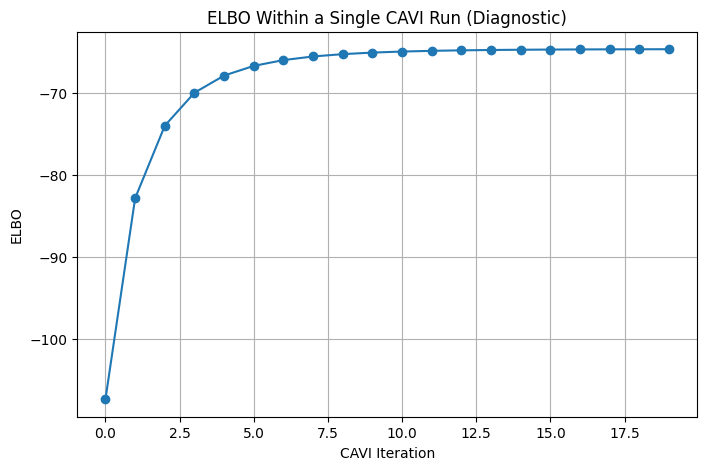

--- Diagnostic Complete. Starting Full Optimization... ---


Iter  10/200 | ELBO:   -59.73 | l: [0.907, 1.105] | var: 1.105
Iter  20/200 | ELBO:   -56.79 | l: [0.839, 1.227] | var: 1.217
Iter  30/200 | ELBO:   -56.46 | l: [0.821, 1.366] | var: 1.334
Iter  40/200 | ELBO:   -57.11 | l: [0.847, 1.512] | var: 1.460
Iter  50/200 | ELBO:   -57.28 | l: [0.875, 1.682] | var: 1.598
Iter  60/200 | ELBO:   -58.26 | l: [0.930, 1.818] | var: 1.743
Iter  70/200 | ELBO:   -60.04 | l: [0.992, 1.991] | var: 1.903
Iter  80/200 | ELBO:   -59.46 | l: [1.009, 2.217] | var: 2.101
Iter  90/200 | ELBO:   -59.25 | l: [1.010, 2.389] | var: 2.333
Iter 100/200 | ELBO:   -58.46 | l: [1.006, 2.591] | var: 2.592
Iter 110/200 | ELBO:   -60.37 | l: [0.974, 2.926] | var: 2.893
Iter 120/200 | ELBO:   -57.66 | l: [0.959, 3.186] | var: 3.222
Iter 130/200 | ELBO:   -60.12 | l: [0.988, 3.295] | var: 3.573
Iter 140/200 | ELBO:   -57.69 | l: [1.016, 3.564] | var: 3.958
Iter 150/200 | ELBO:   -59.05 | l: [1.069, 3.881] | var: 4.383
Iter 160/200 | ELBO:   -61.85 | l: [1.117, 4.372] | var

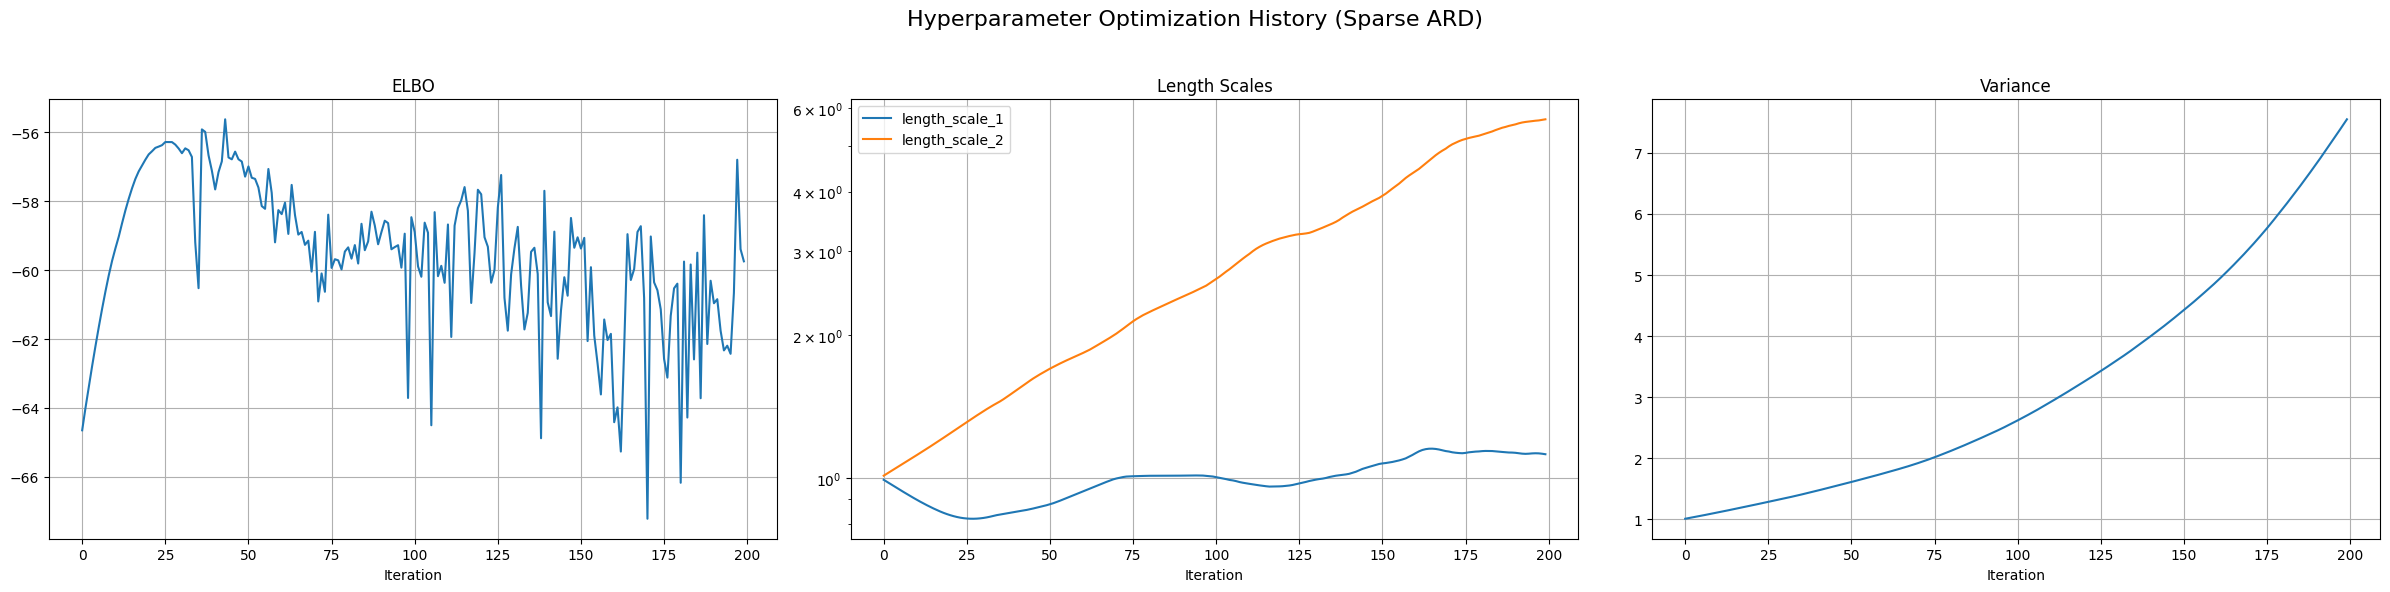

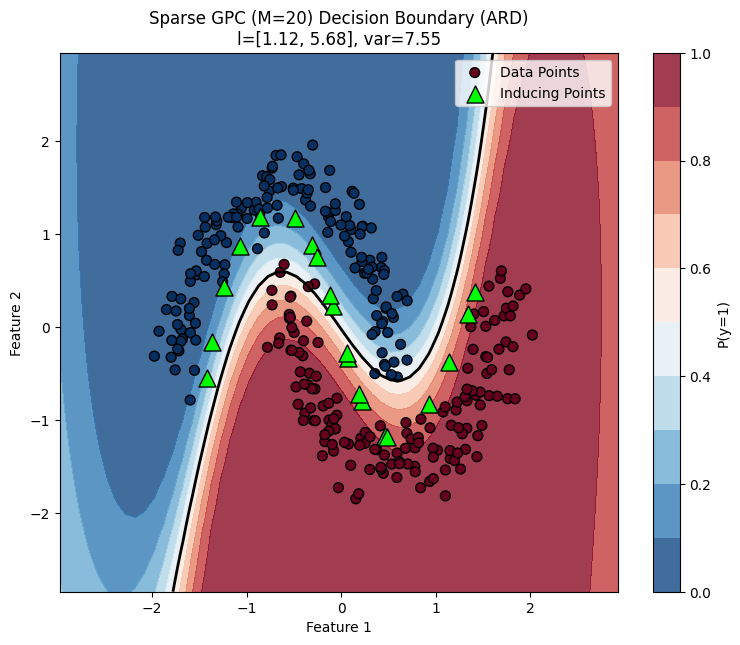

In [3]:
import torch
import torch.optim as optim
from torch.distributions import Normal
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import math

# --- PyTorch Setup ---
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Helper Functions ---
def get_truncnorm_moments(y, mu, sigma_sq):
    sigma = torch.sqrt(sigma_sq)
    alpha = y * mu / sigma
    std_normal = Normal(torch.tensor([0.0], device=device), torch.tensor([1.0], device=device))
    pdf_alpha = torch.exp(std_normal.log_prob(alpha))
    cdf_alpha = std_normal.cdf(alpha).clamp(min=1e-12)
    ratio = pdf_alpha / cdf_alpha
    
    exp_z = mu + y * sigma * ratio
    var_z = sigma_sq * (1 - ratio * (alpha + ratio))
    exp_z_sq = var_z + exp_z**2
    return exp_z, exp_z_sq

def get_truncnorm_entropy(y, mu, sigma_sq):
    sigma = torch.sqrt(sigma_sq)
    alpha = y * mu / sigma
    std_normal = Normal(torch.tensor([0.0], device=device), torch.tensor([1.0], device=device))
    pdf_alpha = torch.exp(std_normal.log_prob(alpha))
    cdf_alpha = std_normal.cdf(alpha).clamp(min=1e-12)
    
    H = torch.log(torch.sqrt(2 * torch.pi * torch.e * sigma_sq) * cdf_alpha) - \
        alpha * pdf_alpha / (2 * cdf_alpha)
    return H

# --- DIAGNOSTIC: Plotting function for internal CAVI ELBO ---
def plot_cavi_elbo_history(history, ax):
    ax.plot(history, marker='o', linestyle='-')
    ax.set_title("ELBO Within a Single CAVI Run (Diagnostic)")
    ax.set_xlabel("CAVI Iteration")
    ax.set_ylabel("ELBO")
    ax.grid(True)
    print("Plotting the ELBO change within a single CAVI run for diagnosis...")


# --- PyTorch Sparse GPC_VI Model ---
class SparseGPC_VI_PyTorch(torch.nn.Module):
    def __init__(self, n_inducing_points, n_cavi_iters=15, cavi_tol=1e-5, initial_length_scale=1.0, initial_variance=1.0):
        super().__init__()
        self.M = n_inducing_points
        self.n_cavi_iters = n_cavi_iters
        self.cavi_tol = cavi_tol
        self.X_train_, self.y_train_ = None, None
        self.variational_params_ = None

        self.log_length_scale = None
        self.initial_length_scale = initial_length_scale
        self.log_variance = torch.nn.Parameter(torch.log(torch.tensor(initial_variance, device=device)))
        self.inducing_points_Z = None

    def _compute_rbf_kernel(self, X1, X2, length_scale, variance):
        X1_scaled = X1 / length_scale
        X2_scaled = X2 / length_scale
        sqdist = torch.sum(X1_scaled**2, 1).reshape(-1, 1) + torch.sum(X2_scaled**2, 1) - 2 * (X1_scaled @ X2_scaled.T)
        sqdist = torch.clamp(sqdist, min=0.0)
        return variance * torch.exp(-0.5 * sqdist)

    def _get_hyperparams(self):
        return {
            'length_scale': torch.exp(self.log_length_scale),
            'variance': torch.exp(self.log_variance),
            'inducing_points_Z': self.inducing_points_Z
        }

    def _gpc_cavi_fit_torch(self, K_ZZ, K_XZ, hp, initial_m_u=None, initial_S_u=None, track_elbo=False):
        """
        Performs CAVI. Includes optional ELBO tracking for diagnostics.
        """
        with torch.no_grad():
            M = self.M
            K_ZZ_inv = torch.linalg.inv(K_ZZ)
            A = K_XZ @ K_ZZ_inv

            m_u = torch.zeros(M, device=device) if initial_m_u is None else initial_m_u.clone()
            S_u = K_ZZ.clone() if initial_S_u is None else initial_S_u.clone()

            cavi_elbo_history = []

            elbo = -1000000000000

            for i in range(self.n_cavi_iters):
                m_u_old = m_u.clone()

                mu_f = A @ m_u
                E_z, _ = get_truncnorm_moments(self.y_train_, mu_f, torch.ones_like(mu_f))

                S_u_inv = K_ZZ_inv + A.T @ A
                S_u = torch.linalg.inv(S_u_inv)
                m_u = S_u @ (A.T @ E_z)

                # --- DIAGNOSTIC: Track ELBO at each internal step ---
                if track_elbo:
                    mu_f_track = A @ m_u
                    E_z_track, E_z_sq_track = get_truncnorm_moments(self.y_train_, mu_f_track, torch.ones_like(mu_f_track))
                    temp_params = {"m_u": m_u, "S_u": S_u, "E_z": E_z_track, "E_z_sq": E_z_sq_track}
                    elbo_ = -self._gpc_elbo_torch(temp_params, hp, K_ZZ, K_XZ)

                    if elbo >= elbo_:
                        print(f"elbo declining")
                    
                    elbo = elbo_

                    cavi_elbo_history.append(elbo.item())
                # --- END DIAGNOSTIC ---

                if torch.linalg.norm(m_u - m_u_old) < self.cavi_tol:
                    break
            
            mu_f_final = A @ m_u
            E_z_final, E_z_sq_final = get_truncnorm_moments(self.y_train_, mu_f_final, torch.ones_like(mu_f_final))
            final_params = {"m_u": m_u, "S_u": S_u, "E_z": E_z_final, "E_z_sq": E_z_sq_final}
            
            return final_params, cavi_elbo_history

    def _gpc_elbo_torch(self, variational_params, hp, K_ZZ, K_XZ):
        N, M = self.X_train_.shape[0], self.M
        m_u, S_u = variational_params["m_u"], variational_params["S_u"]
        E_z, E_z_sq = variational_params["E_z"], variational_params["E_z_sq"]
        variance = hp['variance']
        
        K_ZZ_inv = torch.linalg.inv(K_ZZ)
        A = K_XZ @ K_ZZ_inv

        mu_f = A @ m_u
        K_tilde_diag = variance - torch.sum(A * K_XZ, dim=1)
        var_f = K_tilde_diag + torch.sum(A.T * (S_u @ A.T), dim=0)
        E_f_sq = var_f + mu_f**2
        E_f_minus_z_sq = E_z_sq - 2 * E_z * mu_f + E_f_sq
        exp_log_lik = torch.sum(-0.5 * math.log(2 * math.pi) - 0.5 * E_f_minus_z_sq)

        log_det_K_ZZ = torch.linalg.slogdet(K_ZZ).logabsdet
        log_det_S_u = torch.linalg.slogdet(S_u).logabsdet
        kl_u = 0.5 * (torch.trace(K_ZZ_inv @ S_u) + m_u.T @ K_ZZ_inv @ m_u - log_det_S_u + log_det_K_ZZ - M)
        
        H_q_z = torch.sum(get_truncnorm_entropy(self.y_train_, mu_f, torch.ones_like(mu_f)))

        elbo = exp_log_lik - kl_u + H_q_z
        return -elbo

    def fit(self, X, y, n_hyper_iters=150, learning_rate=0.01):
        self.X_train_ = torch.tensor(X, device=device, dtype=torch.get_default_dtype())
        self.y_train_ = torch.tensor(2 * y - 1, device=device, dtype=torch.get_default_dtype())

        if self.log_length_scale is None:
            n_features = self.X_train_.shape[1]
            initial_ls = torch.full((n_features,), self.initial_length_scale, device=device)
            self.log_length_scale = torch.nn.Parameter(torch.log(initial_ls))
            
            kmeans = KMeans(n_clusters=self.M, random_state=0, n_init=10).fit(X)
            initial_Z = torch.tensor(kmeans.cluster_centers_, device=device)
            self.inducing_points_Z = torch.nn.Parameter(initial_Z)
        
        # --- DIAGNOSTIC: Run and plot the internal ELBO once at the beginning ---
        print("--- Running Initial Diagnostic ---")
        hp_initial = self._get_hyperparams()
        with torch.no_grad(): # Ensure no gradients are computed for this diagnostic
            K_ZZ_initial = self._compute_rbf_kernel(hp_initial['inducing_points_Z'], hp_initial['inducing_points_Z'], hp_initial['length_scale'], hp_initial['variance'])
            K_ZZ_initial += torch.eye(self.M, device=device) * 1e-6
            K_XZ_initial = self._compute_rbf_kernel(self.X_train_, hp_initial['inducing_points_Z'], hp_initial['length_scale'], hp_initial['variance'])
            _, diagnostic_history = self._gpc_cavi_fit_torch(K_ZZ_initial, K_XZ_initial, hp_initial, track_elbo=True)
        
        fig, ax = plt.subplots(1, 1, figsize=(8, 5))
        plot_cavi_elbo_history(diagnostic_history, ax)
        plt.show()
        print("--- Diagnostic Complete. Starting Full Optimization... ---")
        # --- END DIAGNOSTIC ---

        optimizer = optim.Adam(self.parameters(), lr=learning_rate)
        history = {'elbo': [], 'length_scale': [], 'variance': []}
        
        m_u, S_u = None, None # Initialize for warm-start

        for i in range(n_hyper_iters):
            optimizer.zero_grad()

            hp = self._get_hyperparams()
            K_ZZ = self._compute_rbf_kernel(hp['inducing_points_Z'], hp['inducing_points_Z'], hp['length_scale'], hp['variance'])
            K_ZZ += torch.eye(self.M, device=device) * 1e-6
            K_XZ = self._compute_rbf_kernel(self.X_train_, hp['inducing_points_Z'], hp['length_scale'], hp['variance'])

            variational_params, _ = self._gpc_cavi_fit_torch(
                K_ZZ, K_XZ, hp, initial_m_u=m_u, initial_S_u=S_u, track_elbo=False
            )
            
            m_u = variational_params['m_u']
            S_u = variational_params['S_u']
            
            loss = self._gpc_elbo_torch(variational_params, hp, K_ZZ, K_XZ)
            
            loss.backward()
            optimizer.step()

            current_hp = self._get_hyperparams()
            history['elbo'].append(-loss.item())
            history['length_scale'].append(current_hp['length_scale'].detach().cpu().numpy())
            history['variance'].append(current_hp['variance'].item())

            if (i+1) % 10 == 0:
                 ls_str = ", ".join([f"{l:.3f}" for l in current_hp['length_scale']])
                 print(f"Iter {i+1:3d}/{n_hyper_iters} | ELBO: {-loss.item():8.2f} | "
                       f"l: [{ls_str}] | var: {current_hp['variance']:.3f}")

        hp_final = self._get_hyperparams()
        K_ZZ_final = self._compute_rbf_kernel(hp_final['inducing_points_Z'], hp_final['inducing_points_Z'], hp_final['length_scale'], hp_final['variance'])
        K_ZZ_final += torch.eye(self.M, device=device) * 1e-6
        K_XZ_final = self._compute_rbf_kernel(self.X_train_, hp_final['inducing_points_Z'], hp_final['length_scale'], hp_final['variance'])
        self.variational_params_, _ = self._gpc_cavi_fit_torch(K_ZZ_final, K_XZ_final, hp_final, initial_m_u=m_u, initial_S_u=S_u)
        print("Training complete.")
        return history

    def predict_proba(self, X_test):
        with torch.no_grad():
            if self.variational_params_ is None:
                raise RuntimeError("Model has not been trained yet. Call fit() first.")

            X_test_t = torch.tensor(X_test, device=device, dtype=torch.get_default_dtype())
            hp = self._get_hyperparams()
            m_u, S_u = self.variational_params_["m_u"], self.variational_params_["S_u"]
            Z = hp['inducing_points_Z']
            
            K_ZZ = self._compute_rbf_kernel(Z, Z, hp['length_scale'], hp['variance'])
            K_ZZ += torch.eye(self.M, device=device) * 1e-6
            K_ZZ_inv = torch.linalg.inv(K_ZZ)
            k_star_Z = self._compute_rbf_kernel(X_test_t, Z, hp['length_scale'], hp['variance'])
            
            mu_star = k_star_Z @ K_ZZ_inv @ m_u
            
            k_star_star_diag = hp['variance'] * torch.ones(X_test_t.shape[0], device=device)
            var_term1 = k_star_star_diag
            var_term2 = torch.sum((k_star_Z @ K_ZZ_inv) * k_star_Z, dim=1)
            var_term3 = torch.sum((k_star_Z @ K_ZZ_inv).T * (S_u @ (k_star_Z @ K_ZZ_inv).T), dim=0)
            sigma_sq_star = var_term1 - var_term2 + var_term3
            sigma_sq_star = torch.clamp(sigma_sq_star, min=1e-9)

            prob = Normal(0, 1).cdf(mu_star / torch.sqrt(1 + sigma_sq_star))
            return prob.cpu().numpy()

# --- Main Execution Block ---
if __name__ == '__main__':
    def plot_decision_boundary_sparse(model, X, y, ax, title):
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        Z_prob = model.predict_proba(grid_points).reshape(xx.shape)
        
        cs = ax.contourf(xx, yy, Z_prob, cmap=plt.cm.RdBu_r, alpha=0.8, levels=np.linspace(0, 1, 11))
        plt.colorbar(cs, ax=ax, label="P(y=1)")
        ax.contour(xx, yy, Z_prob, levels=[0.5], colors='black', linewidths=2)
        
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu_r, edgecolors='k', s=50, label='Data Points')
        
        inducing_points = model.inducing_points_Z.detach().cpu().numpy()
        ax.scatter(inducing_points[:, 0], inducing_points[:, 1], c='lime', marker='^', edgecolors='k', s=150, label='Inducing Points', zorder=3)
        
        ax.set_title(title)
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")
        ax.legend()

    def plot_history(history):
        fig, axes = plt.subplots(1, 3, figsize=(24, 6))
        fig.suptitle("Hyperparameter Optimization History (Sparse ARD)", fontsize=16)
        axes[0].plot(history['elbo']); axes[0].set_title('ELBO')
        ls_history = np.array(history['length_scale'])
        for d in range(ls_history.shape[1]):
            axes[1].plot(ls_history[:, d], label=f'length_scale_{d+1}')
        axes[1].set_title('Length Scales'); axes[1].legend(); axes[1].set_yscale('log')
        axes[2].plot(history['variance']); axes[2].set_title('Variance')
        for ax in axes: ax.set_xlabel('Iteration'); ax.grid(True)
        fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

    # --- Data Generation ---
    np.random.seed(42)
    n_samples = 300
    X, y_true = make_moons(n_samples=n_samples, noise=0.1, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --- Model Training ---
    M = 20
    gpc_sparse = SparseGPC_VI_PyTorch(n_inducing_points=M, n_cavi_iters=20)
    history = gpc_sparse.fit(X_scaled, y_true, n_hyper_iters=200, learning_rate=0.01)

    # --- Plotting Results ---
    plot_history(history)
    fig, ax = plt.subplots(1, 1, figsize=(9, 7))

    hp = gpc_sparse._get_hyperparams()
    ls_vals = hp["length_scale"].detach().cpu().numpy()
    ls_str = ", ".join([f"{l:.2f}" for l in ls_vals])
    title = (f'Sparse GPC (M={M}) Decision Boundary (ARD)\n'
             f'l=[{ls_str}], var={hp["variance"]:.2f}')
    plot_decision_boundary_sparse(gpc_sparse, X_scaled, y_true, ax, title)
    plt.show()

Using device: cpu
Starting Robust Sparse GPC model optimization (M=200)...


Iter  15/1000 | ELBO:   -60.70 | l: [0.863, 1.156] | var: 1.161
Iter  30/1000 | ELBO:   -56.42 | l: [0.760, 1.290] | var: 1.338
Iter  45/1000 | ELBO:   -54.46 | l: [0.696, 1.345] | var: 1.522
Iter  60/1000 | ELBO:   -53.55 | l: [0.665, 1.342] | var: 1.702
Iter  75/1000 | ELBO:   -53.05 | l: [0.656, 1.348] | var: 1.870
Iter  90/1000 | ELBO:   -52.68 | l: [0.659, 1.381] | var: 2.025
Iter 105/1000 | ELBO:   -52.37 | l: [0.668, 1.422] | var: 2.171
Iter 120/1000 | ELBO:   -52.13 | l: [0.678, 1.457] | var: 2.313
Iter 135/1000 | ELBO:   -51.96 | l: [0.688, 1.488] | var: 2.448
Iter 150/1000 | ELBO:   -51.81 | l: [0.697, 1.519] | var: 2.575
Iter 165/1000 | ELBO:   -51.70 | l: [0.705, 1.548] | var: 2.694
Iter 180/1000 | ELBO:   -51.60 | l: [0.711, 1.576] | var: 2.804
Iter 195/1000 | ELBO:   -51.53 | l: [0.716, 1.595] | var: 2.903
Iter 210/1000 | ELBO:   -51.48 | l: [0.720, 1.610] | var: 2.988
Iter 225/1000 | ELBO:   -51.45 | l: [0.724, 1.624] | var: 3.061
Iter 240/1000 | ELBO:   -51.43 | l: [0.7

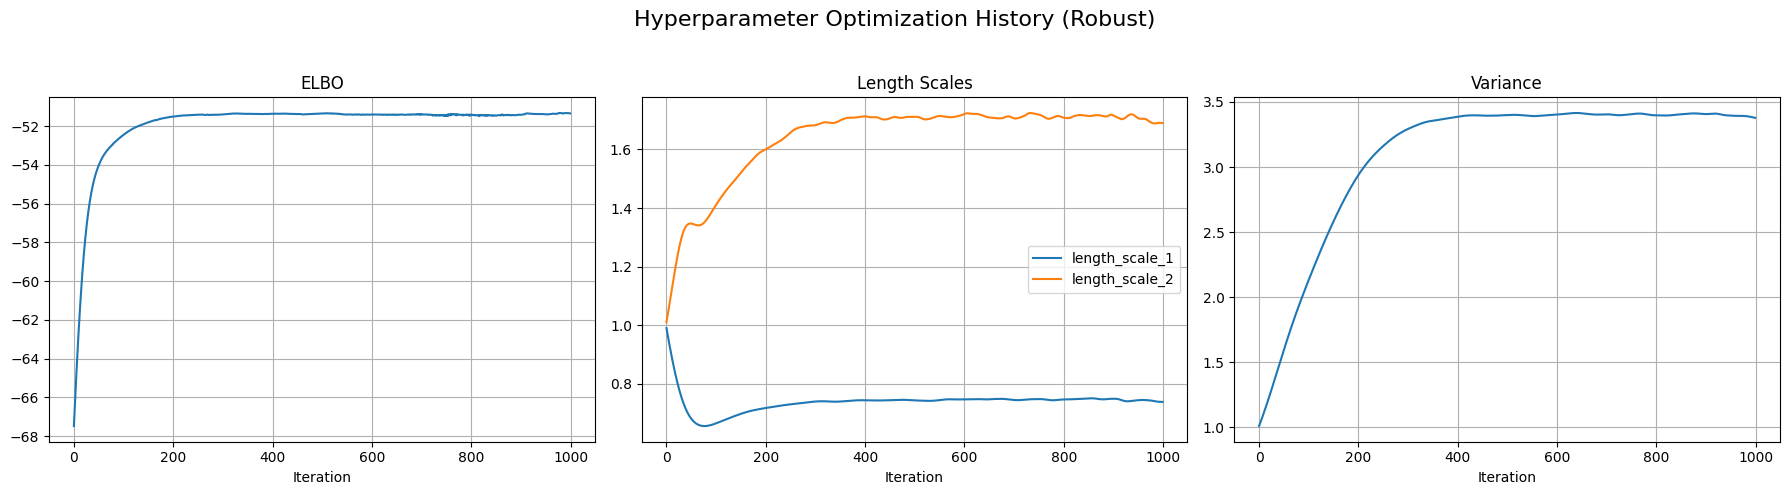

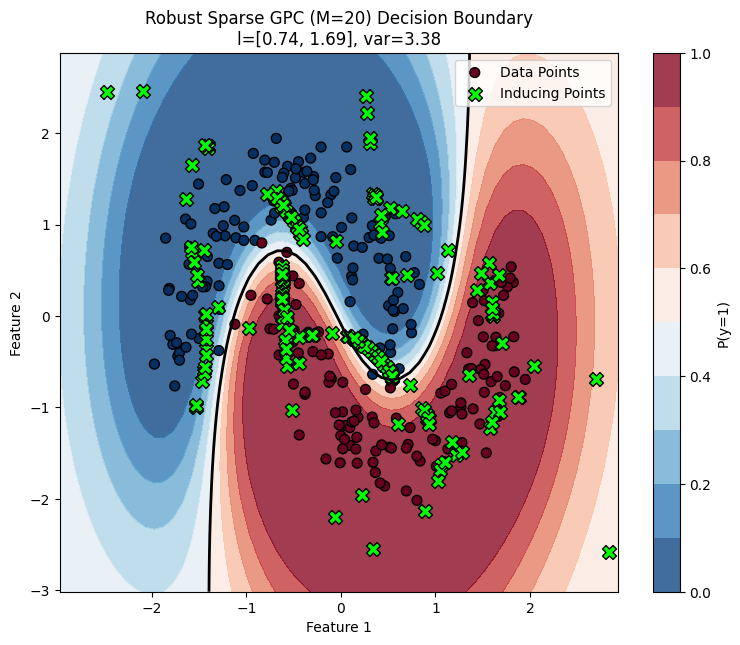

In [36]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.distributions import Normal, Gamma
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import math

# --- MODIFICATION: Import linear-operator for stability ---
from linear_operator.operators import to_linear_operator, AddedDiagLinearOperator, DiagLinearOperator

# --- PyTorch Setup ---
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
print(f"Using device: {device}")

# --- Helper Functions (Unchanged) ---
def get_truncnorm_moments(y, mu, sigma_sq):
    sigma = torch.sqrt(sigma_sq)
    alpha = y * mu / sigma
    std_normal = Normal(torch.tensor([0.0], device=device), torch.tensor([1.0], device=device))
    pdf_alpha = torch.exp(std_normal.log_prob(alpha))
    cdf_alpha = std_normal.cdf(alpha).clamp(min=1e-12)
    ratio = pdf_alpha / cdf_alpha
    exp_z = mu + y * sigma * ratio
    var_z = sigma_sq * (1 - ratio * (alpha + ratio))
    exp_z_sq = var_z + exp_z**2
    return exp_z, exp_z_sq

def get_truncnorm_entropy(y, mu, sigma_sq):
    sigma = torch.sqrt(sigma_sq)
    alpha = y * mu / sigma
    std_normal = Normal(torch.tensor([0.0], device=device), torch.tensor([1.0], device=device))
    pdf_alpha = torch.exp(std_normal.log_prob(alpha))
    cdf_alpha = std_normal.cdf(alpha).clamp(min=1e-12)
    H = torch.log(torch.sqrt(2 * torch.pi * torch.e * sigma_sq) * cdf_alpha) - \
        alpha * pdf_alpha / (2 * cdf_alpha)
    return H.sum()

# --- MODIFICATION: Add a simple Prior class ---
class GammaPrior(nn.Module):
    def __init__(self, concentration, rate):
        super().__init__()
        self.concentration = torch.tensor(concentration, device=device)
        self.rate = torch.tensor(rate, device=device)
        # Use PyTorch's distribution object for stable log_prob
        self.dist = Gamma(self.concentration, self.rate)

    def log_prob(self, x):
        return self.dist.log_prob(x).sum()

# --- Refactored Sparse GPC_VI Model ---
class Sparse_GPC_VI_PyTorch(nn.Module):
    def __init__(self, n_inducing_points, n_cavi_iters=15, cavi_tol=1e-5, initial_length_scale=1.0, initial_variance=1.0):
        super().__init__()
        self.M = n_inducing_points
        self.n_cavi_iters = n_cavi_iters
        self.cavi_tol = cavi_tol
        self.X_train_, self.y_train_ = None, None
        self.variational_params_ = None

        self.log_length_scale = None
        self.initial_length_scale = initial_length_scale
        self.log_variance = nn.Parameter(torch.log(torch.tensor(initial_variance, device=device)))
        self.inducing_points = None

        # --- MODIFICATION: Instantiate priors for regularization ---
        self.lengthscale_prior = GammaPrior(2.0, 1.0) # Encourages lengthscales around 2.0
        self.variance_prior = GammaPrior(2.0, 1.0)    # Encourages variance around 2.0

    def _compute_rbf_kernel(self, X1, X2, length_scale, variance):
        X1_scaled = X1 / length_scale
        X2_scaled = X2 / length_scale
        sqdist = torch.sum(X1_scaled**2, 1).reshape(-1, 1) + torch.sum(X2_scaled**2, 1) - 2 * (X1_scaled @ X2_scaled.T)
        sqdist = torch.clamp(sqdist, min=0.0)
        return variance * torch.exp(-0.5 * sqdist)

    def _get_hyperparams(self):
        return {
            'length_scale': torch.exp(self.log_length_scale),
            'variance': torch.exp(self.log_variance)
        }

    def _compute_kernels_and_operators(self, X, hp):
        """Helper to compute kernels and stable linear operators."""
        K_xz = self._compute_rbf_kernel(X, self.inducing_points, hp['length_scale'], hp['variance'])
        K_zz_raw = self._compute_rbf_kernel(self.inducing_points, self.inducing_points, hp['length_scale'], hp['variance'])
        
        # Use AddedDiagLinearOperator for stable jitter
        K_zz_op = to_linear_operator(K_zz_raw).add_jitter(1e-6)
        return K_xz, K_zz_op

    def _sparse_gpc_cavi_fit_torch(self, K_xz, K_zz_op):
        with torch.no_grad():
            m_u = torch.zeros(self.M, device=device)
            # S_u initialized to prior, using the dense representation from the operator
            S_u = K_zz_op.to_dense()

            for i in range(self.n_cavi_iters):
                m_u_old = m_u.clone()
                
                # E[f] = K_XZ @ K_ZZ^{-1} @ m_u
                mu_f = K_xz @ K_zz_op.solve(m_u.unsqueeze(1)).squeeze()
                E_z, _ = get_truncnorm_moments(self.y_train_, mu_f, torch.ones_like(mu_f))

                # Update q(u)
                K_zx_K_xz = K_xz.T @ K_xz
                # Precision matrix P = K_zz^{-1} + K_zz^{-1} @ K_zx_K_xz @ K_zz^{-1}
                precision_term = K_zz_op.solve(K_zx_K_xz @ K_zz_op.solve(torch.eye(self.M, device=device)))
                P = K_zz_op.solve(torch.eye(self.M, device=device)) + precision_term
                S_u = torch.linalg.inv(P)
                
                # m_u = S_u @ K_zz^{-1} @ K_zx @ E[z]
                m_u = S_u @ K_zz_op.solve(K_xz.T @ E_z.unsqueeze(1)).squeeze()

                if torch.norm(m_u - m_u_old) < self.cavi_tol:
                    print(f"ca converged at step {i+1}")
                    break
            
            mu_f_final = K_xz @ K_zz_op.solve(m_u.unsqueeze(1)).squeeze()
            E_z_final, E_z_sq_final = get_truncnorm_moments(self.y_train_, mu_f_final, torch.ones_like(mu_f_final))

            return {"m_u": m_u, "S_u": S_u, "E_z": E_z_final, "E_z_sq": E_z_sq_final}

    def _sparse_gpc_elbo_torch(self, variational_params, K_xz, K_zz_op):
        N, D = self.X_train_.shape
        m_u, S_u = variational_params["m_u"], variational_params["S_u"]
        E_z, E_z_sq = variational_params["E_z"], variational_params["E_z_sq"]
        hp = self._get_hyperparams()

        # Expected Log-Likelihood
        A = K_xz @ K_zz_op.solve(torch.eye(self.M, device=device))
        mu_f = A @ m_u
        var_f = hp['variance'] - torch.einsum('ij,ji->i', A, K_xz.T) + torch.einsum('ij,jk,ki->i', A, S_u, A.T)
        E_f_sq = var_f + mu_f**2
        E_f_minus_z_sq = E_z_sq - 2 * E_z * mu_f + E_f_sq
        exp_log_lik = torch.sum(-0.5 * math.log(2 * math.pi) - 0.5 * E_f_minus_z_sq)

        # KL Divergence KL(q(u) || p(u))
        logdet_K_zz = K_zz_op.logdet()
        logdet_S_u = torch.linalg.slogdet(S_u).logabsdet
        trace_term = torch.trace(K_zz_op.solve(S_u))
        m_T_Kinv_m = m_u.T @ K_zz_op.solve(m_u.unsqueeze(1))
        kl_u = 0.5 * (trace_term + m_T_Kinv_m - self.M - logdet_S_u + logdet_K_zz)

        # Entropy H(q(z))
        H_q_z = get_truncnorm_entropy(self.y_train_, mu_f, torch.ones_like(mu_f))
        
        # --- MODIFICATION: Add log prior term for regularization ---
        log_prior_term = self.lengthscale_prior.log_prob(hp['length_scale']) + \
                         self.variance_prior.log_prob(hp['variance'])

        elbo = exp_log_lik - kl_u.squeeze() + H_q_z + log_prior_term
        return -elbo

    def fit(self, X, y, n_hyper_iters=150, learning_rate=0.01):
        self.X_train_ = torch.tensor(X, device=device, dtype=torch.get_default_dtype())
        self.y_train_ = torch.tensor(2 * y - 1, device=device, dtype=torch.get_default_dtype())
        N, D = self.X_train_.shape

        if self.log_length_scale is None:
            initial_ls = torch.full((D,), self.initial_length_scale, device=device)
            self.log_length_scale = nn.Parameter(torch.log(initial_ls))

        if self.inducing_points is None:
            kmeans = KMeans(n_clusters=self.M, random_state=42, n_init=10).fit(self.X_train_.cpu().numpy())
            Z_init = torch.tensor(kmeans.cluster_centers_, device=device, dtype=torch.get_default_dtype())
            self.inducing_points = nn.Parameter(Z_init)

        optimizer = optim.Adam(self.parameters(), lr=learning_rate)
        history = {'elbo': [], 'length_scale': [], 'variance': []}
        
        print(f"Starting Robust Sparse GPC model optimization (M={self.M})...")
        for i in range(n_hyper_iters):
            optimizer.zero_grad()
            hp = self._get_hyperparams()

            K_xz, K_zz_op = self._compute_kernels_and_operators(self.X_train_, hp)
            variational_params = self._sparse_gpc_cavi_fit_torch(K_xz, K_zz_op)
            loss = self._sparse_gpc_elbo_torch(variational_params, K_xz, K_zz_op)
            
            loss.backward()
            optimizer.step()

            current_hp = self._get_hyperparams()
            history['elbo'].append(-loss.item())
            history['length_scale'].append(current_hp['length_scale'].detach().cpu().numpy())
            history['variance'].append(current_hp['variance'].item())

            if (i+1) % 15 == 0:
                ls_str = ", ".join([f"{l:.3f}" for l in current_hp['length_scale']])
                print(f"Iter {i+1:3d}/{n_hyper_iters} | ELBO: {-loss.item():8.2f} | "
                      f"l: [{ls_str}] | var: {current_hp['variance']:.3f}")
        
        hp = self._get_hyperparams()
        K_xz_final, K_zz_op_final = self._compute_kernels_and_operators(self.X_train_, hp)
        self.variational_params_ = self._sparse_gpc_cavi_fit_torch(K_xz_final, K_zz_op_final)
        # Store final operators for prediction
        self.variational_params_['K_zz_op'] = K_zz_op_final
        print("Training complete.")
        return history

    def predict_proba(self, X_test):
        with torch.no_grad():
            if self.variational_params_ is None:
                raise RuntimeError("Model has not been trained yet. Call fit() first.")

            X_test_t = torch.tensor(X_test, device=device, dtype=torch.get_default_dtype())
            hp = self._get_hyperparams()
            m_u, S_u = self.variational_params_["m_u"], self.variational_params_["S_u"]
            K_zz_op = self.variational_params_['K_zz_op']
            
            k_star_z, _ = self._compute_kernels_and_operators(X_test_t, hp)
            k_star_star = hp['variance']
            
            # Predictive mean: μ_* = k_{*,Z} K_ZZ⁻¹ m_u
            mu_star = k_star_z @ K_zz_op.solve(m_u.unsqueeze(1)).squeeze()
            
            # Predictive variance
            A_star = k_star_z @ K_zz_op.solve(torch.eye(self.M, device=device))
            var_star_term1 = k_star_star - torch.einsum('ij,ji->i', A_star, k_star_z.T)
            var_star_term2 = torch.einsum('ij,jk,ki->i', A_star, S_u, A_star.T)
            var_f_star = var_star_term1 + var_star_term2
            var_f_star = torch.clamp(var_f_star, min=1e-9)

            prob = Normal(0, 1).cdf(mu_star / torch.sqrt(1 + var_f_star))
            return prob.cpu().numpy()

# --- Main execution block ---
if __name__ == '__main__':
    # (Plotting and data generation functions remain the same as before)
    def plot_decision_boundary_sparse(model, X, y, ax, title):
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        Z = model.predict_proba(grid_points)
        Z = Z.reshape(xx.shape)
        cs = ax.contourf(xx, yy, Z, cmap=plt.cm.RdBu_r, alpha=0.8, levels=np.linspace(0, 1, 11))
        plt.colorbar(cs, ax=ax, label="P(y=1)")
        ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu_r, edgecolors='k', s=50, label="Data Points")
        inducing_points = model.inducing_points.detach().cpu().numpy()
        ax.scatter(inducing_points[:, 0], inducing_points[:, 1], c='lime', edgecolors='k', s=100, marker='X', label='Inducing Points')
        ax.set_title(title); ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2"); ax.legend()

    def plot_history(history):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle("Hyperparameter Optimization History (Robust)", fontsize=16)
        axes[0].plot(history['elbo']); axes[0].set_title('ELBO')
        ls_history = np.array(history['length_scale'])
        for d in range(ls_history.shape[1]):
            axes[1].plot(ls_history[:, d], label=f'length_scale_{d+1}')
        axes[1].set_title('Length Scales'); axes[1].legend();
        axes[2].plot(history['variance']); axes[2].set_title('Variance')
        for ax in axes: ax.set_xlabel('Iteration'); ax.grid(True)
        fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

    np.random.seed(42)
    X, y_true = make_moons(n_samples=250, noise=0.15, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --- Model Training ---
    sparse_gpc = Sparse_GPC_VI_PyTorch(n_inducing_points=200, n_cavi_iters=20, cavi_tol=1e-5)
    history = sparse_gpc.fit(X_scaled, y_true, n_hyper_iters=1000, learning_rate=0.01)
    
    # --- Plotting Results ---
    plot_history(history)
    fig, ax = plt.subplots(1, 1, figsize=(9, 7))
    hp = sparse_gpc._get_hyperparams()
    ls_vals = hp["length_scale"].detach().cpu().numpy()
    ls_str = ", ".join([f"{l:.2f}" for l in ls_vals])
    title = (f'Robust Sparse GPC (M=20) Decision Boundary\n' f'l=[{ls_str}], var={hp["variance"]:.2f}')
    plot_decision_boundary_sparse(sparse_gpc, X_scaled, y_true, ax, title)
    plt.show()

Using device: cuda
Starting SVI with Natural Gradients (M=25)...
Epoch  10/2000 | ELBO:  -124.37 | l: [0.941, 0.942] | var: 1.062
Epoch  20/2000 | ELBO:  -112.98 | l: [0.937, 0.941] | var: 1.064
Epoch  30/2000 | ELBO:  -111.23 | l: [0.933, 0.942] | var: 1.067
Epoch  40/2000 | ELBO:  -110.50 | l: [0.929, 0.943] | var: 1.072
Epoch  50/2000 | ELBO:  -111.68 | l: [0.924, 0.944] | var: 1.077
Epoch  60/2000 | ELBO:  -105.89 | l: [0.919, 0.945] | var: 1.083
Epoch  70/2000 | ELBO:  -109.06 | l: [0.914, 0.946] | var: 1.089
Epoch  80/2000 | ELBO:   -92.42 | l: [0.908, 0.947] | var: 1.097
Epoch  90/2000 | ELBO:  -111.39 | l: [0.901, 0.949] | var: 1.106
Epoch 100/2000 | ELBO:  -108.74 | l: [0.892, 0.950] | var: 1.118
Epoch 110/2000 | ELBO:  -103.68 | l: [0.882, 0.952] | var: 1.131
Epoch 120/2000 | ELBO:   -97.98 | l: [0.871, 0.955] | var: 1.147
Epoch 130/2000 | ELBO:  -111.88 | l: [0.860, 0.956] | var: 1.164
Epoch 140/2000 | ELBO:  -101.09 | l: [0.849, 0.958] | var: 1.180
Epoch 150/2000 | ELBO:  -

Epoch 350/2000 | ELBO:   -92.91 | l: [0.705, 1.058] | var: 1.573
Epoch 360/2000 | ELBO:  -100.28 | l: [0.704, 1.064] | var: 1.592
Epoch 370/2000 | ELBO:   -84.25 | l: [0.706, 1.073] | var: 1.608
Epoch 380/2000 | ELBO:   -92.63 | l: [0.708, 1.082] | var: 1.626
Epoch 390/2000 | ELBO:   -87.08 | l: [0.707, 1.090] | var: 1.647
Epoch 400/2000 | ELBO:   -92.75 | l: [0.707, 1.098] | var: 1.669
Epoch 410/2000 | ELBO:   -86.62 | l: [0.706, 1.106] | var: 1.691
Epoch 420/2000 | ELBO:   -81.17 | l: [0.706, 1.113] | var: 1.714
Epoch 430/2000 | ELBO:   -79.54 | l: [0.705, 1.120] | var: 1.739
Epoch 440/2000 | ELBO:   -83.45 | l: [0.705, 1.127] | var: 1.765
Epoch 450/2000 | ELBO:   -85.86 | l: [0.704, 1.134] | var: 1.790
Epoch 460/2000 | ELBO:   -90.86 | l: [0.704, 1.141] | var: 1.816
Epoch 470/2000 | ELBO:   -87.67 | l: [0.704, 1.148] | var: 1.841
Epoch 480/2000 | ELBO:   -80.00 | l: [0.703, 1.155] | var: 1.865
Epoch 490/2000 | ELBO:   -87.04 | l: [0.703, 1.162] | var: 1.887
Epoch 500/2000 | ELBO:   

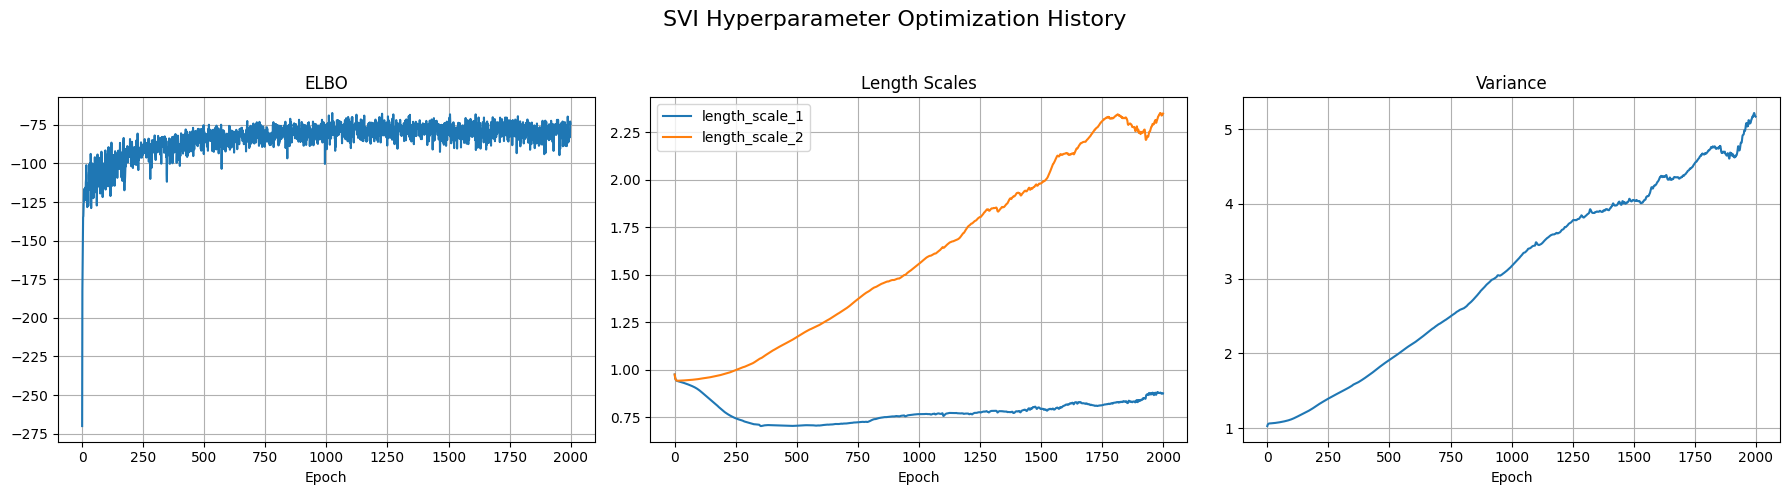

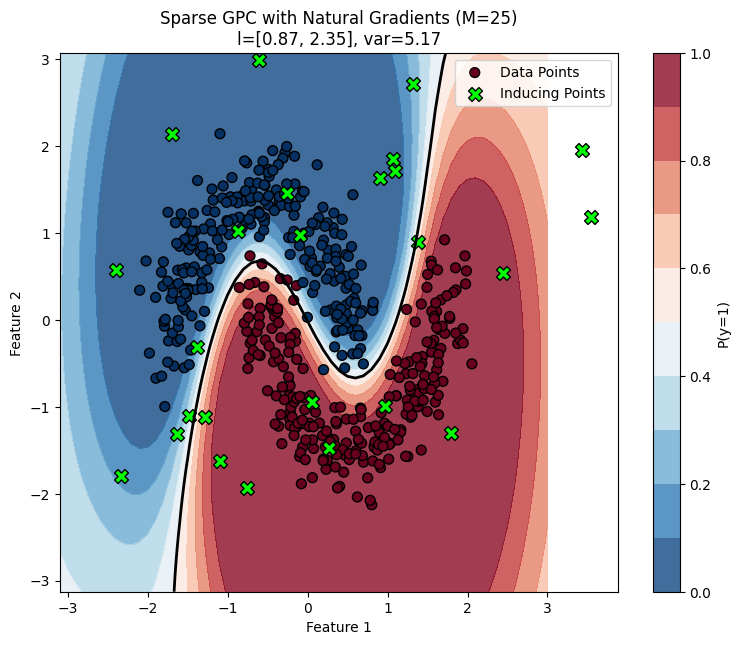

In [40]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.distributions import Normal, Gamma
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import math
from torch.utils.data import TensorDataset, DataLoader

# Import linear-operator for stability
from linear_operator.operators import to_linear_operator

# --- PyTorch Setup ---
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# --- Helper Functions (Unchanged) ---
def get_truncnorm_moments(y, mu, sigma_sq):
    sigma = torch.sqrt(sigma_sq)
    alpha = y * mu / sigma
    std_normal = Normal(torch.tensor([0.0], device=device), torch.tensor([1.0], device=device))
    pdf_alpha = torch.exp(std_normal.log_prob(alpha))
    cdf_alpha = std_normal.cdf(alpha).clamp(min=1e-12)
    ratio = pdf_alpha / cdf_alpha
    exp_z = mu + y * sigma * ratio
    var_z = sigma_sq * (1 - ratio * (alpha + ratio))
    exp_z_sq = var_z + exp_z**2
    return exp_z, exp_z_sq

def get_truncnorm_entropy(y, mu, sigma_sq):
    sigma = torch.sqrt(sigma_sq)
    alpha = y * mu / sigma
    std_normal = Normal(torch.tensor([0.0], device=device), torch.tensor([1.0], device=device))
    pdf_alpha = torch.exp(std_normal.log_prob(alpha))
    cdf_alpha = std_normal.cdf(alpha).clamp(min=1e-12)
    H = torch.log(torch.sqrt(2 * torch.pi * torch.e * sigma_sq) * cdf_alpha) - \
        alpha * pdf_alpha / (2 * cdf_alpha)
    return H.sum()

class GammaPrior(nn.Module):
    def __init__(self, concentration, rate):
        super().__init__()
        self.concentration = torch.tensor(concentration, device=device)
        self.rate = torch.tensor(rate, device=device)
        self.dist = Gamma(self.concentration, self.rate)

    def log_prob(self, x):
        return self.dist.log_prob(x).sum()

# --- Sparse GPC Model with Natural Gradient SVI ---
class Sparse_GPC_NG_PyTorch(nn.Module):
    def __init__(self, n_inducing_points, initial_length_scale=1.0, initial_variance=1.0):
        super().__init__()
        self.M = n_inducing_points
        self.X_train_, self.y_train_ = None, None
        
        self.log_length_scale = None
        self.initial_length_scale = initial_length_scale
        self.log_variance = nn.Parameter(torch.log(torch.tensor(initial_variance, device=device)))
        self.inducing_points = None

        self.lengthscale_prior = GammaPrior(1.0, 1.0)
        self.variance_prior = GammaPrior(1.0, 1.0)

        # Register variational parameters as persistent buffers
        self.register_buffer('m_u', torch.zeros(self.M, device=device))
        self.register_buffer('S_u', torch.eye(self.M, device=device))

    def _compute_rbf_kernel(self, X1, X2, length_scale, variance):
        X1_scaled = X1 / length_scale
        X2_scaled = X2 / length_scale
        sqdist = torch.sum(X1_scaled**2, 1).reshape(-1, 1) + torch.sum(X2_scaled**2, 1) - 2 * (X1_scaled @ X2_scaled.T)
        sqdist = torch.clamp(sqdist, min=0.0)
        return variance * torch.exp(-0.5 * sqdist)

    def _get_hyperparams(self):
        return {'length_scale': torch.exp(self.log_length_scale), 'variance': torch.exp(self.log_variance)}

    def _compute_kernels_and_operators(self, X, hp):
        K_xz = self._compute_rbf_kernel(X, self.inducing_points, hp['length_scale'], hp['variance'])
        K_zz_raw = self._compute_rbf_kernel(self.inducing_points, self.inducing_points, hp['length_scale'], hp['variance'])
        K_zz_op = to_linear_operator(K_zz_raw).add_jitter(1e-6)
        return K_xz, K_zz_op

    def _elbo(self, X_batch, y_batch, K_xz, K_zz_op):
        N = self.X_train_.shape[0]
        batch_size = X_batch.shape[0]
        hp = self._get_hyperparams()

        # Moments of f for the batch
        A = K_xz @ K_zz_op.solve(torch.eye(self.M, device=device))
        mu_f_batch = A @ self.m_u
        var_f_batch = hp['variance'] - torch.einsum('ij,ji->i', A, K_xz.T) + torch.einsum('ij,jk,ki->i', A, self.S_u, A.T)
        
        # Moments of z
        E_z_batch, E_z_sq_batch = get_truncnorm_moments(y_batch, mu_f_batch, torch.ones_like(mu_f_batch))
        
        # Expected Log-Likelihood (scaled)
        E_f_sq_batch = var_f_batch + mu_f_batch**2
        E_f_minus_z_sq = E_z_sq_batch - 2 * E_z_batch * mu_f_batch + E_f_sq_batch
        exp_log_lik = torch.sum(-0.5 * math.log(2 * math.pi) - 0.5 * E_f_minus_z_sq) * (N / batch_size)

        # Entropy H(q(z)) (scaled)
        H_q_z = get_truncnorm_entropy(y_batch, mu_f_batch, torch.ones_like(mu_f_batch)) * (N / batch_size)

        # KL Divergence KL(q(u) || p(u)) (global term, not scaled)
        logdet_K_zz = K_zz_op.logdet()
        logdet_S_u = torch.linalg.slogdet(self.S_u).logabsdet
        trace_term = torch.trace(K_zz_op.solve(self.S_u))
        m_T_Kinv_m = self.m_u.T @ K_zz_op.solve(self.m_u.unsqueeze(1))
        kl_u = 0.5 * (trace_term + m_T_Kinv_m - self.M - logdet_S_u + logdet_K_zz)

        # Log Prior
        log_prior_term = self.lengthscale_prior.log_prob(hp['length_scale']) + self.variance_prior.log_prob(hp['variance'])
        
        elbo = exp_log_lik - kl_u.squeeze() + H_q_z + log_prior_term
        return elbo

    def fit_svi(self, X, y, n_epochs=100, batch_size=128, hyper_lr=0.01, var_lr=0.1):
        self.X_train_ = torch.tensor(X, device=device, dtype=torch.get_default_dtype())
        self.y_train_ = torch.tensor(2 * y - 1, device=device, dtype=torch.get_default_dtype())
        N, D = self.X_train_.shape

        if self.log_length_scale is None:
            initial_ls = torch.full((D,), self.initial_length_scale, device=device)
            self.log_length_scale = nn.Parameter(torch.log(initial_ls))
        if self.inducing_points is None:
            kmeans = KMeans(n_clusters=self.M, random_state=42, n_init=10).fit(X.copy())
            self.inducing_points = nn.Parameter(torch.tensor(kmeans.cluster_centers_, device=device))

        # Re-initialize variational parameters at the start of training
        self.m_u.data.zero_()
        self.S_u.data = torch.eye(self.M, device=device)
        
        hyper_optimizer = optim.Adam(self.parameters(), lr=hyper_lr)
        dataset = TensorDataset(self.X_train_, self.y_train_)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        history = {'elbo': [], 'length_scale': [], 'variance': []}
        print(f"Starting SVI with Natural Gradients (M={self.M})...")

        for epoch in range(n_epochs):
            for X_batch, y_batch in dataloader:
                # --- M-Step: Update Hyperparameters ---
                hyper_optimizer.zero_grad()
                hp = self._get_hyperparams()
                K_xz, K_zz_op = self._compute_kernels_and_operators(X_batch, hp)
                loss = -self._elbo(X_batch, y_batch.squeeze(), K_xz, K_zz_op)
                loss.backward()
                hyper_optimizer.step()

                # --- E-Step: Update Variational Parameters via Natural Gradients ---
                with torch.no_grad():
                    hp_updated = self._get_hyperparams()
                    K_xz_updated, K_zz_op_updated = self._compute_kernels_and_operators(X_batch, hp_updated)
                    
                    # 1. Calculate target optimal parameters (m_u*, S_u*) for the batch
                    A_batch = K_xz_updated @ K_zz_op_updated.solve(torch.eye(self.M, device=device))
                    mu_f_batch = A_batch @ self.m_u
                    E_z_batch, _ = get_truncnorm_moments(y_batch.squeeze(), mu_f_batch, torch.ones_like(mu_f_batch))

                    S_u_star_inv = K_zz_op_updated.solve(torch.eye(self.M, device=device)) + \
                                   A_batch.T @ A_batch
                    m_u_star = torch.linalg.solve(S_u_star_inv, A_batch.T @ E_z_batch.unsqueeze(1)).squeeze()
                    
                    # 2. Convert current and target to natural parameters
                    S_u_inv = torch.linalg.inv(self.S_u)
                    eta1_current = S_u_inv @ self.m_u
                    eta2_current = -0.5 * S_u_inv

                    eta1_star = S_u_star_inv @ m_u_star
                    eta2_star = -0.5 * S_u_star_inv
                    
                    # 3. Perform natural gradient update (Polyak-Ruppert averaging)
                    eta1_new = (1 - var_lr) * eta1_current + var_lr * eta1_star
                    eta2_new = (1 - var_lr) * eta2_current + var_lr * eta2_star
                    
                    # 4. Convert back to standard parameters and update state
                    S_u_new = torch.linalg.inv(-2 * eta2_new)
                    m_u_new = S_u_new @ eta1_new
                    self.S_u.data = S_u_new
                    self.m_u.data = m_u_new

            # Logging at the end of epoch
            history['elbo'].append(-loss.item())
            history['length_scale'].append(hp_updated['length_scale'].detach().cpu().numpy())
            history['variance'].append(hp_updated['variance'].item())
            if (epoch + 1) % 10 == 0:
                ls_str = ", ".join([f"{l:.3f}" for l in hp_updated['length_scale']])
                print(f"Epoch {epoch+1:3d}/{n_epochs} | ELBO: {-loss.item():8.2f} | l: [{ls_str}] | var: {hp_updated['variance']:.3f}")

        # Store final parameters for prediction
        hp_final = self._get_hyperparams()
        _, K_zz_op_final = self._compute_kernels_and_operators(self.X_train_, hp_final)
        self.variational_params_ = {'K_zz_op': K_zz_op_final}
        print("Training complete.")
        return history
    
    def predict_proba(self, X_test):
        # (This method remains the same as the previous robust version)
        with torch.no_grad():
            if self.variational_params_ is None:
                raise RuntimeError("Model has not been trained yet. Call fit() first.")

            X_test_t = torch.tensor(X_test, device=device, dtype=torch.get_default_dtype())
            hp = self._get_hyperparams()
            K_zz_op = self.variational_params_['K_zz_op']
            
            k_star_z, _ = self._compute_kernels_and_operators(X_test_t, hp)
            k_star_star = hp['variance']
            
            mu_star = k_star_z @ K_zz_op.solve(self.m_u.unsqueeze(1)).squeeze()
            
            A_star = k_star_z @ K_zz_op.solve(torch.eye(self.M, device=device))
            var_star_term1 = k_star_star - torch.einsum('ij,ji->i', A_star, k_star_z.T)
            var_star_term2 = torch.einsum('ij,jk,ki->i', A_star, self.S_u, A_star.T)
            var_f_star = var_star_term1 + var_star_term2
            var_f_star = torch.clamp(var_f_star, min=1e-9)

            prob = Normal(0, 1).cdf(mu_star / torch.sqrt(1 + var_f_star))
            return prob.cpu().numpy()

# --- Main execution block ---
if __name__ == '__main__':
    def plot_decision_boundary_sparse(model, X, y, ax, title):
        x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
        y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        Z = model.predict_proba(grid_points)
        Z = Z.reshape(xx.shape)
        cs = ax.contourf(xx, yy, Z, cmap=plt.cm.RdBu_r, alpha=0.8, levels=np.linspace(0, 1, 11))
        plt.colorbar(cs, ax=ax, label="P(y=1)")
        ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu_r, edgecolors='k', s=50, label="Data Points")
        inducing_points = model.inducing_points.detach().cpu().numpy()
        ax.scatter(inducing_points[:, 0], inducing_points[:, 1], c='lime', edgecolors='k', s=100, marker='X', label='Inducing Points')
        ax.set_title(title); ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2"); ax.legend()

    def plot_history(history):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle("SVI Hyperparameter Optimization History", fontsize=16)
        axes[0].plot(history['elbo']); axes[0].set_title('ELBO')
        ls_history = np.array(history['length_scale'])
        for d in range(ls_history.shape[1]):
            axes[1].plot(ls_history[:, d], label=f'length_scale_{d+1}')
        axes[1].set_title('Length Scales'); axes[1].legend();
        axes[2].plot(history['variance']); axes[2].set_title('Variance')
        for ax in axes: ax.set_xlabel('Epoch'); ax.grid(True)
        fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()
    
    np.random.seed(42)
    X, y_true = make_moons(n_samples=500, noise=0.15, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --- Model Training ---
    sparse_gpc_ng = Sparse_GPC_NG_PyTorch(n_inducing_points=25)
    history = sparse_gpc_ng.fit_svi(X_scaled, y_true, n_epochs=2000, batch_size=128, hyper_lr=0.01, var_lr=0.1)
    
    # --- Plotting Results ---
    plot_history(history)
    fig, ax = plt.subplots(1, 1, figsize=(9, 7))
    hp = sparse_gpc_ng._get_hyperparams()
    ls_vals = hp["length_scale"].detach().cpu().numpy()
    ls_str = ", ".join([f"{l:.2f}" for l in ls_vals])
    title = (f'Sparse GPC with Natural Gradients (M=25)\n' f'l=[{ls_str}], var={hp["variance"]:.2f}')
    plot_decision_boundary_sparse(sparse_gpc_ng, X_scaled, y_true, ax, title)
    plt.show()

Using device: cuda

--- Kernel Density Estimation ---
KDE model trained on the input data.
Starting SVI with Natural Gradients (M=25)...
Using KDE prior for inducing points with strength=1
Epoch  10/2000 | ELBO:  -115.17 | l: [0.941, 0.942] | var: 1.062
Epoch  20/2000 | ELBO:  -109.91 | l: [0.937, 0.941] | var: 1.064
Epoch  30/2000 | ELBO:  -119.98 | l: [0.933, 0.942] | var: 1.067


Epoch  40/2000 | ELBO:  -109.82 | l: [0.929, 0.943] | var: 1.072
Epoch  50/2000 | ELBO:  -101.65 | l: [0.924, 0.944] | var: 1.077
Epoch  60/2000 | ELBO:  -108.66 | l: [0.919, 0.945] | var: 1.083
Epoch  70/2000 | ELBO:  -125.44 | l: [0.914, 0.947] | var: 1.090
Epoch  80/2000 | ELBO:  -102.27 | l: [0.908, 0.948] | var: 1.098
Epoch  90/2000 | ELBO:  -113.72 | l: [0.901, 0.950] | var: 1.107
Epoch 100/2000 | ELBO:  -101.35 | l: [0.892, 0.952] | var: 1.119
Epoch 110/2000 | ELBO:   -92.27 | l: [0.883, 0.954] | var: 1.132
Epoch 120/2000 | ELBO:  -117.89 | l: [0.873, 0.957] | var: 1.146
Epoch 130/2000 | ELBO:  -103.90 | l: [0.865, 0.959] | var: 1.160
Epoch 140/2000 | ELBO:  -101.22 | l: [0.856, 0.961] | var: 1.174
Epoch 150/2000 | ELBO:   -91.15 | l: [0.845, 0.963] | var: 1.189
Epoch 160/2000 | ELBO:   -97.74 | l: [0.830, 0.963] | var: 1.209
Epoch 170/2000 | ELBO:   -93.48 | l: [0.815, 0.964] | var: 1.229
Epoch 180/2000 | ELBO:   -90.14 | l: [0.800, 0.965] | var: 1.249
Epoch 190/2000 | ELBO:   

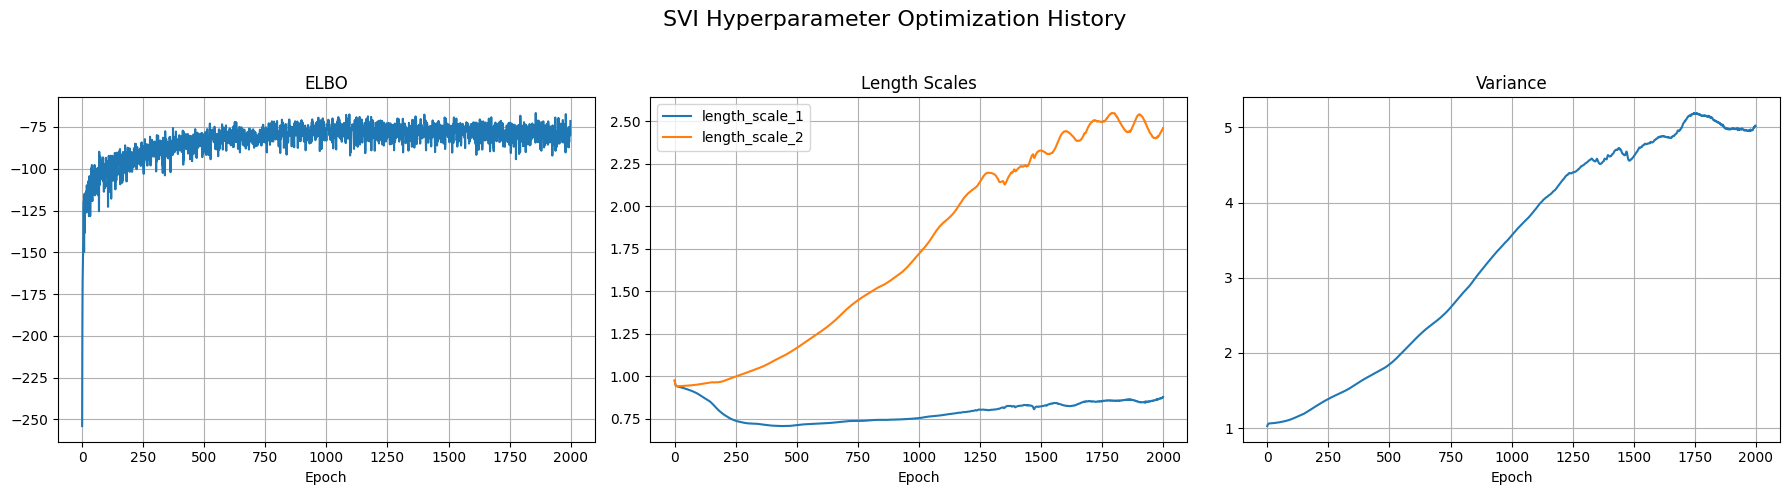

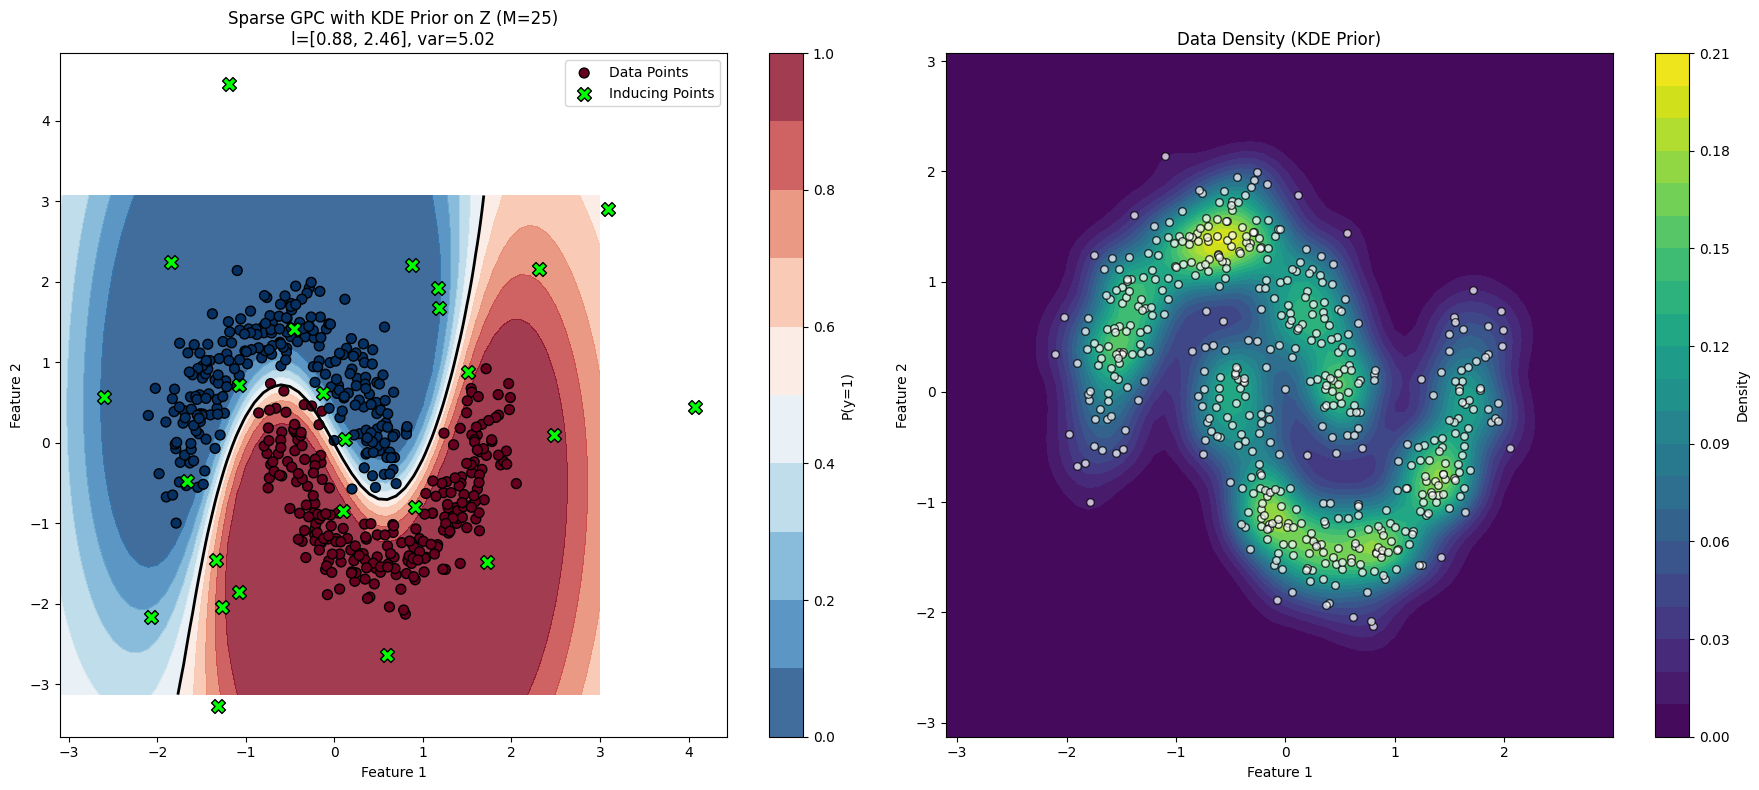

In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.distributions import Normal, Gamma
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import math
from torch.utils.data import TensorDataset, DataLoader

# Import linear-operator for stability
from linear_operator.operators import to_linear_operator

# Import KernelDensity
from sklearn.neighbors import KernelDensity

# --- PyTorch Setup ---
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# --- Helper Functions (Unchanged) ---
def get_truncnorm_moments(y, mu, sigma_sq):
    sigma = torch.sqrt(sigma_sq)
    alpha = y * mu / sigma
    std_normal = Normal(torch.tensor([0.0], device=device), torch.tensor([1.0], device=device))
    pdf_alpha = torch.exp(std_normal.log_prob(alpha))
    cdf_alpha = std_normal.cdf(alpha).clamp(min=1e-12)
    ratio = pdf_alpha / cdf_alpha
    exp_z = mu + y * sigma * ratio
    var_z = sigma_sq * (1 - ratio * (alpha + ratio))
    exp_z_sq = var_z + exp_z**2
    return exp_z, exp_z_sq

def get_truncnorm_entropy(y, mu, sigma_sq):
    sigma = torch.sqrt(sigma_sq)
    alpha = y * mu / sigma
    std_normal = Normal(torch.tensor([0.0], device=device), torch.tensor([1.0], device=device))
    pdf_alpha = torch.exp(std_normal.log_prob(alpha))
    cdf_alpha = std_normal.cdf(alpha).clamp(min=1e-12)
    H = torch.log(torch.sqrt(2 * torch.pi * torch.e * sigma_sq) * cdf_alpha) - \
        alpha * pdf_alpha / (2 * cdf_alpha)
    return H.sum()

class GammaPrior(nn.Module):
    def __init__(self, concentration, rate):
        super().__init__()
        self.concentration = torch.tensor(concentration, device=device)
        self.rate = torch.tensor(rate, device=device)
        self.dist = Gamma(self.concentration, self.rate)

    def log_prob(self, x):
        return self.dist.log_prob(x).sum()

# --- Sparse GPC Model with Natural Gradient SVI ---
class Sparse_GPC_NG_PyTorch(nn.Module):
    def __init__(self, n_inducing_points, initial_length_scale=1.0, initial_variance=1.0):
        super().__init__()
        self.M = n_inducing_points
        self.X_train_, self.y_train_ = None, None
        
        self.log_length_scale = None
        self.initial_length_scale = initial_length_scale
        self.log_variance = nn.Parameter(torch.log(torch.tensor(initial_variance, device=device)))
        self.inducing_points = None

        self.lengthscale_prior = GammaPrior(1.0, 1.0)
        self.variance_prior = GammaPrior(1.0, 1.0)

        self.register_buffer('m_u', torch.zeros(self.M, device=device))
        self.register_buffer('S_u', torch.eye(self.M, device=device))

    def _compute_rbf_kernel(self, X1, X2, length_scale, variance):
        X1_scaled = X1 / length_scale
        X2_scaled = X2 / length_scale
        sqdist = torch.sum(X1_scaled**2, 1).reshape(-1, 1) + torch.sum(X2_scaled**2, 1) - 2 * (X1_scaled @ X2_scaled.T)
        sqdist = torch.clamp(sqdist, min=0.0)
        return variance * torch.exp(-0.5 * sqdist)

    def _get_hyperparams(self):
        return {'length_scale': torch.exp(self.log_length_scale), 'variance': torch.exp(self.log_variance)}

    def _compute_kernels_and_operators(self, X, hp):
        K_xz = self._compute_rbf_kernel(X, self.inducing_points, hp['length_scale'], hp['variance'])
        K_zz_raw = self._compute_rbf_kernel(self.inducing_points, self.inducing_points, hp['length_scale'], hp['variance'])
        K_zz_op = to_linear_operator(K_zz_raw).add_jitter(1e-6)
        return K_xz, K_zz_op

    def _elbo(self, X_batch, y_batch, K_xz, K_zz_op):
        N = self.X_train_.shape[0]
        batch_size = X_batch.shape[0]
        hp = self._get_hyperparams()
        A = K_xz @ K_zz_op.solve(torch.eye(self.M, device=device))
        mu_f_batch = A @ self.m_u
        var_f_batch = hp['variance'] - torch.einsum('ij,ji->i', A, K_xz.T) + torch.einsum('ij,jk,ki->i', A, self.S_u, A.T)
        E_z_batch, E_z_sq_batch = get_truncnorm_moments(y_batch, mu_f_batch, torch.ones_like(mu_f_batch))
        E_f_sq_batch = var_f_batch + mu_f_batch**2
        E_f_minus_z_sq = E_z_sq_batch - 2 * E_z_batch * mu_f_batch + E_f_sq_batch
        exp_log_lik = torch.sum(-0.5 * math.log(2 * math.pi) - 0.5 * E_f_minus_z_sq) * (N / batch_size)
        H_q_z = get_truncnorm_entropy(y_batch, mu_f_batch, torch.ones_like(mu_f_batch)) * (N / batch_size)
        logdet_K_zz = K_zz_op.logdet()
        logdet_S_u = torch.linalg.slogdet(self.S_u).logabsdet
        trace_term = torch.trace(K_zz_op.solve(self.S_u))
        m_T_Kinv_m = self.m_u.T @ K_zz_op.solve(self.m_u.unsqueeze(1))
        kl_u = 0.5 * (trace_term + m_T_Kinv_m - self.M - logdet_S_u + logdet_K_zz)
        log_prior_term = self.lengthscale_prior.log_prob(hp['length_scale']) + self.variance_prior.log_prob(hp['variance'])
        elbo = exp_log_lik - kl_u.squeeze() + H_q_z + log_prior_term
        return elbo

    # --- MODIFICATION: Add kde_model and kde_prior_strength arguments ---
    def fit_svi(self, X, y, n_epochs=100, batch_size=128, hyper_lr=0.01, var_lr=0.1,
                kde_model=None, kde_prior_strength=1.0):
        self.X_train_ = torch.tensor(X, device=device, dtype=torch.get_default_dtype())
        self.y_train_ = torch.tensor(2 * y - 1, device=device, dtype=torch.get_default_dtype())
        N, D = self.X_train_.shape

        if self.log_length_scale is None:
            initial_ls = torch.full((D,), self.initial_length_scale, device=device)
            self.log_length_scale = nn.Parameter(torch.log(initial_ls))
        if self.inducing_points is None:
            kmeans = KMeans(n_clusters=self.M, random_state=42, n_init=10).fit(X.copy())
            self.inducing_points = nn.Parameter(torch.tensor(kmeans.cluster_centers_, device=device))

        self.m_u.data.zero_()
        self.S_u.data = torch.eye(self.M, device=device)
        
        hyper_optimizer = optim.Adam(self.parameters(), lr=hyper_lr)
        dataset = TensorDataset(self.X_train_, self.y_train_)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        history = {'elbo': [], 'length_scale': [], 'variance': []}
        print(f"Starting SVI with Natural Gradients (M={self.M})...")
        if kde_model is not None:
            print(f"Using KDE prior for inducing points with strength={kde_prior_strength}")

        for epoch in range(n_epochs):
            for X_batch, y_batch in dataloader:
                hyper_optimizer.zero_grad()
                hp = self._get_hyperparams()
                K_xz, K_zz_op = self._compute_kernels_and_operators(X_batch, hp)
                
                # --- MODIFICATION: Calculate loss with KDE prior for Z ---
                elbo = self._elbo(X_batch, y_batch.squeeze(), K_xz, K_zz_op)
                
                # Add regularization term from KDE prior on inducing points Z
                if kde_model is not None:
                    # score_samples expects numpy, so we move data to CPU
                    z_locations_np = self.inducing_points.detach().cpu().numpy()
                    log_prob_z_prior = torch.tensor(kde_model.score_samples(z_locations_np).sum(), device=device)
                    
                    # The optimizer minimizes loss, so we subtract the log_prob from the elbo
                    loss = -elbo - (log_prob_z_prior)
                else:
                    loss = -elbo
                # --- END MODIFICATION ---

                loss.backward()
                hyper_optimizer.step()

                with torch.no_grad():
                    hp_updated = self._get_hyperparams()
                    K_xz_updated, K_zz_op_updated = self._compute_kernels_and_operators(X_batch, hp_updated)
                    A_batch = K_xz_updated @ K_zz_op_updated.solve(torch.eye(self.M, device=device))
                    mu_f_batch = A_batch @ self.m_u
                    E_z_batch, _ = get_truncnorm_moments(y_batch.squeeze(), mu_f_batch, torch.ones_like(mu_f_batch))
                    S_u_star_inv = K_zz_op_updated.solve(torch.eye(self.M, device=device)) + A_batch.T @ A_batch
                    m_u_star = torch.linalg.solve(S_u_star_inv, A_batch.T @ E_z_batch.unsqueeze(1)).squeeze()
                    S_u_inv = torch.linalg.inv(self.S_u)
                    eta1_current = S_u_inv @ self.m_u
                    eta2_current = -0.5 * S_u_inv
                    eta1_star = S_u_star_inv @ m_u_star
                    eta2_star = -0.5 * S_u_star_inv
                    eta1_new = (1 - var_lr) * eta1_current + var_lr * eta1_star
                    eta2_new = (1 - var_lr) * eta2_current + var_lr * eta2_star
                    S_u_new = torch.linalg.inv(-2 * eta2_new)
                    m_u_new = S_u_new @ eta1_new
                    self.S_u.data = S_u_new
                    self.m_u.data = m_u_new

            history['elbo'].append(elbo.item()) # Use elbo without prior for history
            history['length_scale'].append(hp_updated['length_scale'].detach().cpu().numpy())
            history['variance'].append(hp_updated['variance'].item())
            if (epoch + 1) % 10 == 0:
                ls_str = ", ".join([f"{l:.3f}" for l in hp_updated['length_scale']])
                print(f"Epoch {epoch+1:3d}/{n_epochs} | ELBO: {elbo.item():8.2f} | l: [{ls_str}] | var: {hp_updated['variance']:.3f}")

        hp_final = self._get_hyperparams()
        _, K_zz_op_final = self._compute_kernels_and_operators(self.X_train_, hp_final)
        self.variational_params_ = {'K_zz_op': K_zz_op_final}
        print("Training complete.")
        return history
    
    def predict_proba(self, X_test):
        with torch.no_grad():
            if not hasattr(self, 'variational_params_'):
                raise RuntimeError("Model has not been trained yet. Call fit_svi() first.")
            X_test_t = torch.tensor(X_test, device=device, dtype=torch.get_default_dtype())
            hp = self._get_hyperparams()
            K_zz_op = self.variational_params_['K_zz_op']
            k_star_z, _ = self._compute_kernels_and_operators(X_test_t, hp)
            k_star_star = hp['variance']
            mu_star = k_star_z @ K_zz_op.solve(self.m_u.unsqueeze(1)).squeeze()
            A_star = k_star_z @ K_zz_op.solve(torch.eye(self.M, device=device))
            var_star_term1 = k_star_star - torch.einsum('ij,ji->i', A_star, k_star_z.T)
            var_star_term2 = torch.einsum('ij,jk,ki->i', A_star, self.S_u, A_star.T)
            var_f_star = var_star_term1 + var_star_term2
            var_f_star = torch.clamp(var_f_star, min=1e-9)
            prob = Normal(0, 1).cdf(mu_star / torch.sqrt(1 + var_f_star))
            return prob.cpu().numpy()

# --- Main execution block ---
if __name__ == '__main__':
    def plot_decision_boundary_sparse(model, X, y, ax, title):
        x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
        y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        Z = model.predict_proba(grid_points)
        Z = Z.reshape(xx.shape)
        cs = ax.contourf(xx, yy, Z, cmap=plt.cm.RdBu_r, alpha=0.8, levels=np.linspace(0, 1, 11))
        plt.colorbar(cs, ax=ax, label="P(y=1)")
        ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu_r, edgecolors='k', s=50, label="Data Points")
        inducing_points = model.inducing_points.detach().cpu().numpy()
        ax.scatter(inducing_points[:, 0], inducing_points[:, 1], c='lime', edgecolors='k', s=100, marker='X', label='Inducing Points')
        ax.set_title(title); ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2"); ax.legend()

    def plot_history(history):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle("SVI Hyperparameter Optimization History", fontsize=16)
        axes[0].plot(history['elbo']); axes[0].set_title('ELBO')
        ls_history = np.array(history['length_scale'])
        for d in range(ls_history.shape[1]):
            axes[1].plot(ls_history[:, d], label=f'length_scale_{d+1}')
        axes[1].set_title('Length Scales'); axes[1].legend();
        axes[2].plot(history['variance']); axes[2].set_title('Variance')
        for ax in axes: ax.set_xlabel('Epoch'); ax.grid(True)
        fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

    def plot_density_estimation(kde_model, X, ax, title):
        x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
        y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        log_density = kde_model.score_samples(grid_points)
        density = np.exp(log_density).reshape(xx.shape)
        cs = ax.contourf(xx, yy, density, cmap=plt.cm.viridis, levels=20)
        plt.colorbar(cs, ax=ax, label="Density")
        ax.scatter(X[:, 0], X[:, 1], c='white', edgecolors='k', s=30, alpha=0.7)
        ax.set_title(title); ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")

    np.random.seed(42)
    X, y_true = make_moons(n_samples=500, noise=0.15, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --- Kernel Density Estimation ---
    print("\n--- Kernel Density Estimation ---")
    kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(X_scaled)
    print("KDE model trained on the input data.")

    # --- Model Training ---
    sparse_gpc_ng = Sparse_GPC_NG_PyTorch(n_inducing_points=25)
    # --- MODIFICATION: Pass the trained KDE model to fit_svi ---
    history = sparse_gpc_ng.fit_svi(
        X_scaled, y_true, n_epochs=2000, batch_size=128, 
        hyper_lr=0.01, var_lr=0.1,
        kde_model=kde, kde_prior_strength=1 # 正則化の強さを調整する係数
    )
    plot_history(history)
    
    # --- Plotting GPC and KDE side-by-side ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    hp = sparse_gpc_ng._get_hyperparams()
    ls_vals = hp["length_scale"].detach().cpu().numpy()
    ls_str = ", ".join([f"{l:.2f}" for l in ls_vals])
    gpc_title = (f'Sparse GPC with KDE Prior on Z (M=25)\n' f'l=[{ls_str}], var={hp["variance"]:.2f}')
    plot_decision_boundary_sparse(sparse_gpc_ng, X_scaled, y_true, axes[0], gpc_title)
    kde_title = "Data Density (KDE Prior)"
    plot_density_estimation(kde, X_scaled, axes[1], kde_title)
    plt.tight_layout()
    plt.show()

Using device: cuda
Starting Sparse TPC SVI (M=25)...


Epoch  10/200 | ELBO:  -196.89 | l: [1.000, 1.000] | var: 0.675 | nu_f: 3.58 | nu_e: 6.37
Epoch  20/200 | ELBO:  -165.32 | l: [1.000, 1.000] | var: 0.454 | nu_f: 2.79 | nu_e: 8.77
Epoch  30/200 | ELBO:  -149.58 | l: [1.000, 1.000] | var: 0.299 | nu_f: 2.15 | nu_e: 11.48
Epoch  40/200 | ELBO:  -153.40 | l: [1.000, 1.000] | var: 0.193 | nu_f: 1.69 | nu_e: 14.42
Epoch  50/200 | ELBO:  -154.32 | l: [1.000, 1.000] | var: 0.122 | nu_f: 1.39 | nu_e: 17.53
Epoch  60/200 | ELBO:  -137.38 | l: [1.000, 1.000] | var: 0.077 | nu_f: 1.19 | nu_e: 20.75
Epoch  70/200 | ELBO:  -131.67 | l: [1.000, 1.000] | var: 0.047 | nu_f: 1.04 | nu_e: 24.04
Epoch  80/200 | ELBO:  -121.47 | l: [1.000, 1.000] | var: 0.029 | nu_f: 0.93 | nu_e: 27.36
Epoch  90/200 | ELBO:  -146.32 | l: [1.000, 1.000] | var: 0.018 | nu_f: 0.85 | nu_e: 30.65
Epoch 100/200 | ELBO:  -117.22 | l: [1.000, 1.000] | var: 0.011 | nu_f: 0.78 | nu_e: 33.87
Epoch 110/200 | ELBO:  -129.69 | l: [1.000, 1.000] | var: 0.007 | nu_f: 0.72 | nu_e: 37.00
E

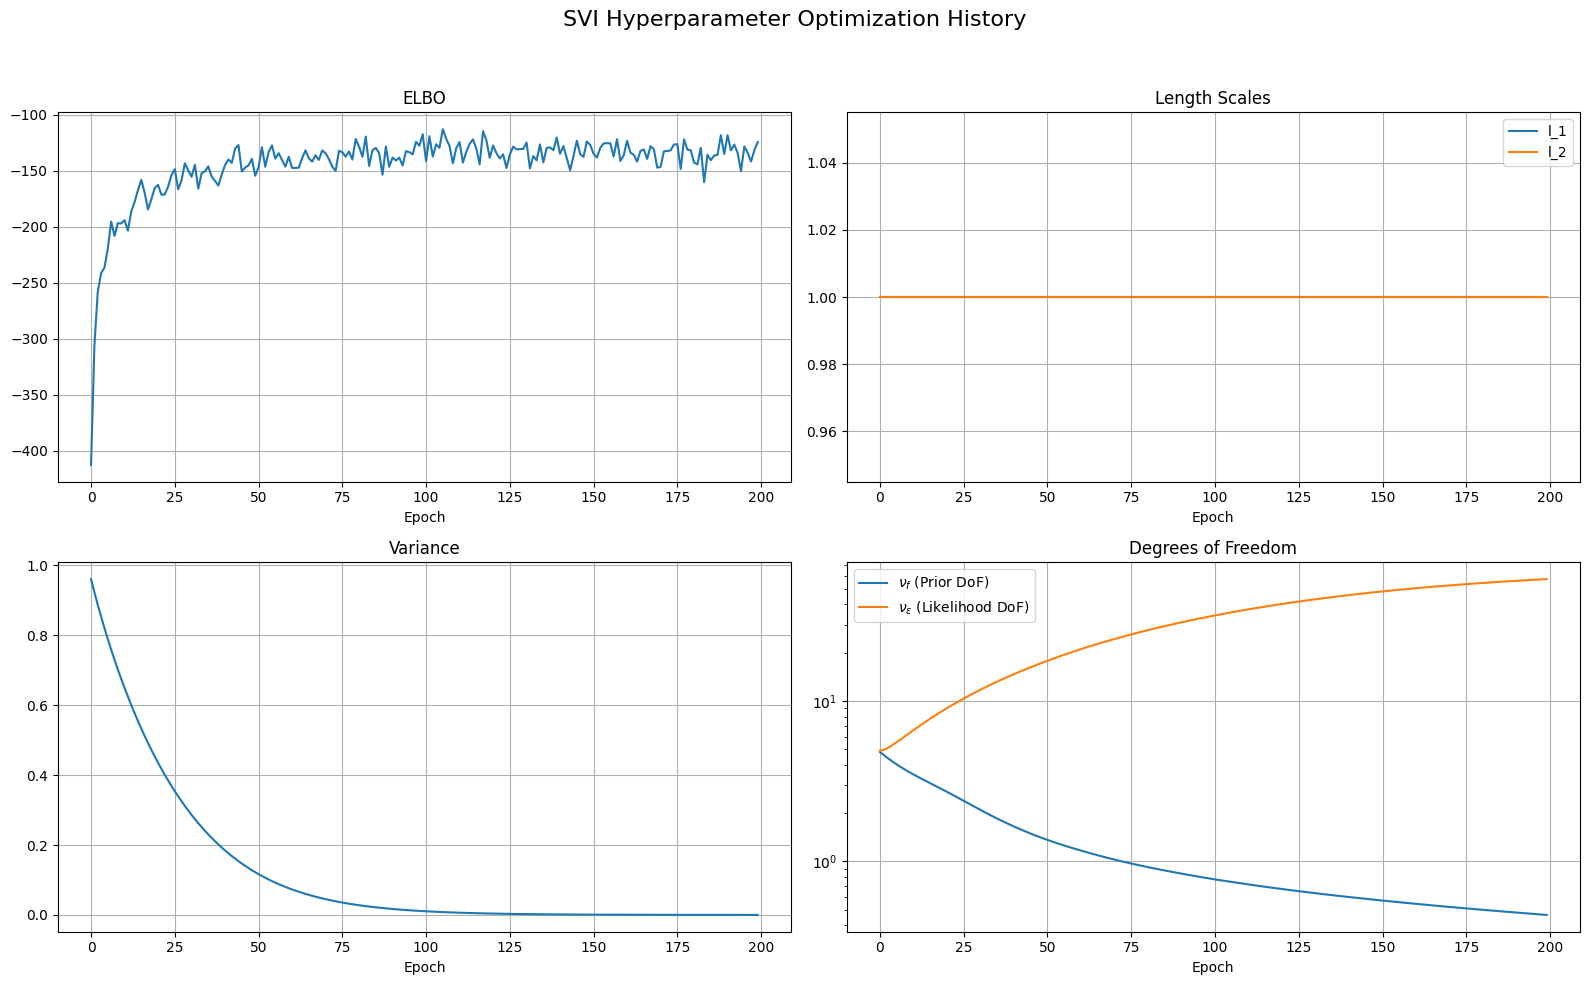

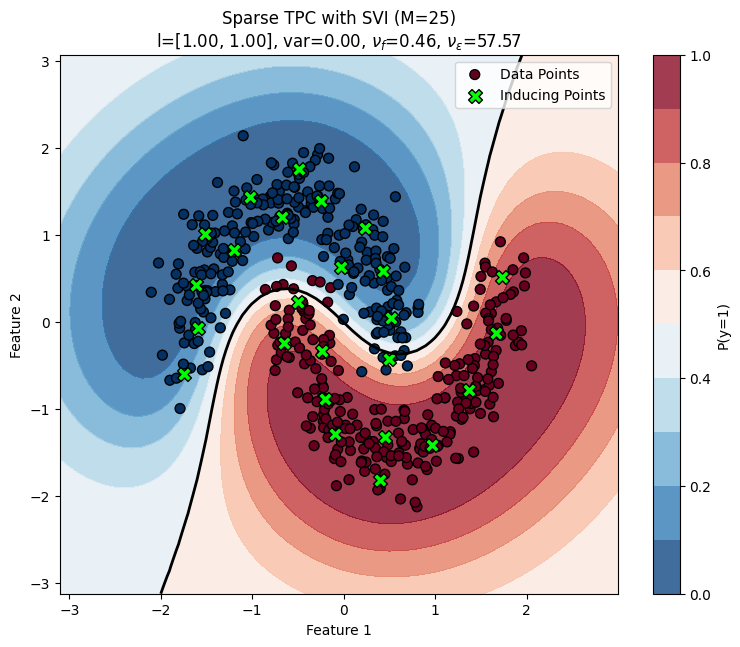

In [52]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.distributions import Normal, Gamma, LogNormal
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import math
from torch.utils.data import TensorDataset, DataLoader

# Import linear-operator for stability
from linear_operator.operators import to_linear_operator

# --- PyTorch Setup ---
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# --- Helper Functions (Unchanged) ---
def get_truncnorm_moments(y, mu, sigma_sq):
    sigma = torch.sqrt(sigma_sq)
    alpha = y * mu / sigma
    std_normal = Normal(torch.tensor([0.0], device=device), torch.tensor([1.0], device=device))
    pdf_alpha = torch.exp(std_normal.log_prob(alpha))
    cdf_alpha = std_normal.cdf(alpha).clamp(min=1e-12)
    ratio = pdf_alpha / cdf_alpha
    exp_z = mu + y * sigma * ratio
    var_z = sigma_sq * (1 - ratio * (alpha + ratio))
    exp_z_sq = var_z + exp_z**2
    return exp_z, exp_z_sq

def get_truncnorm_entropy(y, mu, sigma_sq):
    sigma = torch.sqrt(sigma_sq)
    alpha = y * mu / sigma
    std_normal = Normal(torch.tensor([0.0], device=device), torch.tensor([1.0], device=device))
    pdf_alpha = torch.exp(std_normal.log_prob(alpha))
    cdf_alpha = std_normal.cdf(alpha).clamp(min=1e-12)
    H = torch.log(torch.sqrt(2 * torch.pi * torch.e * sigma_sq) * cdf_alpha) - \
        alpha * pdf_alpha / (2 * cdf_alpha)
    return H.sum()

# --- Prior Classes ---
class GammaPrior(nn.Module):
    def __init__(self, concentration, rate):
        super().__init__()
        self.concentration = torch.tensor(concentration, device=device)
        self.rate = torch.tensor(rate, device=device)
        self.dist = Gamma(self.concentration, self.rate)
    def log_prob(self, x):
        return self.dist.log_prob(x).sum()

class LogNormalPrior(nn.Module):
    def __init__(self, loc, scale):
        super().__init__()
        self.loc = torch.tensor(loc, device=device)
        self.scale = torch.tensor(scale, device=device)
        self.dist = LogNormal(self.loc, self.scale)
    def log_prob(self, x):
        return self.dist.log_prob(x).sum()

# --- Sparse TPC Model with SVI and Natural Gradients ---
class Sparse_TPC_SVI_PyTorch(nn.Module):
    def __init__(self, n_inducing_points, nu_f=5.0, nu_epsilon=5.0,
                 initial_length_scale=1.0, initial_variance=1.0):
        super().__init__()
        self.M = n_inducing_points
        self.X_train_, self.y_train_ = None, None
        
        self.log_length_scale = None
        self.initial_length_scale = initial_length_scale
        self.log_variance = nn.Parameter(torch.log(torch.tensor(initial_variance, device=device)))
        self.inducing_points = None
        
        # Learnable degrees of freedom for Student-t distributions
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f, device=device)))
        self.log_nu_epsilon = nn.Parameter(torch.log(torch.tensor(nu_epsilon, device=device)))

        # Priors for regularization
        self.lengthscale_prior = GammaPrior(2.0, 1.0)
        self.variance_prior = GammaPrior(2.0, 1.0)
        self.nu_prior = LogNormalPrior(loc=math.log(5), scale=1.0) # Prior encourages nu > 1

        # Global variational parameters as persistent buffers
        self.register_buffer('m_u', torch.zeros(self.M, device=device))
        self.register_buffer('S_u', torch.eye(self.M, device=device))
        self.register_buffer('alpha_r', torch.tensor(1.0, device=device))
        self.register_buffer('beta_r', torch.tensor(1.0, device=device))

    def _compute_rbf_kernel(self, X1, X2, length_scale, variance):
        X1_scaled = X1 / length_scale
        X2_scaled = X2 / length_scale
        sqdist = torch.sum(X1_scaled**2, 1).reshape(-1, 1) + torch.sum(X2_scaled**2, 1) - 2 * (X1_scaled @ X2_scaled.T)
        sqdist = torch.clamp(sqdist, min=0.0)
        return variance * torch.exp(-0.5 * sqdist)

    def _get_hyperparams(self):
        return {
            'length_scale': torch.exp(self.log_length_scale),
            'variance': torch.exp(self.log_variance),
            'nu_f': torch.exp(self.log_nu_f),
            'nu_epsilon': torch.exp(self.log_nu_epsilon)
        }

    def _compute_kernels_and_operators(self, X, hp):
        K_xz = self._compute_rbf_kernel(X, self.inducing_points, hp['length_scale'], hp['variance'])
        K_zz_raw = self._compute_rbf_kernel(self.inducing_points, self.inducing_points, hp['length_scale'], hp['variance'])
        K_zz_op = to_linear_operator(K_zz_raw).add_jitter(1e-6)
        return K_xz, K_zz_op

    def _elbo(self, X_batch, y_batch, K_xz, K_zz_op, E_z_batch, E_z_sq_batch, alpha_w_batch, beta_w_batch):
        N = self.X_train_.shape[0]
        batch_size = X_batch.shape[0]
        hp = self._get_hyperparams()

        # Expectations from global posteriors
        E_r = self.alpha_r / self.beta_r
        E_r_inv = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1.0 else self.beta_r
        
        # Expectations from local posteriors
        E_w_batch = alpha_w_batch / beta_w_batch
        
        # Expected Log-Likelihood
        A = K_xz @ K_zz_op.solve(torch.eye(self.M, device=device))
        mu_f_batch = A @ self.m_u
        
        # Corrected variance of f
        K_tilde_diag = hp['variance'] - torch.einsum('ij,ji->i', A, K_xz.T)
        var_f_batch = E_r_inv * K_tilde_diag + torch.einsum('ij,jk,ki->i', A, self.S_u, A.T)
        
        E_f_sq_batch = var_f_batch + mu_f_batch**2
        E_f_minus_z_sq = E_z_sq_batch - 2 * E_z_batch * mu_f_batch + E_f_sq_batch
        
        # --- FIX: Convert float to tensor before torch.log ---
        log_2pi = torch.log(torch.tensor(2 * math.pi, device=device))
        exp_log_lik = torch.sum(-0.5 * log_2pi + 0.5 * (torch.digamma(alpha_w_batch) - torch.log(beta_w_batch)) - 0.5 * E_w_batch * E_f_minus_z_sq) * (N / batch_size)

        # Entropy H(q(z))
        H_q_z = get_truncnorm_entropy(y_batch, mu_f_batch, 1.0 / E_w_batch) * (N / batch_size)

        # KL Divergences (Global)
        logdet_K_zz = K_zz_op.logdet()
        logdet_S_u = torch.linalg.slogdet(self.S_u).logabsdet
        trace_term = torch.trace(K_zz_op.solve(self.S_u))
        m_T_Kinv_m = self.m_u.T @ K_zz_op.solve(self.m_u.unsqueeze(1))
        kl_u = 0.5 * (E_r * (trace_term + m_T_Kinv_m) - self.M - logdet_S_u + logdet_K_zz - self.M * (torch.digamma(self.alpha_r) - torch.log(self.beta_r)))
        
        p_alpha_r, p_beta_r = hp['nu_f'] / 2.0, hp['nu_f'] / 2.0
        kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
               p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r

        # KL Divergence (Local, scaled)
        p_alpha_w, p_beta_w = hp['nu_epsilon'] / 2.0, hp['nu_epsilon'] / 2.0
        kl_w = torch.sum((alpha_w_batch - p_alpha_w) * torch.digamma(alpha_w_batch) - torch.lgamma(alpha_w_batch) + torch.lgamma(p_alpha_w) + \
                         p_alpha_w * (torch.log(beta_w_batch) - torch.log(p_beta_w)) + alpha_w_batch * (p_beta_w - beta_w_batch) / beta_w_batch) * (N / batch_size)

        # Log Priors
        log_prior = self.lengthscale_prior.log_prob(hp['length_scale']) + self.variance_prior.log_prob(hp['variance']) + \
                    self.nu_prior.log_prob(hp['nu_f']) + self.nu_prior.log_prob(hp['nu_epsilon'])
        
        elbo = exp_log_lik - kl_u.squeeze() - kl_r - kl_w + H_q_z + log_prior
        return elbo

    def fit_svi(self, X, y, n_epochs=100, batch_size=128, hyper_lr=0.01, var_lr=0.1, local_cavi_iters=3):
        self.X_train_ = torch.tensor(X, device=device, dtype=torch.get_default_dtype())
        self.y_train_ = torch.tensor(2 * y - 1, device=device, dtype=torch.get_default_dtype())
        N, D = self.X_train_.shape

        if self.log_length_scale is None:
            self.log_length_scale = nn.Parameter(torch.log(torch.full((D,), self.initial_length_scale, device=device)))
        if self.inducing_points is None:
            kmeans = KMeans(n_clusters=self.M, random_state=42, n_init=10).fit(X.copy())
            self.inducing_points = nn.Parameter(torch.tensor(kmeans.cluster_centers_, device=device))

        self.m_u.data.zero_()
        self.S_u.data = torch.eye(self.M, device=device)
        hp_init = self._get_hyperparams()
        self.alpha_r.data = hp_init['nu_f'] / 2.0
        self.beta_r.data = hp_init['nu_f'] / 2.0
        
        hyper_optimizer = optim.Adam(self.parameters(), lr=hyper_lr)
        dataloader = DataLoader(TensorDataset(self.X_train_, self.y_train_), batch_size=batch_size, shuffle=True)
        
        history = {'elbo': [], 'length_scale': [], 'variance': [], 'nu_f': [], 'nu_epsilon': []}
        print(f"Starting Sparse TPC SVI (M={self.M})...")

        for epoch in range(n_epochs):
            for X_batch, y_batch in dataloader:
                y_batch = y_batch.squeeze()
                
                # --- E-Step Part 1: Converge local parameters for the batch ---
                with torch.no_grad():
                    hp = self._get_hyperparams()
                    K_xz, K_zz_op = self._compute_kernels_and_operators(X_batch, hp)
                    A_batch = K_xz @ K_zz_op.solve(torch.eye(self.M, device=device))
                    
                    # Initialize local params
                    alpha_w_batch = torch.ones_like(y_batch) * (hp['nu_epsilon'] / 2.0 + 0.5)
                    beta_w_batch = torch.ones_like(y_batch) * (hp['nu_epsilon'] / 2.0)

                    # Local CAVI loop
                    for _ in range(local_cavi_iters):
                        E_r_inv = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1.0 else self.beta_r
                        E_w_batch = alpha_w_batch / beta_w_batch
                        
                        mu_f_batch = A_batch @ self.m_u
                        E_z_batch, _ = get_truncnorm_moments(y_batch, mu_f_batch, 1.0 / E_w_batch)
                        
                        K_tilde_diag = hp['variance'] - torch.einsum('ij,ji->i', A_batch, K_xz.T)
                        var_f_batch = E_r_inv * K_tilde_diag + torch.einsum('ij,jk,ki->i', A_batch, self.S_u, A_batch.T)
                        
                        E_f_sq_batch = var_f_batch + mu_f_batch**2
                        E_sq_err = (E_z_batch - mu_f_batch)**2 + (1.0/E_w_batch) + var_f_batch # This is E[(z-f)^2]
                        
                        beta_w_batch = hp['nu_epsilon'] / 2.0 + 0.5 * E_sq_err

                # --- M-Step: Update Hyperparameters ---
                hyper_optimizer.zero_grad()
                E_z_batch, E_z_sq_batch = get_truncnorm_moments(y_batch, mu_f_batch, 1.0 / E_w_batch)
                loss = -self._elbo(X_batch, y_batch, K_xz, K_zz_op, E_z_batch, E_z_sq_batch, alpha_w_batch, beta_w_batch)
                loss.backward()
                hyper_optimizer.step()

                # --- E-Step Part 2: Update global parameters via Natural Gradients ---
                with torch.no_grad():
                    hp_updated = self._get_hyperparams()
                    K_xz_updated, K_zz_op_updated = self._compute_kernels_and_operators(X_batch, hp_updated)
                    A_batch_updated = K_xz_updated @ K_zz_op_updated.solve(torch.eye(self.M, device=device))
                    
                    # Target for q(u)
                    S_u_star_inv = A_batch_updated.T @ torch.diag(E_w_batch) @ A_batch_updated
                    S_u_star_inv += (self.alpha_r / self.beta_r) * K_zz_op_updated.solve(torch.eye(self.M, device=device))
                    m_u_star = torch.linalg.solve(S_u_star_inv, A_batch_updated.T @ (E_w_batch * E_z_batch).unsqueeze(1)).squeeze()
                    
                    # Target for q(r)
                    alpha_r_star = hp_updated['nu_f'] / 2.0 + self.M / 2.0
                    beta_r_star = hp_updated['nu_f'] / 2.0 + 0.5 * (m_u_star @ K_zz_op_updated.solve(m_u_star.unsqueeze(1)) + torch.trace(K_zz_op_updated.solve(torch.linalg.inv(S_u_star_inv))))
                    
                    # Convert to natural parameters and update
                    S_u_inv = torch.linalg.inv(self.S_u)
                    eta1_u_curr, eta2_u_curr = S_u_inv @ self.m_u, -0.5 * S_u_inv
                    eta1_u_star, eta2_u_star = S_u_star_inv @ m_u_star, -0.5 * S_u_star_inv
                    
                    eta1_r_curr, eta2_r_curr = self.alpha_r - 1, -self.beta_r
                    eta1_r_star, eta2_r_star = alpha_r_star - 1, -beta_r_star
                    
                    eta1_u_new = (1-var_lr)*eta1_u_curr + var_lr*eta1_u_star
                    eta2_u_new = (1-var_lr)*eta2_u_curr + var_lr*eta2_u_star
                    eta1_r_new = (1-var_lr)*eta1_r_curr + var_lr*eta1_r_star
                    eta2_r_new = (1-var_lr)*eta2_r_curr + var_lr*eta2_r_star
                    
                    # Convert back and update state
                    self.S_u.data = torch.linalg.inv(-2 * eta2_u_new)
                    self.m_u.data = self.S_u @ eta1_u_new
                    self.alpha_r.data = eta1_r_new + 1
                    self.beta_r.data = -eta2_r_new
            
            # Logging
            hp_updated = self._get_hyperparams()
            history['elbo'].append(-loss.item())
            history['length_scale'].append(hp_updated['length_scale'].detach().cpu().numpy())
            history['variance'].append(hp_updated['variance'].item())
            history['nu_f'].append(hp_updated['nu_f'].item())
            history['nu_epsilon'].append(hp_updated['nu_epsilon'].item())
            if (epoch + 1) % 10 == 0:
                ls_str = ", ".join([f"{l:.3f}" for l in hp_updated['length_scale']])
                print(f"Epoch {epoch+1:3d}/{n_epochs} | ELBO: {-loss.item():8.2f} | l: [{ls_str}] | var: {hp_updated['variance']:.3f} | nu_f: {hp_updated['nu_f']:.2f} | nu_e: {hp_updated['nu_epsilon']:.2f}")

        hp_final = self._get_hyperparams()
        _, K_zz_op_final = self._compute_kernels_and_operators(self.X_train_, hp_final)
        self.variational_params_ = {'K_zz_op': K_zz_op_final}
        print("Training complete.")
        return history

    def predict_proba(self, X_test):
        with torch.no_grad():
            if self.variational_params_ is None: raise RuntimeError("Model not trained.")
            X_test_t = torch.tensor(X_test, device=device)
            hp = self._get_hyperparams()
            K_zz_op = self.variational_params_['K_zz_op']
            
            k_star_z, _ = self._compute_kernels_and_operators(X_test_t, hp)
            k_star_star = hp['variance']
            
            mu_star = k_star_z @ K_zz_op.solve(self.m_u.unsqueeze(1)).squeeze()
            
            A_star = k_star_z @ K_zz_op.solve(torch.eye(self.M, device=device))
            E_r_inv = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1.0 else self.beta_r
            K_tilde_star_diag = k_star_star - torch.einsum('ij,ji->i', A_star, k_star_z.T)
            var_f_star = E_r_inv * K_tilde_star_diag + torch.einsum('ij,jk,ki->i', A_star, self.S_u, A_star.T)
            var_f_star = torch.clamp(var_f_star, min=1e-9)

            # Approximate Student-t predictive with a moment-matched Gaussian
            prob = Normal(0, 1).cdf(mu_star / torch.sqrt(1 + var_f_star))
            return prob.cpu().numpy()

# --- Main execution block ---
if __name__ == '__main__':
    def plot_decision_boundary_sparse(model, X, y, ax, title):
        x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
        y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
        Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        cs = ax.contourf(xx, yy, Z, cmap=plt.cm.RdBu_r, alpha=0.8, levels=np.linspace(0, 1, 11))
        plt.colorbar(cs, ax=ax, label="P(y=1)")
        ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu_r, edgecolors='k', s=50, label="Data Points")
        inducing_points = model.inducing_points.detach().cpu().numpy()
        ax.scatter(inducing_points[:, 0], inducing_points[:, 1], c='lime', edgecolors='k', s=100, marker='X', label='Inducing Points')
        ax.set_title(title); ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2"); ax.legend()

    def plot_history(history):
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        fig.suptitle("SVI Hyperparameter Optimization History", fontsize=16)
        axes = axes.ravel()
        axes[0].plot(history['elbo']); axes[0].set_title('ELBO')
        ls_history = np.array(history['length_scale'])
        for d in range(ls_history.shape[1]):
            axes[1].plot(ls_history[:, d], label=f'l_{d+1}')
        axes[1].set_title('Length Scales'); axes[1].legend()
        axes[2].plot(history['variance']); axes[2].set_title('Variance')
        axes[3].plot(history['nu_f'], label=r'$\nu_f$ (Prior DoF)')
        axes[3].plot(history['nu_epsilon'], label=r'$\nu_{\epsilon}$ (Likelihood DoF)')
        axes[3].set_title('Degrees of Freedom'); axes[3].legend(); axes[3].set_yscale('log')
        for ax in axes: ax.set_xlabel('Epoch'); ax.grid(True)
        fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()
    
    np.random.seed(42)
    X, y_true = make_moons(n_samples=500, noise=0.15, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    sparse_tpc_svi = Sparse_TPC_SVI_PyTorch(n_inducing_points=25)
    history = sparse_tpc_svi.fit_svi(X_scaled, y_true, n_epochs=200, batch_size=128, hyper_lr=0.01, var_lr=0.05, local_cavi_iters=3)
    
    plot_history(history)
    fig, ax = plt.subplots(1, 1, figsize=(9, 7))
    hp = sparse_tpc_svi._get_hyperparams()
    ls_vals = hp["length_scale"].detach().cpu().numpy()
    ls_str = ", ".join([f"{l:.2f}" for l in ls_vals])
    title = (f'Sparse TPC with SVI (M=25)\n' f'l=[{ls_str}], var={hp["variance"]:.2f}, '
             f'$\\nu_f$={hp["nu_f"]:.2f}, $\\nu_\\epsilon$={hp["nu_epsilon"]:.2f}')
    plot_decision_boundary_sparse(sparse_tpc_svi, X_scaled, y_true, ax, title)
    plt.show()


Using device: cuda
Starting Sparse TPC SVI (M=25)...
Epoch  10/200 | ELBO:  -184.67 | l: [0.939, 0.940] | var: 1.064 | nu_f: 3.60 | nu_e: 6.45
Epoch  20/200 | ELBO:  -153.06 | l: [0.936, 0.940] | var: 1.066 | nu_f: 3.00 | nu_e: 8.94
Epoch  30/200 | ELBO:  -145.56 | l: [0.935, 0.941] | var: 1.066 | nu_f: 2.58 | nu_e: 11.74
Epoch  40/200 | ELBO:  -132.30 | l: [0.932, 0.943] | var: 1.064 | nu_f: 2.13 | nu_e: 14.76
Epoch  50/200 | ELBO:  -125.59 | l: [0.930, 0.946] | var: 1.059 | nu_f: 1.74 | nu_e: 17.94
Epoch  60/200 | ELBO:  -122.41 | l: [0.933, 0.951] | var: 1.047 | nu_f: 1.55 | nu_e: 21.22
Epoch  70/200 | ELBO:  -117.03 | l: [0.941, 0.958] | var: 1.030 | nu_f: 1.44 | nu_e: 24.54
Epoch  80/200 | ELBO:  -112.25 | l: [0.949, 0.967] | var: 1.010 | nu_f: 1.38 | nu_e: 27.86
Epoch  90/200 | ELBO:  -113.04 | l: [0.958, 0.979] | var: 0.989 | nu_f: 1.34 | nu_e: 31.16
Epoch 100/200 | ELBO:  -109.54 | l: [0.965, 0.992] | var: 0.969 | nu_f: 1.31 | nu_e: 34.39
Epoch 110/200 | ELBO:  -124.59 | l: [0.

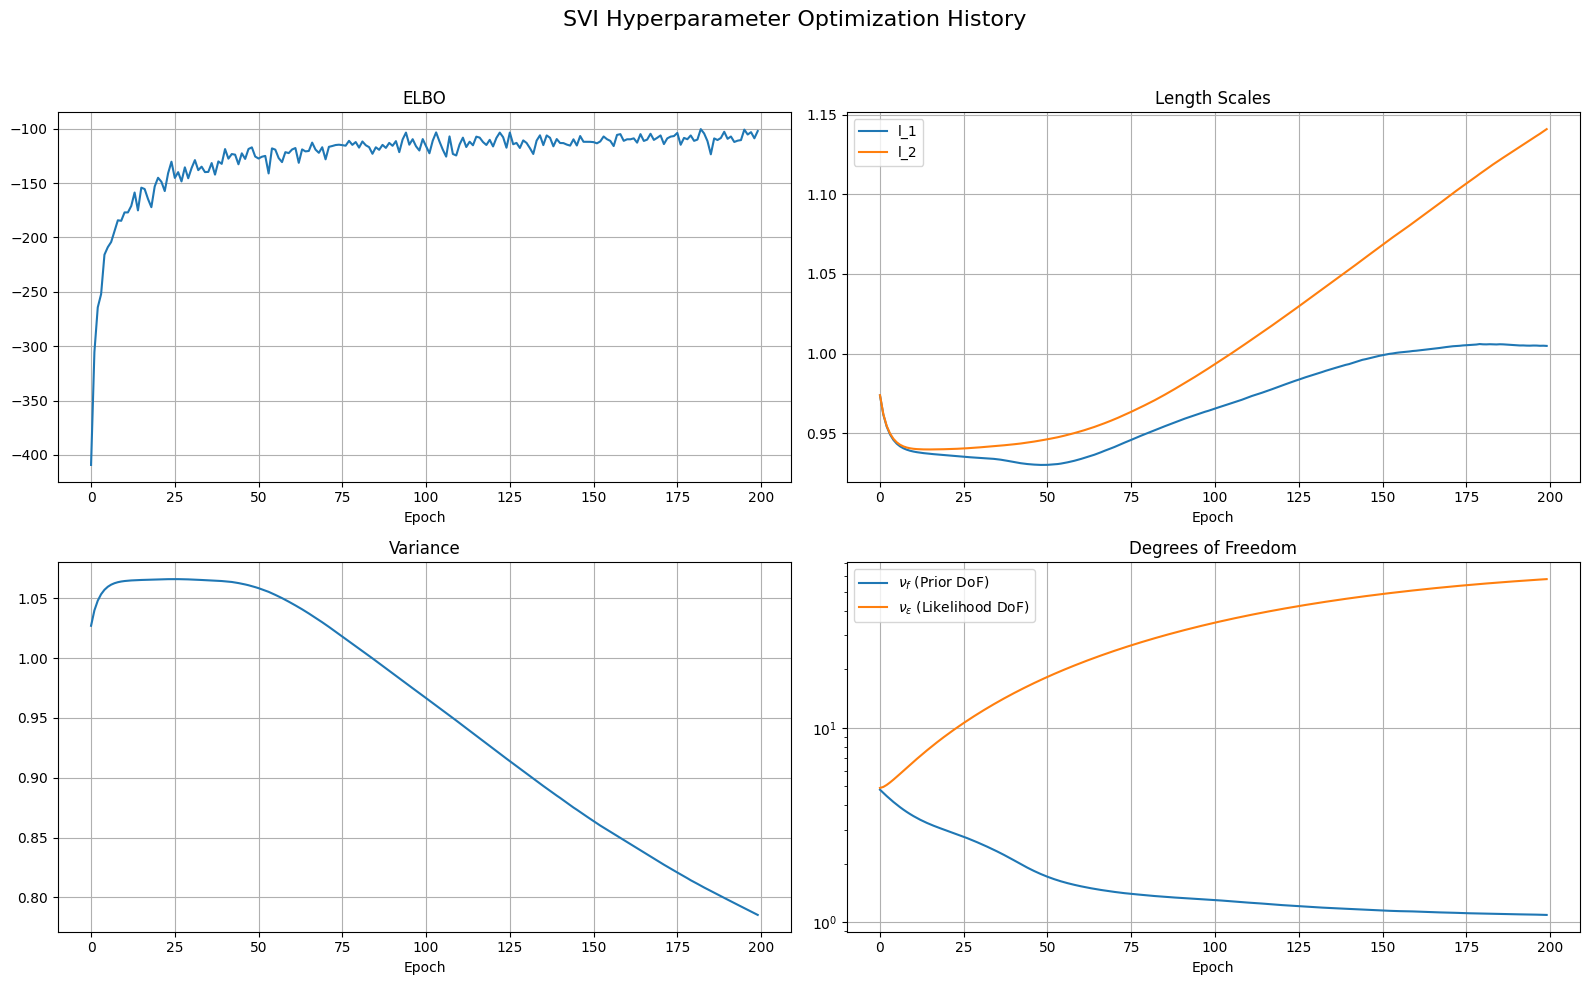

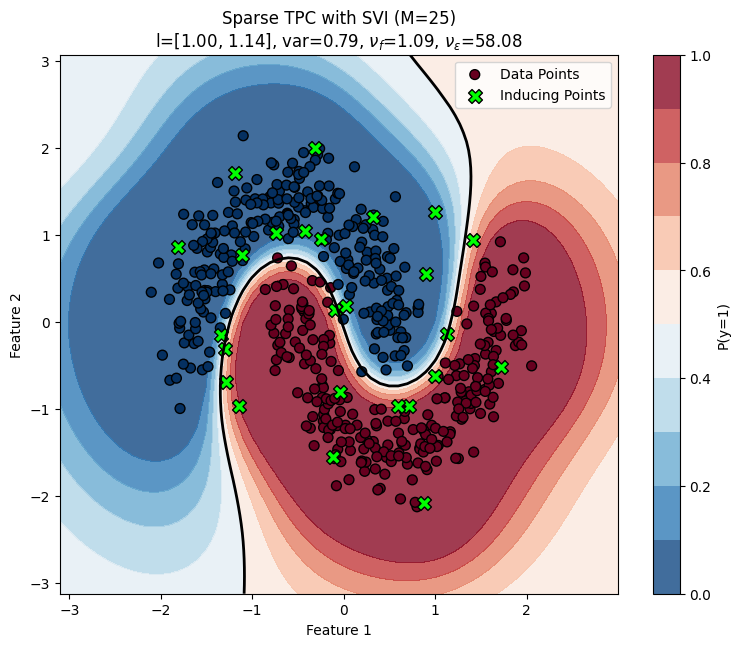

In [53]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.distributions import Normal, Gamma, LogNormal
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import math
from torch.utils.data import TensorDataset, DataLoader

# Import linear-operator for stability
from linear_operator.operators import to_linear_operator

# --- PyTorch Setup ---
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# --- Helper Functions (Unchanged) ---
def get_truncnorm_moments(y, mu, sigma_sq):
    sigma = torch.sqrt(sigma_sq)
    alpha = y * mu / sigma
    std_normal = Normal(torch.tensor([0.0], device=device), torch.tensor([1.0], device=device))
    pdf_alpha = torch.exp(std_normal.log_prob(alpha))
    cdf_alpha = std_normal.cdf(alpha).clamp(min=1e-12)
    ratio = pdf_alpha / cdf_alpha
    exp_z = mu + y * sigma * ratio
    var_z = sigma_sq * (1 - ratio * (alpha + ratio))
    exp_z_sq = var_z + exp_z**2
    return exp_z, exp_z_sq

def get_truncnorm_entropy(y, mu, sigma_sq):
    sigma = torch.sqrt(sigma_sq)
    alpha = y * mu / sigma
    std_normal = Normal(torch.tensor([0.0], device=device), torch.tensor([1.0], device=device))
    pdf_alpha = torch.exp(std_normal.log_prob(alpha))
    cdf_alpha = std_normal.cdf(alpha).clamp(min=1e-12)
    H = torch.log(torch.sqrt(2 * torch.pi * torch.e * sigma_sq) * cdf_alpha) - \
        alpha * pdf_alpha / (2 * cdf_alpha)
    return H.sum()

# --- Prior Classes ---
class GammaPrior(nn.Module):
    def __init__(self, concentration, rate):
        super().__init__()
        self.concentration = torch.tensor(concentration, device=device)
        self.rate = torch.tensor(rate, device=device)
        self.dist = Gamma(self.concentration, self.rate)
    def log_prob(self, x):
        return self.dist.log_prob(x).sum()

class LogNormalPrior(nn.Module):
    def __init__(self, loc, scale):
        super().__init__()
        self.loc = torch.tensor(loc, device=device)
        self.scale = torch.tensor(scale, device=device)
        self.dist = LogNormal(self.loc, self.scale)
    def log_prob(self, x):
        return self.dist.log_prob(x).sum()

# --- Sparse TPC Model with SVI and Natural Gradients ---
class Sparse_TPC_SVI_PyTorch(nn.Module):
    def __init__(self, n_inducing_points, nu_f=5.0, nu_epsilon=5.0,
                 initial_length_scale=1.0, initial_variance=1.0):
        super().__init__()
        self.M = n_inducing_points
        self.X_train_, self.y_train_ = None, None
        
        self.log_length_scale = None
        self.initial_length_scale = initial_length_scale
        self.log_variance = nn.Parameter(torch.log(torch.tensor(initial_variance, device=device)))
        self.inducing_points = None
        
        # Learnable degrees of freedom for Student-t distributions
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f, device=device)))
        self.log_nu_epsilon = nn.Parameter(torch.log(torch.tensor(nu_epsilon, device=device)))

        # Priors for regularization
        self.lengthscale_prior = GammaPrior(2.0, 1.0)
        self.variance_prior = GammaPrior(2.0, 1.0)
        self.nu_prior = LogNormalPrior(loc=math.log(5), scale=1.0) # Prior encourages nu > 1

        # Global variational parameters as persistent buffers
        self.register_buffer('m_u', torch.zeros(self.M, device=device))
        self.register_buffer('S_u', torch.eye(self.M, device=device))
        self.register_buffer('alpha_r', torch.tensor(1.0, device=device))
        self.register_buffer('beta_r', torch.tensor(1.0, device=device))

    def _compute_rbf_kernel(self, X1, X2, length_scale, variance):
        X1_scaled = X1 / length_scale
        X2_scaled = X2 / length_scale
        sqdist = torch.sum(X1_scaled**2, 1).reshape(-1, 1) + torch.sum(X2_scaled**2, 1) - 2 * (X1_scaled @ X2_scaled.T)
        sqdist = torch.clamp(sqdist, min=0.0)
        return variance * torch.exp(-0.5 * sqdist)

    def _get_hyperparams(self):
        return {
            'length_scale': torch.exp(self.log_length_scale),
            'variance': torch.exp(self.log_variance),
            'nu_f': torch.exp(self.log_nu_f),
            'nu_epsilon': torch.exp(self.log_nu_epsilon)
        }

    def _compute_kernels_and_operators(self, X, hp):
        K_xz = self._compute_rbf_kernel(X, self.inducing_points, hp['length_scale'], hp['variance'])
        K_zz_raw = self._compute_rbf_kernel(self.inducing_points, self.inducing_points, hp['length_scale'], hp['variance'])
        K_zz_op = to_linear_operator(K_zz_raw).add_jitter(1e-6)
        return K_xz, K_zz_op

    def _elbo(self, X_batch, y_batch, K_xz, K_zz_op, E_z_batch, E_z_sq_batch, alpha_w_batch, beta_w_batch):
        N = self.X_train_.shape[0]
        batch_size = X_batch.shape[0]
        hp = self._get_hyperparams()

        E_r = self.alpha_r / self.beta_r
        E_r_inv = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1.0 else self.beta_r
        E_w_batch = alpha_w_batch / beta_w_batch
        
        A = K_xz @ K_zz_op.solve(torch.eye(self.M, device=device))
        mu_f_batch = A @ self.m_u
        
        K_tilde_diag = hp['variance'] - torch.einsum('ij,ji->i', A, K_xz.T)
        var_f_batch = E_r_inv * K_tilde_diag + torch.einsum('ij,jk,ki->i', A, self.S_u, A.T)
        
        E_f_sq_batch = var_f_batch + mu_f_batch**2
        E_f_minus_z_sq = E_z_sq_batch - 2 * E_z_batch * mu_f_batch + E_f_sq_batch
        
        log_2pi = torch.log(torch.tensor(2 * math.pi, device=device))
        exp_log_lik = torch.sum(-0.5 * log_2pi + 0.5 * (torch.digamma(alpha_w_batch) - torch.log(beta_w_batch)) - 0.5 * E_w_batch * E_f_minus_z_sq) * (N / batch_size)

        H_q_z = get_truncnorm_entropy(y_batch, mu_f_batch, 1.0 / E_w_batch) * (N / batch_size)

        logdet_K_zz = K_zz_op.logdet()
        logdet_S_u = torch.linalg.slogdet(self.S_u).logabsdet
        trace_term = torch.trace(K_zz_op.solve(self.S_u))
        m_T_Kinv_m = self.m_u.T @ K_zz_op.solve(self.m_u.unsqueeze(1))
        kl_u = 0.5 * (E_r * (trace_term + m_T_Kinv_m) - self.M - logdet_S_u + logdet_K_zz - self.M * (torch.digamma(self.alpha_r) - torch.log(self.beta_r)))
        
        p_alpha_r, p_beta_r = hp['nu_f'] / 2.0, hp['nu_f'] / 2.0
        kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
               p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r

        p_alpha_w, p_beta_w = hp['nu_epsilon'] / 2.0, hp['nu_epsilon'] / 2.0
        kl_w = torch.sum((alpha_w_batch - p_alpha_w) * torch.digamma(alpha_w_batch) - torch.lgamma(alpha_w_batch) + torch.lgamma(p_alpha_w) + \
                         p_alpha_w * (torch.log(beta_w_batch) - torch.log(p_beta_w)) + alpha_w_batch * (p_beta_w - beta_w_batch) / beta_w_batch) * (N / batch_size)

        log_prior = self.lengthscale_prior.log_prob(hp['length_scale']) + self.variance_prior.log_prob(hp['variance']) + \
                    self.nu_prior.log_prob(hp['nu_f']) + self.nu_prior.log_prob(hp['nu_epsilon'])
        
        elbo = exp_log_lik - kl_u.squeeze() - kl_r - kl_w + H_q_z + log_prior
        return elbo

    def fit_svi(self, X, y, n_epochs=100, batch_size=128, hyper_lr=0.01, var_lr=0.1, local_cavi_iters=3):
        self.X_train_ = torch.tensor(X, device=device, dtype=torch.get_default_dtype())
        self.y_train_ = torch.tensor(2 * y - 1, device=device, dtype=torch.get_default_dtype())
        N, D = self.X_train_.shape

        if self.log_length_scale is None:
            self.log_length_scale = nn.Parameter(torch.log(torch.full((D,), self.initial_length_scale, device=device)))
        if self.inducing_points is None:
            kmeans = KMeans(n_clusters=self.M, random_state=42, n_init=10).fit(X.copy())
            self.inducing_points = nn.Parameter(torch.tensor(kmeans.cluster_centers_, device=device))

        self.m_u.data.zero_()
        self.S_u.data = torch.eye(self.M, device=device)
        hp_init = self._get_hyperparams()
        self.alpha_r.data = hp_init['nu_f'] / 2.0
        self.beta_r.data = hp_init['nu_f'] / 2.0
        
        hyper_optimizer = optim.Adam(self.parameters(), lr=hyper_lr)
        dataloader = DataLoader(TensorDataset(self.X_train_, self.y_train_), batch_size=batch_size, shuffle=True)
        
        history = {'elbo': [], 'length_scale': [], 'variance': [], 'nu_f': [], 'nu_epsilon': []}
        print(f"Starting Sparse TPC SVI (M={self.M})...")

        for epoch in range(n_epochs):
            for X_batch, y_batch in dataloader:
                y_batch = y_batch.squeeze()
                
                # --- BUG FIX: Compute kernels OUTSIDE of no_grad block ---
                hp = self._get_hyperparams()
                K_xz, K_zz_op = self._compute_kernels_and_operators(X_batch, hp)
                
                # --- E-Step Part 1: Converge local parameters for the batch ---
                with torch.no_grad():
                    A_batch = K_xz @ K_zz_op.solve(torch.eye(self.M, device=device))
                    alpha_w_batch = torch.ones_like(y_batch) * (hp['nu_epsilon'] / 2.0 + 0.5)
                    beta_w_batch = torch.ones_like(y_batch) * (hp['nu_epsilon'] / 2.0)

                    for _ in range(local_cavi_iters):
                        E_r_inv = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1.0 else self.beta_r
                        E_w_batch = alpha_w_batch / beta_w_batch
                        mu_f_batch = A_batch @ self.m_u
                        E_z_batch, _ = get_truncnorm_moments(y_batch, mu_f_batch, 1.0 / E_w_batch)
                        K_tilde_diag = hp['variance'] - torch.einsum('ij,ji->i', A_batch, K_xz.T)
                        var_f_batch = E_r_inv * K_tilde_diag + torch.einsum('ij,jk,ki->i', A_batch, self.S_u, A_batch.T)
                        E_sq_err = (E_z_batch - mu_f_batch)**2 + (1.0/E_w_batch) + var_f_batch
                        beta_w_batch = hp['nu_epsilon'] / 2.0 + 0.5 * E_sq_err

                # --- M-Step: Update Hyperparameters ---
                hyper_optimizer.zero_grad()
                E_z_batch, E_z_sq_batch = get_truncnorm_moments(y_batch, mu_f_batch, 1.0 / E_w_batch)
                loss = -self._elbo(X_batch, y_batch, K_xz, K_zz_op, E_z_batch, E_z_sq_batch, alpha_w_batch, beta_w_batch)
                loss.backward()
                hyper_optimizer.step()

                # --- E-Step Part 2: Update global parameters via Natural Gradients ---
                with torch.no_grad():
                    hp_updated = self._get_hyperparams()
                    K_xz_updated, K_zz_op_updated = self._compute_kernels_and_operators(X_batch, hp_updated)
                    A_batch_updated = K_xz_updated @ K_zz_op_updated.solve(torch.eye(self.M, device=device))
                    
                    S_u_star_inv = A_batch_updated.T @ torch.diag(E_w_batch) @ A_batch_updated
                    S_u_star_inv += (self.alpha_r / self.beta_r) * K_zz_op_updated.solve(torch.eye(self.M, device=device))
                    m_u_star = torch.linalg.solve(S_u_star_inv, A_batch_updated.T @ (E_w_batch * E_z_batch).unsqueeze(1)).squeeze()
                    
                    alpha_r_star = hp_updated['nu_f'] / 2.0 + self.M / 2.0
                    beta_r_star = hp_updated['nu_f'] / 2.0 + 0.5 * (m_u_star @ K_zz_op_updated.solve(m_u_star.unsqueeze(1)) + torch.trace(K_zz_op_updated.solve(torch.linalg.inv(S_u_star_inv))))
                    
                    S_u_inv = torch.linalg.inv(self.S_u)
                    eta1_u_curr, eta2_u_curr = S_u_inv @ self.m_u, -0.5 * S_u_inv
                    eta1_u_star, eta2_u_star = S_u_star_inv @ m_u_star, -0.5 * S_u_star_inv
                    
                    eta1_r_curr, eta2_r_curr = self.alpha_r - 1, -self.beta_r
                    eta1_r_star, eta2_r_star = alpha_r_star - 1, -beta_r_star
                    
                    eta1_u_new = (1-var_lr)*eta1_u_curr + var_lr*eta1_u_star
                    eta2_u_new = (1-var_lr)*eta2_u_curr + var_lr*eta2_u_star
                    eta1_r_new = (1-var_lr)*eta1_r_curr + var_lr*eta1_r_star
                    eta2_r_new = (1-var_lr)*eta2_r_curr + var_lr*eta2_r_star
                    
                    self.S_u.data = torch.linalg.inv(-2 * eta2_u_new)
                    self.m_u.data = self.S_u @ eta1_u_new
                    self.alpha_r.data = eta1_r_new + 1
                    self.beta_r.data = -eta2_r_new
            
            # Logging
            hp_updated = self._get_hyperparams()
            history['elbo'].append(-loss.item())
            history['length_scale'].append(hp_updated['length_scale'].detach().cpu().numpy())
            history['variance'].append(hp_updated['variance'].item())
            history['nu_f'].append(hp_updated['nu_f'].item())
            history['nu_epsilon'].append(hp_updated['nu_epsilon'].item())
            if (epoch + 1) % 10 == 0:
                ls_str = ", ".join([f"{l:.3f}" for l in hp_updated['length_scale']])
                print(f"Epoch {epoch+1:3d}/{n_epochs} | ELBO: {-loss.item():8.2f} | l: [{ls_str}] | var: {hp_updated['variance']:.3f} | nu_f: {hp_updated['nu_f']:.2f} | nu_e: {hp_updated['nu_epsilon']:.2f}")

        hp_final = self._get_hyperparams()
        _, K_zz_op_final = self._compute_kernels_and_operators(self.X_train_, hp_final)
        self.variational_params_ = {'K_zz_op': K_zz_op_final}
        print("Training complete.")
        return history

    def predict_proba(self, X_test):
        with torch.no_grad():
            if self.variational_params_ is None: raise RuntimeError("Model not trained.")
            X_test_t = torch.tensor(X_test, device=device)
            hp = self._get_hyperparams()
            K_zz_op = self.variational_params_['K_zz_op']
            
            k_star_z, _ = self._compute_kernels_and_operators(X_test_t, hp)
            k_star_star = hp['variance']
            
            mu_star = k_star_z @ K_zz_op.solve(self.m_u.unsqueeze(1)).squeeze()
            
            A_star = k_star_z @ K_zz_op.solve(torch.eye(self.M, device=device))
            E_r_inv = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1.0 else self.beta_r
            K_tilde_star_diag = k_star_star - torch.einsum('ij,ji->i', A_star, k_star_z.T)
            var_f_star = E_r_inv * K_tilde_star_diag + torch.einsum('ij,jk,ki->i', A_star, self.S_u, A_star.T)
            var_f_star = torch.clamp(var_f_star, min=1e-9)

            prob = Normal(0, 1).cdf(mu_star / torch.sqrt(1 + var_f_star))
            return prob.cpu().numpy()

# --- Main execution block ---
if __name__ == '__main__':
    def plot_decision_boundary_sparse(model, X, y, ax, title):
        x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
        y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
        Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        cs = ax.contourf(xx, yy, Z, cmap=plt.cm.RdBu_r, alpha=0.8, levels=np.linspace(0, 1, 11))
        plt.colorbar(cs, ax=ax, label="P(y=1)")
        ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu_r, edgecolors='k', s=50, label="Data Points")
        inducing_points = model.inducing_points.detach().cpu().numpy()
        ax.scatter(inducing_points[:, 0], inducing_points[:, 1], c='lime', edgecolors='k', s=100, marker='X', label='Inducing Points')
        ax.set_title(title); ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2"); ax.legend()

    def plot_history(history):
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        fig.suptitle("SVI Hyperparameter Optimization History", fontsize=16)
        axes = axes.ravel()
        axes[0].plot(history['elbo']); axes[0].set_title('ELBO')
        ls_history = np.array(history['length_scale'])
        for d in range(ls_history.shape[1]):
            axes[1].plot(ls_history[:, d], label=f'l_{d+1}')
        axes[1].set_title('Length Scales'); axes[1].legend()
        axes[2].plot(history['variance']); axes[2].set_title('Variance')
        axes[3].plot(history['nu_f'], label=r'$\nu_f$ (Prior DoF)')
        axes[3].plot(history['nu_epsilon'], label=r'$\nu_{\epsilon}$ (Likelihood DoF)')
        axes[3].set_title('Degrees of Freedom'); axes[3].legend(); axes[3].set_yscale('log')
        for ax in axes: ax.set_xlabel('Epoch'); ax.grid(True)
        fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()
    
    np.random.seed(42)
    X, y_true = make_moons(n_samples=500, noise=0.15, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    sparse_tpc_svi = Sparse_TPC_SVI_PyTorch(n_inducing_points=25)
    history = sparse_tpc_svi.fit_svi(X_scaled, y_true, n_epochs=200, batch_size=128, hyper_lr=0.01, var_lr=0.05, local_cavi_iters=3)
    
    plot_history(history)
    fig, ax = plt.subplots(1, 1, figsize=(9, 7))
    hp = sparse_tpc_svi._get_hyperparams()
    ls_vals = hp["length_scale"].detach().cpu().numpy()
    ls_str = ", ".join([f"{l:.2f}" for l in ls_vals])
    title = (f'Sparse TPC with SVI (M=25)\n' f'l=[{ls_str}], var={hp["variance"]:.2f}, '
             f'$\\nu_f$={hp["nu_f"]:.2f}, $\\nu_\\epsilon$={hp["nu_epsilon"]:.2f}')
    plot_decision_boundary_sparse(sparse_tpc_svi, X_scaled, y_true, ax, title)
    plt.show()


Using device: cuda
Starting Sparse TPC SVI (M=25)...
Fixed parameters: ['variance']
Learnable parameters: ['log_length_scale', 'log_nu_f', 'log_nu_epsilon', 'inducing_points']


Epoch  10/2000 | ELBO:  -189.02 | l: [0.939, 0.940] | var: 1.000 | nu_f: 3.60 | nu_e: 6.54
Epoch  20/2000 | ELBO:  -159.51 | l: [0.936, 0.940] | var: 1.000 | nu_f: 2.98 | nu_e: 9.09
Epoch  30/2000 | ELBO:  -136.07 | l: [0.934, 0.941] | var: 1.000 | nu_f: 2.55 | nu_e: 11.95
Epoch  40/2000 | ELBO:  -140.33 | l: [0.932, 0.942] | var: 1.000 | nu_f: 2.11 | nu_e: 15.03
Epoch  50/2000 | ELBO:  -134.44 | l: [0.930, 0.945] | var: 1.000 | nu_f: 1.73 | nu_e: 18.28
Epoch  60/2000 | ELBO:  -118.60 | l: [0.933, 0.950] | var: 1.000 | nu_f: 1.53 | nu_e: 21.61
Epoch  70/2000 | ELBO:  -116.81 | l: [0.941, 0.957] | var: 1.000 | nu_f: 1.42 | nu_e: 24.97
Epoch  80/2000 | ELBO:  -125.51 | l: [0.951, 0.967] | var: 1.000 | nu_f: 1.37 | nu_e: 28.33
Epoch  90/2000 | ELBO:  -117.54 | l: [0.962, 0.979] | var: 1.000 | nu_f: 1.33 | nu_e: 31.65
Epoch 100/2000 | ELBO:  -108.03 | l: [0.972, 0.991] | var: 1.000 | nu_f: 1.30 | nu_e: 34.89
Epoch 110/2000 | ELBO:  -110.39 | l: [0.981, 1.005] | var: 1.000 | nu_f: 1.27 | nu

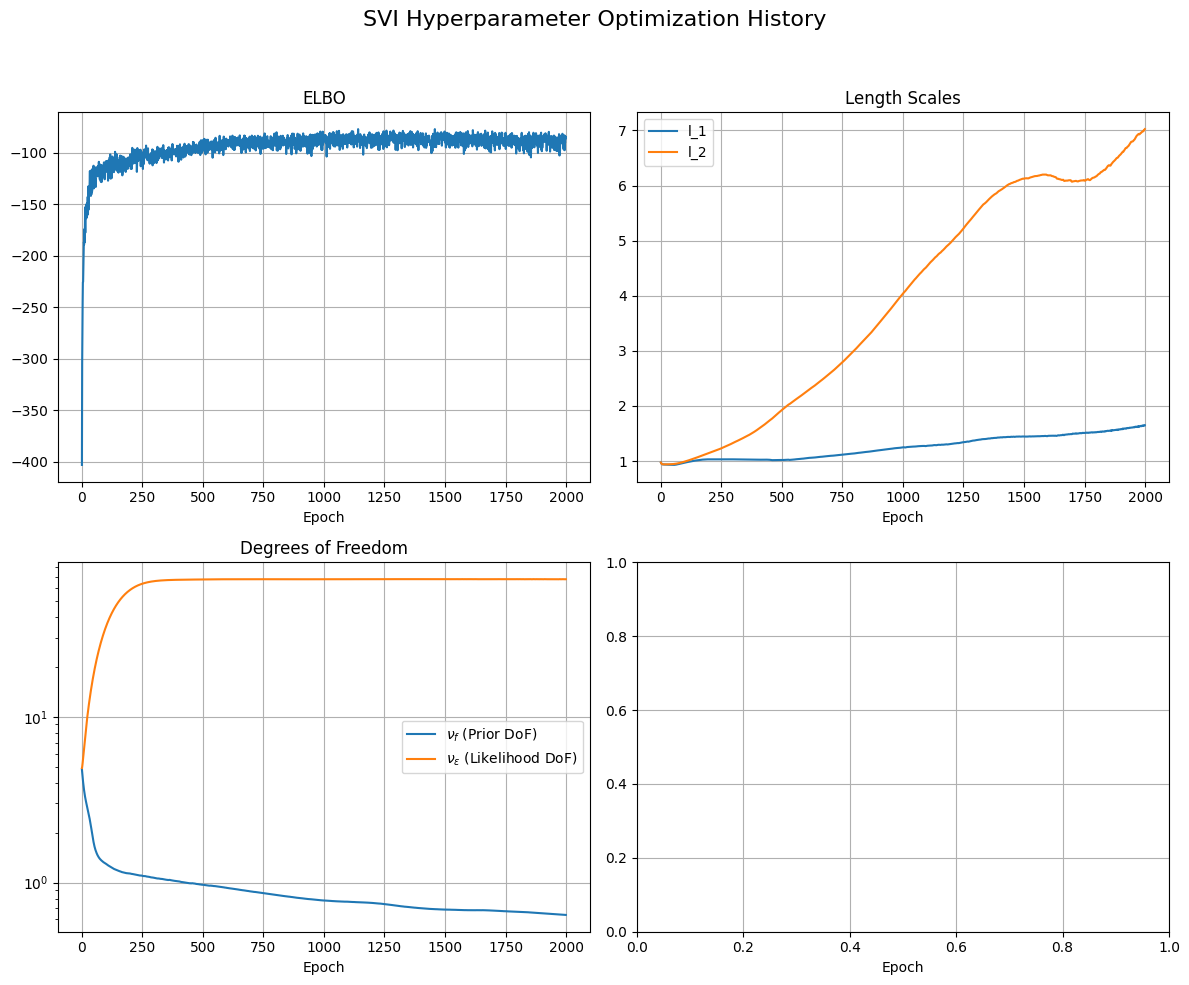

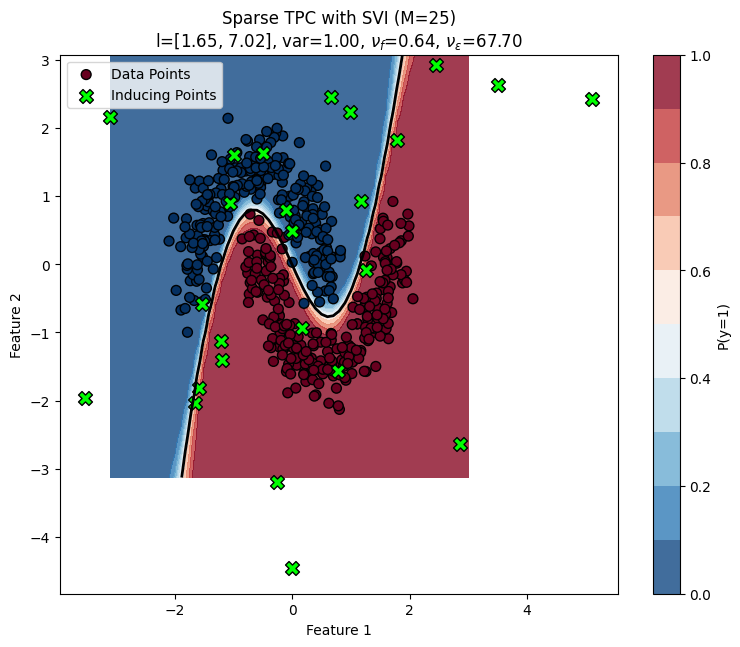

In [57]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.distributions import Normal, Gamma, LogNormal
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import math
from torch.utils.data import TensorDataset, DataLoader

# Import linear-operator for stability
from linear_operator.operators import to_linear_operator

# --- PyTorch Setup ---
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# --- Helper Functions (Unchanged) ---
def get_truncnorm_moments(y, mu, sigma_sq):
    sigma = torch.sqrt(sigma_sq)
    alpha = y * mu / sigma
    std_normal = Normal(torch.tensor([0.0], device=device), torch.tensor([1.0], device=device))
    pdf_alpha = torch.exp(std_normal.log_prob(alpha))
    cdf_alpha = std_normal.cdf(alpha).clamp(min=1e-12)
    ratio = pdf_alpha / cdf_alpha
    exp_z = mu + y * sigma * ratio
    var_z = sigma_sq * (1 - ratio * (alpha + ratio))
    exp_z_sq = var_z + exp_z**2
    return exp_z, exp_z_sq

def get_truncnorm_entropy(y, mu, sigma_sq):
    sigma = torch.sqrt(sigma_sq)
    alpha = y * mu / sigma
    std_normal = Normal(torch.tensor([0.0], device=device), torch.tensor([1.0], device=device))
    pdf_alpha = torch.exp(std_normal.log_prob(alpha))
    cdf_alpha = std_normal.cdf(alpha).clamp(min=1e-12)
    H = torch.log(torch.sqrt(2 * torch.pi * torch.e * sigma_sq) * cdf_alpha) - \
        alpha * pdf_alpha / (2 * cdf_alpha)
    return H.sum()

# --- Prior Classes ---
class GammaPrior(nn.Module):
    def __init__(self, concentration, rate):
        super().__init__()
        self.concentration = torch.tensor(concentration, device=device)
        self.rate = torch.tensor(rate, device=device)
        self.dist = Gamma(self.concentration, self.rate)
    def log_prob(self, x):
        return self.dist.log_prob(x).sum()

class LogNormalPrior(nn.Module):
    def __init__(self, loc, scale):
        super().__init__()
        self.loc = torch.tensor(loc, device=device)
        self.scale = torch.tensor(scale, device=device)
        self.dist = LogNormal(self.loc, self.scale)
    def log_prob(self, x):
        return self.dist.log_prob(x).sum()

# --- Sparse TPC Model with SVI and Natural Gradients ---
class Sparse_TPC_SVI_PyTorch(nn.Module):
    def __init__(self, n_inducing_points, nu_f=5.0, nu_epsilon=5.0,
                 initial_length_scale=1.0, initial_variance=1.0, fixed_params=None):
        super().__init__()
        self.M = n_inducing_points
        self.X_train_, self.y_train_ = None, None
        
        fixed_params = fixed_params or []
        self.fixed_params = fixed_params

        if 'length_scale' not in fixed_params:
            self.log_length_scale = nn.Parameter(torch.log(torch.tensor(initial_length_scale, device=device)))
        else:
            self.register_buffer('length_scale', torch.tensor(initial_length_scale, device=device))

        if 'variance' not in fixed_params:
            self.log_variance = nn.Parameter(torch.log(torch.tensor(initial_variance, device=device)))
        else:
            self.register_buffer('variance', torch.tensor(initial_variance, device=device))

        if 'inducing_points' not in fixed_params:
            self.inducing_points_learnable = True
            self.inducing_points = None
        else:
            self.inducing_points_learnable = False
            self.register_buffer('inducing_points', None)

        if 'nu_f' not in fixed_params:
            self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f, device=device)))
        else:
            self.register_buffer('nu_f', torch.tensor(nu_f, device=device))
            
        if 'nu_epsilon' not in fixed_params:
            self.log_nu_epsilon = nn.Parameter(torch.log(torch.tensor(nu_epsilon, device=device)))
        else:
            self.register_buffer('nu_epsilon', torch.tensor(nu_epsilon, device=device))

        self.lengthscale_prior = GammaPrior(2.0, 1.0)
        self.variance_prior = GammaPrior(2.0, 1.0)
        self.nu_prior = LogNormalPrior(loc=math.log(5), scale=1.0)

        self.register_buffer('m_u', torch.zeros(self.M, device=device))
        self.register_buffer('S_u', torch.eye(self.M, device=device))
        self.register_buffer('alpha_r', torch.tensor(1.0, device=device))
        self.register_buffer('beta_r', torch.tensor(1.0, device=device))

    def _compute_rbf_kernel(self, X1, X2, length_scale, variance):
        X1_scaled = X1 / length_scale
        X2_scaled = X2 / length_scale
        sqdist = torch.sum(X1_scaled**2, 1).reshape(-1, 1) + torch.sum(X2_scaled**2, 1) - 2 * (X1_scaled @ X2_scaled.T)
        sqdist = torch.clamp(sqdist, min=0.0)
        return variance * torch.exp(-0.5 * sqdist)

    def _get_hyperparams(self):
        hp = {}
        if 'length_scale' not in self.fixed_params:
            hp['length_scale'] = torch.exp(self.log_length_scale)
        else:
            hp['length_scale'] = self.length_scale
        
        if 'variance' not in self.fixed_params:
            hp['variance'] = torch.exp(self.log_variance)
        else:
            hp['variance'] = self.variance

        if 'nu_f' not in self.fixed_params:
            hp['nu_f'] = torch.exp(self.log_nu_f)
        else:
            hp['nu_f'] = self.nu_f
            
        if 'nu_epsilon' not in self.fixed_params:
            hp['nu_epsilon'] = torch.exp(self.log_nu_epsilon)
        else:
            hp['nu_epsilon'] = self.nu_epsilon
            
        return hp

    def _compute_kernels_and_operators(self, X, hp):
        K_xz = self._compute_rbf_kernel(X, self.inducing_points, hp['length_scale'], hp['variance'])
        K_zz_raw = self._compute_rbf_kernel(self.inducing_points, self.inducing_points, hp['length_scale'], hp['variance'])
        K_zz_op = to_linear_operator(K_zz_raw).add_jitter(1e-6)
        return K_xz, K_zz_op

    def _elbo(self, X_batch, y_batch, K_xz, K_zz_op, E_z_batch, E_z_sq_batch, alpha_w_batch, beta_w_batch):
        N = self.X_train_.shape[0]
        batch_size = X_batch.shape[0]
        hp = self._get_hyperparams()

        E_r = self.alpha_r / self.beta_r
        E_r_inv = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1.0 else self.beta_r
        E_w_batch = alpha_w_batch / beta_w_batch
        
        A = K_xz @ K_zz_op.solve(torch.eye(self.M, device=device))
        mu_f_batch = A @ self.m_u
        
        K_tilde_diag = hp['variance'] - torch.einsum('ij,ji->i', A, K_xz.T)
        var_f_batch = E_r_inv * K_tilde_diag + torch.einsum('ij,jk,ki->i', A, self.S_u, A.T)
        
        E_f_sq_batch = var_f_batch + mu_f_batch**2
        E_f_minus_z_sq = E_z_sq_batch - 2 * E_z_batch * mu_f_batch + E_f_sq_batch
        
        log_2pi = torch.log(torch.tensor(2 * math.pi, device=device))
        exp_log_lik = torch.sum(-0.5 * log_2pi + 0.5 * (torch.digamma(alpha_w_batch) - torch.log(beta_w_batch)) - 0.5 * E_w_batch * E_f_minus_z_sq) * (N / batch_size)

        H_q_z = get_truncnorm_entropy(y_batch, mu_f_batch, 1.0 / E_w_batch) * (N / batch_size)

        logdet_K_zz = K_zz_op.logdet()
        logdet_S_u = torch.linalg.slogdet(self.S_u).logabsdet
        trace_term = torch.trace(K_zz_op.solve(self.S_u))
        m_T_Kinv_m = self.m_u.T @ K_zz_op.solve(self.m_u.unsqueeze(1))
        kl_u = 0.5 * (E_r * (trace_term + m_T_Kinv_m) - self.M - logdet_S_u + logdet_K_zz - self.M * (torch.digamma(self.alpha_r) - torch.log(self.beta_r)))
        
        p_alpha_r, p_beta_r = hp['nu_f'] / 2.0, hp['nu_f'] / 2.0
        kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
               p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r

        p_alpha_w, p_beta_w = hp['nu_epsilon'] / 2.0, hp['nu_epsilon'] / 2.0
        kl_w = torch.sum((alpha_w_batch - p_alpha_w) * torch.digamma(alpha_w_batch) - torch.lgamma(alpha_w_batch) + torch.lgamma(p_alpha_w) + \
                         p_alpha_w * (torch.log(beta_w_batch) - torch.log(p_beta_w)) + alpha_w_batch * (p_beta_w - beta_w_batch) / beta_w_batch) * (N / batch_size)

        log_prior = self.lengthscale_prior.log_prob(hp['length_scale']) + self.variance_prior.log_prob(hp['variance']) + \
                    self.nu_prior.log_prob(hp['nu_f']) + self.nu_prior.log_prob(hp['nu_epsilon'])
        
        elbo = exp_log_lik - kl_u.squeeze() - kl_r - kl_w + H_q_z + log_prior
        return elbo

    def fit_svi(self, X, y, n_epochs=100, batch_size=128, hyper_lr=0.01, var_lr=0.1, local_cavi_iters=3):
        self.X_train_ = torch.tensor(X, device=device, dtype=torch.get_default_dtype())
        self.y_train_ = torch.tensor(2 * y - 1, device=device, dtype=torch.get_default_dtype())
        N, D = self.X_train_.shape

        kmeans = KMeans(n_clusters=self.M, random_state=42, n_init=10).fit(X.copy())
        Z_init = torch.tensor(kmeans.cluster_centers_, device=device)
        if self.inducing_points_learnable:
            self.inducing_points = nn.Parameter(Z_init)
        else:
            self.register_buffer('inducing_points', Z_init)

        # --- BUG FIX: Use .clone() after .expand() for ARD ---
        if 'length_scale' not in self.fixed_params and self.log_length_scale.ndim == 0:
             # Create a new tensor with its own memory
             self.log_length_scale = nn.Parameter(self.log_length_scale.expand(D).clone())
        elif 'length_scale' in self.fixed_params and self.length_scale.ndim == 0:
            # Also clone for buffers for consistency, though not strictly necessary for error
            self.register_buffer('length_scale', self.length_scale.expand(D).clone())

        self.m_u.data.zero_()
        self.S_u.data = torch.eye(self.M, device=device)
        hp_init = self._get_hyperparams()
        self.alpha_r.data = hp_init['nu_f'] / 2.0
        self.beta_r.data = hp_init['nu_f'] / 2.0
        
        hyper_optimizer = optim.Adam(self.parameters(), lr=hyper_lr)
        dataloader = DataLoader(TensorDataset(self.X_train_, self.y_train_), batch_size=batch_size, shuffle=True)
        
        history = {'elbo': []}
        for p_name in self._get_hyperparams().keys():
            if p_name not in self.fixed_params:
                history[p_name] = []

        print(f"Starting Sparse TPC SVI (M={self.M})...")
        print(f"Fixed parameters: {self.fixed_params}")
        print(f"Learnable parameters: {[name for name, _ in self.named_parameters()]}")

        for epoch in range(n_epochs):
            for X_batch, y_batch in dataloader:
                y_batch = y_batch.squeeze()
                
                hp = self._get_hyperparams()
                K_xz, K_zz_op = self._compute_kernels_and_operators(X_batch, hp)
                
                with torch.no_grad():
                    A_batch = K_xz @ K_zz_op.solve(torch.eye(self.M, device=device))
                    alpha_w_batch = torch.ones_like(y_batch) * (hp['nu_epsilon'] / 2.0 + 0.5)
                    beta_w_batch = torch.ones_like(y_batch) * (hp['nu_epsilon'] / 2.0)

                    for _ in range(local_cavi_iters):
                        E_r_inv = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1.0 else self.beta_r
                        E_w_batch = alpha_w_batch / beta_w_batch
                        mu_f_batch = A_batch @ self.m_u
                        E_z_batch, _ = get_truncnorm_moments(y_batch, mu_f_batch, 1.0 / E_w_batch)
                        K_tilde_diag = hp['variance'] - torch.einsum('ij,ji->i', A_batch, K_xz.T)
                        var_f_batch = E_r_inv * K_tilde_diag + torch.einsum('ij,jk,ki->i', A_batch, self.S_u, A_batch.T)
                        E_sq_err = (E_z_batch - mu_f_batch)**2 + (1.0/E_w_batch) + var_f_batch
                        beta_w_batch = hp['nu_epsilon'] / 2.0 + 0.5 * E_sq_err

                hyper_optimizer.zero_grad()
                E_z_batch, E_z_sq_batch = get_truncnorm_moments(y_batch, mu_f_batch, 1.0 / E_w_batch)
                loss = -self._elbo(X_batch, y_batch, K_xz, K_zz_op, E_z_batch, E_z_sq_batch, alpha_w_batch, beta_w_batch)
                loss.backward()
                hyper_optimizer.step()

                with torch.no_grad():
                    hp_updated = self._get_hyperparams()
                    K_xz_updated, K_zz_op_updated = self._compute_kernels_and_operators(X_batch, hp_updated)
                    A_batch_updated = K_xz_updated @ K_zz_op_updated.solve(torch.eye(self.M, device=device))
                    
                    S_u_star_inv = A_batch_updated.T @ torch.diag(E_w_batch) @ A_batch_updated
                    S_u_star_inv += (self.alpha_r / self.beta_r) * K_zz_op_updated.solve(torch.eye(self.M, device=device))
                    m_u_star = torch.linalg.solve(S_u_star_inv, A_batch_updated.T @ (E_w_batch * E_z_batch).unsqueeze(1)).squeeze()
                    
                    alpha_r_star = hp_updated['nu_f'] / 2.0 + self.M / 2.0
                    beta_r_star = hp_updated['nu_f'] / 2.0 + 0.5 * (m_u_star @ K_zz_op_updated.solve(m_u_star.unsqueeze(1)) + torch.trace(K_zz_op_updated.solve(torch.linalg.inv(S_u_star_inv))))
                    
                    S_u_inv = torch.linalg.inv(self.S_u)
                    eta1_u_curr, eta2_u_curr = S_u_inv @ self.m_u, -0.5 * S_u_inv
                    eta1_u_star, eta2_u_star = S_u_star_inv @ m_u_star, -0.5 * S_u_star_inv
                    eta1_r_curr, eta2_r_curr = self.alpha_r - 1, -self.beta_r
                    eta1_r_star, eta2_r_star = alpha_r_star - 1, -beta_r_star
                    
                    eta1_u_new = (1-var_lr)*eta1_u_curr + var_lr*eta1_u_star
                    eta2_u_new = (1-var_lr)*eta2_u_curr + var_lr*eta2_u_star
                    eta1_r_new = (1-var_lr)*eta1_r_curr + var_lr*eta1_r_star
                    eta2_r_new = (1-var_lr)*eta2_r_curr + var_lr*eta2_r_star
                    
                    self.S_u.data = torch.linalg.inv(-2 * eta2_u_new)
                    self.m_u.data = self.S_u @ eta1_u_new
                    self.alpha_r.data = eta1_r_new + 1
                    self.beta_r.data = -eta2_r_new
            
            hp_updated = self._get_hyperparams()
            history['elbo'].append(-loss.item())
            for p_name in history.keys():
                if p_name != 'elbo':
                     history[p_name].append(hp_updated[p_name].detach().cpu().numpy())

            if (epoch + 1) % 10 == 0:
                ls_str = ", ".join([f"{l:.3f}" for l in hp_updated['length_scale']])
                print(f"Epoch {epoch+1:3d}/{n_epochs} | ELBO: {-loss.item():8.2f} | l: [{ls_str}] | var: {hp_updated['variance']:.3f} | nu_f: {hp_updated['nu_f']:.2f} | nu_e: {hp_updated['nu_epsilon']:.2f}")

        hp_final = self._get_hyperparams()
        _, K_zz_op_final = self._compute_kernels_and_operators(self.X_train_, hp_final)
        self.variational_params_ = {'K_zz_op': K_zz_op_final}
        print("Training complete.")
        return history

    def predict_proba(self, X_test):
        with torch.no_grad():
            if not hasattr(self, 'variational_params_'): raise RuntimeError("Model not trained.")
            X_test_t = torch.tensor(X_test, device=device)
            hp = self._get_hyperparams()
            K_zz_op = self.variational_params_['K_zz_op']
            
            k_star_z, _ = self._compute_kernels_and_operators(X_test_t, hp)
            k_star_star = hp['variance']
            
            mu_star = k_star_z @ K_zz_op.solve(self.m_u.unsqueeze(1)).squeeze()
            
            A_star = k_star_z @ K_zz_op.solve(torch.eye(self.M, device=device))
            E_r_inv = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1.0 else self.beta_r
            K_tilde_star_diag = k_star_star - torch.einsum('ij,ji->i', A_star, k_star_z.T)
            var_f_star = E_r_inv * K_tilde_star_diag + torch.einsum('ij,jk,ki->i', A_star, self.S_u, A_star.T)
            var_f_star = torch.clamp(var_f_star, min=1e-9)

            prob = Normal(0, 1).cdf(mu_star / torch.sqrt(1 + var_f_star))
            return prob.cpu().numpy()

# --- Main execution block ---
if __name__ == '__main__':
    def plot_decision_boundary_sparse(model, X, y, ax, title):
        x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
        y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
        Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        cs = ax.contourf(xx, yy, Z, cmap=plt.cm.RdBu_r, alpha=0.8, levels=np.linspace(0, 1, 11))
        plt.colorbar(cs, ax=ax, label="P(y=1)")
        ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu_r, edgecolors='k', s=50, label="Data Points")
        inducing_points = model.inducing_points.detach().cpu().numpy()
        ax.scatter(inducing_points[:, 0], inducing_points[:, 1], c='lime', edgecolors='k', s=100, marker='X', label='Inducing Points')
        ax.set_title(title); ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2"); ax.legend()

    def plot_history(history, fixed_params):
        plot_keys = [k for k in history.keys() if k != 'elbo']
        n_plots = 1 + len(plot_keys)
        # Adjust subplot grid if there are many plots
        if n_plots > 3:
            fig, axes = plt.subplots(2, (n_plots + 1) // 2, figsize=(6 * ((n_plots + 1) // 2), 10))
            axes = axes.ravel()
        else:
            fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
        
        fig.suptitle("SVI Hyperparameter Optimization History", fontsize=16)
        
        axes[0].plot(history['elbo']); axes[0].set_title('ELBO')

        plot_idx = 1
        if 'length_scale' in plot_keys:
            ls_history = np.array(history['length_scale'])
            if ls_history.ndim > 1:
                for d in range(ls_history.shape[1]):
                    axes[plot_idx].plot(ls_history[:, d], label=f'l_{d+1}')
            else:
                axes[plot_idx].plot(ls_history, label='length_scale')
            axes[plot_idx].set_title('Length Scales'); axes[plot_idx].legend()
            plot_idx += 1
            
        if 'variance' in plot_keys:
            axes[plot_idx].plot(history['variance']); axes[plot_idx].set_title('Variance')
            plot_idx += 1
            
        if 'nu_f' in plot_keys or 'nu_epsilon' in plot_keys:
            if 'nu_f' in plot_keys:
                axes[plot_idx].plot(history['nu_f'], label=r'$\nu_f$ (Prior DoF)')
            if 'nu_epsilon' in plot_keys:
                axes[plot_idx].plot(history['nu_epsilon'], label=r'$\nu_{\epsilon}$ (Likelihood DoF)')
            axes[plot_idx].set_title('Degrees of Freedom'); axes[plot_idx].legend(); axes[plot_idx].set_yscale('log')

        for ax in axes: ax.set_xlabel('Epoch'); ax.grid(True)
        fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()
    
    np.random.seed(42)
    X, y_true = make_moons(n_samples=500, noise=0.15, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Example of fixing hyperparameters
    fixed_params_list = ['variance']
    
    sparse_tpc_svi = Sparse_TPC_SVI_PyTorch(
        n_inducing_points=25,
        initial_variance=1.0, # This value will be fixed
        fixed_params=fixed_params_list
    )
    
    history = sparse_tpc_svi.fit_svi(X_scaled, y_true, n_epochs=2000, batch_size=128, hyper_lr=0.01, var_lr=0.05, local_cavi_iters=3)
    
    plot_history(history, fixed_params_list)
    fig, ax = plt.subplots(1, 1, figsize=(9, 7))
    hp = sparse_tpc_svi._get_hyperparams()
    ls_vals = hp["length_scale"]
    if isinstance(ls_vals, torch.Tensor):
        ls_vals = ls_vals.detach().cpu().numpy()
    
    if ls_vals.ndim > 0:
        ls_str = ", ".join([f"{l:.2f}" for l in ls_vals])
    else:
        ls_str = f"{ls_vals:.2f}"

    title = (f'Sparse TPC with SVI (M=25)\n' f'l=[{ls_str}], var={hp["variance"]:.2f}, '
             f'$\\nu_f$={hp["nu_f"]:.2f}, $\\nu_\\epsilon$={hp["nu_epsilon"]:.2f}')
    plot_decision_boundary_sparse(sparse_tpc_svi, X_scaled, y_true, ax, title)
    plt.show()
